##  This notebook provides all evaluations post-train/test for the final regional LSTM ensembles of CAMELS US and the existing Benchmark
The inputs are pickle files of three CAMELS US regional models:
   1. Kratzert et al., 2024: Never Train an LSTM in a Single Basin
   2. Our Regional Ensemble Cluster-wise LSTMs post-random search hyperparameter optimized on CAMELS US
   3. Our Regional Ensemble Top-10 LSTM configs post-random search hyperparameter optimized on CAMELS US

In [ ]:
"""
=================== Import required libraries ===================
"""

import time
import csv
import ast
import os
import yaml
import pickle
import random
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import joypy

import seaborn as sns
# import more_itertools
# import geopandas as gpd
import matplotlib as mpl
from pathlib import Path
from typing import Tuple
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from matplotlib.image import imread

from matplotlib.colors import ListedColormap
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
from scipy.stats import f_oneway

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import gaussian_kde  

In [85]:
'''
    To load all simulations for two modelling approaches
    (Ensemble of Top 10 configs post Random search (final 10 models trained each on 10 random seeds)
    and Ensemble of Top-3 regional configs in each of the 6 clusters (final 18 models, trained each on 10 random seeds))
    and the Benchmark from Kratzert 2024
'''

def find_dir_up(start: Path, dirname: str) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        d = p / dirname
        if d.exists() and d.is_dir():
            return d
    raise FileNotFoundError(f"Could not find '{dirname}' from {start}")

PICKLE_DIR = find_dir_up(Path.cwd().parent, "Pickles")
print("Using PICKLE_DIR:", PICKLE_DIR)

def load_pickle(p: Path):
    with p.open("rb") as f:
        return pickle.load(f)

ntLSTMsonSBs     = load_pickle(PICKLE_DIR / "ntLSTMsonSBs_CAMELSUS_test.p")
All_Top10        = load_pickle(PICKLE_DIR / "TopTenConfigs_CAMELSUS_streamflow.p")
All_Cluster_wise = load_pickle(PICKLE_DIR / "Cluster_wise_Configs_CAMELSUS_streamflow.p")


Using PICKLE_DIR: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles


In [86]:
# To check Never Train an LSTM on a Single Basin Paper Predictions (Benchmark) simulations shape

print(ntLSTMsonSBs.keys())
print(ntLSTMsonSBs['01022500'].keys())
print(ntLSTMsonSBs['01022500']['191889'].keys())
print(ntLSTMsonSBs['01022500']['191889']['QObs(mm/d)_sim'])



dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [ ]:
# To check All Top 10 Predictions simulations shape

print(All_Top10.keys())
print(All_Top10['191889'].keys())
print(All_Top10['191889']['01022500'].keys())
print(All_Top10['191889']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['473461']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['328237']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['643969']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['985957']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['993061']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['307443']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['385445']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['845563']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['665980']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Top10['191889']['01022500']['QObs(mm/d)_sim']['0201_001020'])
print(All_Top10['473461']['01022500']['QObs(mm/d)_sim']['0201_001014'])


dict_keys(['328237', '985957', '473461', '993061', '307443', '385445', '845563', '643969', '665980', '191889'])
dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '

In [8]:
# To check All Cluster_wise Predictions simulations shape

print(All_Cluster_wise.keys())
print(All_Cluster_wise['191889'].keys())
print(All_Cluster_wise['191889']['01022500'].keys())
print(All_Cluster_wise['191889']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['473461']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['328237']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['643969']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['985957']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['993061']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['307443']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['385445']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['845563']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['665980']['01022500']['QObs(mm/d)_sim'].keys())
print(All_Cluster_wise['191889']['01022500']['QObs(mm/d)_sim']['0201_001020'])
print(All_Cluster_wise['473461']['01022500']['QObs(mm/d)_sim']['0201_001014'])


dict_keys(['328237', '985957', '473461', '993061', '307443', '385445', '845563', '643969', '665980', '191889'])
dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '

In [ ]:
from __future__ import annotations

from pathlib import Path
import pickle
import numpy as np
import xarray as xr
from typing import Dict, Any, Callable, Tuple, Optional


def find_dir_up(start: Path, dirname: str) -> Path:
    """Find a directory by walking upward from start."""
    start = start.resolve()
    for p in [start, *start.parents]:
        d = p / dirname
        if d.exists() and d.is_dir():
            return d
    raise FileNotFoundError(f"Could not find '{dirname}' from: {start}")


def robust_agg(name: str) -> Callable[[np.ndarray, int], np.ndarray]:
    """Return a robust aggregator along axis=0."""
    name = name.lower().strip()
    if name == "median":
        return lambda a, axis: np.nanmedian(a, axis=axis)
    if name == "mean":
        return lambda a, axis: np.nanmean(a, axis=axis)
    if name == "trimmed_mean":
        # simple 10% trimmed mean
        def _trim(a, axis=0, trim=0.1):
            a = np.sort(a, axis=axis)
            n = a.shape[axis]
            k = int(np.floor(trim * n))
            sl = [slice(None)] * a.ndim
            sl[axis] = slice(k, n - k)
            return np.nanmean(a[tuple(sl)], axis=axis)
        return _trim
    raise ValueError(f"Unknown agg='{name}'. Use 'median', 'mean', or 'trimmed_mean'.")


def build_ensemble_basins_first(
    predictions: Dict[str, Dict[str, Dict[str, Any]]],
    *,
    variable_hint: Optional[str] = None,
    agg: str = "median",
    out_name: str = "Ensemble(mm/d)_sim",
    keep: str = "all",  # "all" or "strict"
    verbose: bool = True,
) -> Tuple[Dict[str, Dict[str, Dict[str, xr.DataArray]]], Dict[str, Any]]:
    """
    Build ensemble and return in format:
        basins -> seeds -> {"ensemble": DataArray}

    Input is still assumed:
        predictions[seed][basin][subfolder] -> dict-like of {key: DataArray}
        (or sometimes stored directly as DataArray)
    """
    agg_fn = robust_agg(agg)

    ensemble_result: Dict[str, Dict[str, Dict[str, xr.DataArray]]] = {}
    report = {
        "seeds_total": 0,
        "basins_total": 0,
        "basin_seed_built": 0,
        "skipped_no_data": 0,
        "skipped_shape_mismatch": 0,
        "shape_mismatch_examples": [],
        "other_errors": 0,
        "other_error_examples": [],
    }

    seeds = list(predictions.keys())
    report["seeds_total"] = len(seeds)

    for seed in seeds:
        basins = list(predictions[seed].keys())
        report["basins_total"] += len(basins)

        for basin in basins:
            sims = []
            ref_da: Optional[xr.DataArray] = None
            ref_shape: Optional[Tuple[int, ...]] = None

            try:
                for subfolder, sim_data in predictions[seed][basin].items():
                    if sim_data is None:
                        continue

                    if isinstance(sim_data, dict):
                        items = sim_data.items()
                    else:
                        items = [("data", sim_data)]

                    for k, v in items:
                        if variable_hint is not None and k != variable_hint:
                            continue
                        if not isinstance(v, xr.DataArray):
                            continue

                        if ref_da is None:
                            ref_da = v
                            ref_shape = v.values.shape

                        arr = v.values
                        if ref_shape is not None and arr.shape != ref_shape:
                            if keep == "strict":
                                raise ValueError(f"shape mismatch: {arr.shape} != {ref_shape}")
                            report["skipped_shape_mismatch"] += 1
                            if len(report["shape_mismatch_examples"]) < 10:
                                report["shape_mismatch_examples"].append(
                                    {
                                        "seed": seed,
                                        "basin": basin,
                                        "subfolder": subfolder,
                                        "key": k,
                                        "shape": arr.shape,
                                        "ref_shape": ref_shape,
                                    }
                                )
                            continue

                        sims.append(arr)

                if not sims or ref_da is None:
                    report["skipped_no_data"] += 1
                    continue

                stack = np.stack(sims, axis=0)  # (n_members, ...time dims...)
                ens = agg_fn(stack, 0)

                ensemble_da = xr.DataArray(
                    ens,
                    dims=ref_da.dims,
                    coords=ref_da.coords,
                    name=out_name,
                    attrs=dict(ref_da.attrs) if ref_da.attrs else {},
                )
                ensemble_da.attrs.update({"ensemble_agg": agg, "n_members": int(stack.shape[0])})

                # ---- BASINS -> SEEDS -> PREDS ----
                ensemble_result.setdefault(basin, {})
                if seed in ensemble_result[basin]:
                    # This should never happen, but prevent silent overwrites.
                    raise KeyError(f"Duplicate basin/seed encountered: basin={basin!r}, seed={seed!r}")
                ensemble_result[basin][seed] = {"ensemble": ensemble_da}

                report["basin_seed_built"] += 1

            except Exception as e:
                report["other_errors"] += 1
                if len(report["other_error_examples"]) < 10:
                    report["other_error_examples"].append(
                        {"seed": seed, "basin": basin, "error": repr(e)}
                    )

    if verbose:
        print(
            f"Ensemble built basin×seed: {report['basin_seed_built']} | "
            f"seeds={report['seeds_total']} | "
            f"basin_entries_seen={report['basins_total']} | "
            f"skipped_no_data={report['skipped_no_data']} | "
            f"shape_member_skips={report['skipped_shape_mismatch']} | "
            f"other_errors={report['other_errors']}"
        )
        if report["other_errors"] > 0:
            print("Example errors (up to 3):", report["other_error_examples"][:3])

    return ensemble_result, report


def save_pickle(obj: Any, out_path: Path) -> None:
    out_path = out_path.resolve()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)


# ---------------------------
# Usage (save in Basins>Seeds>Preds format)
# ---------------------------

PICKLE_DIR = find_dir_up(Path.cwd().parent, "Pickles")

# Top-10 ensemble
ens_top10, rep_top10 = build_ensemble_basins_first(
    All_Top10,
    variable_hint=None,     # or "QObs(mm/d)_sim"
    agg="median",
    out_name="Ensemble(mm/d)_sim",
    keep="all",
    verbose=True,
)
save_pickle(ens_top10, PICKLE_DIR / "ensemble.Top10_CAMELSUS_test.p")
save_pickle(rep_top10, PICKLE_DIR / "report.ensemble.Top10_CAMELSUS_test.p")

# Cluster-wise ensemble
ens_cluster, rep_cluster = build_ensemble_basins_first(
    All_Cluster_wise,
    variable_hint=None,
    agg="median",
    out_name="Ensemble(mm/d)_sim",
    keep="all",
    verbose=True,
)
save_pickle(ens_cluster, PICKLE_DIR / "ensemble.Cluster_wise_CAMELSUS_test.p")
save_pickle(rep_cluster, PICKLE_DIR / "report.ensemble.Cluster_wise_CAMELSUS_test.p")

print("✅ Saved ensembles + reports in:", PICKLE_DIR)


Ensemble built basin×seed: 5310 | seeds=10 | basin_entries_seen=5310 | skipped_no_data=0 | shape_member_skips=0 | other_errors=0
Ensemble built basin×seed: 5310 | seeds=10 | basin_entries_seen=5310 | skipped_no_data=0 | shape_member_skips=0 | other_errors=0
✅ Saved ensembles + reports in: F:\Experiments\CAMELS_US\Clean_4_upload\codes\Pickles


In [83]:
# ---------------------------------------------------------------------
# Load all pickle files used in subsequent codes
# ---------------------------------------------------------------------

PICKLE_DIR = find_dir_up(Path.cwd().parent, "Pickles")  # <- your actual folder name
print("Using PICKLE_DIR:", PICKLE_DIR)

paths: Dict[str, Path] = {
    "Top10_ensemble": PICKLE_DIR / "ensemble_Cluster_wise_CAMELSUS_test.p",
    "ClusterWise_ensemble": PICKLE_DIR / "ensemble_Top10_CAMELSUS_test.p",
    "Obs_test": PICKLE_DIR / "Obs.p",
}

Top10 = load_pickle(paths["Top10_ensemble"])
Cluster_wise = load_pickle(paths["ClusterWise_ensemble"])
Obs_loaded = load_pickle(paths["Obs_test"])

print("✅ Loaded:",
      f"Top10={type(Top10).__name__},",
      f"Cluster_wise={type(Cluster_wise).__name__},",
      f"Obs_loaded={type(Obs_loaded).__name__}")

Using PICKLE_DIR: F:\Experiments\CAMELS_US\Clean_4_upload\Pickles
✅ Loaded: Top10=dict, Cluster_wise=dict, Obs_loaded=dict


In [88]:
# To check Top10 Ensemble Predictions simulations shape

print(Top10.keys())
print(Top10['01022500'].keys())
print(Top10['01022500']['191889'].keys())
print(Top10['01022500']['191889']['ensemble'])



dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [89]:
# To check Cluster_wise Ensemble Predictions simulations shape

print(Cluster_wise.keys())
print(Cluster_wise['01022500'].keys())
print(Cluster_wise['01022500']['191889'].keys())
print(Cluster_wise['01022500']['191889']['ensemble'])



dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [90]:
# To check Observations shape

print(Obs_loaded.keys())
print(Obs_loaded['01022500'])



dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [20]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path
from types import ModuleType
from typing import Optional


def import_module_from_path(
    module_name: str,
    file_path: Path,
    *,
    add_parent_to_syspath: bool = True
) -> ModuleType:
    """
    Import a module from an explicit file path (safe + notebook-friendly).

    Parameters
    ----------
    module_name : str
        Name to register the module under (e.g., "metrics").
    file_path : Path
        Path to the .py file.
    add_parent_to_syspath : bool
        If True, ensures the module's parent directory is in sys.path
        (helps if metrics.py does relative/local imports).
    """
    file_path = Path(file_path).resolve()

    if not file_path.exists():
        raise FileNotFoundError(f"Module file not found: {file_path}")
    if file_path.suffix.lower() != ".py":
        raise ValueError(f"Expected a .py file, got: {file_path}")

    parent_dir = str(file_path.parent)
    if add_parent_to_syspath and parent_dir not in sys.path:
        sys.path.insert(0, parent_dir)

    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not create import spec for: {file_path}")

    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module  # register so it can be imported elsewhere

    spec.loader.exec_module(module)
    return module


# -------------------------------------------------------------------
# Usage
# -------------------------------------------------------------------

# If metrics.py is in the same folder as your notebook's working dir:
metrics_file_path = Path.cwd() / "metrics.py"

# Or (more robust) search upward for your project root folder and point to it:
# PROJECT_DIR = find_dir_up(Path.cwd(), "codes")  # if you have such a folder
# metrics_file_path = PROJECT_DIR / "metrics.py"

metrics = import_module_from_path("metrics", metrics_file_path)
print("✅ Imported metrics from:", metrics.__file__)


✅ Imported metrics from: F:\Experiments\CAMELS_US\Clean_4_upload\codes\metrics.py


In [26]:
import importlib
importlib.reload(metrics)


<module 'metrics' from 'F:\\Experiments\\CAMELS_US\\Clean_4_upload\\codes\\metrics.py'>

In [ ]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
from typing import Dict, Any, List, Optional


def find_dir_up(start: Path, dirname: str) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        d = p / dirname
        if d.exists() and d.is_dir():
            return d
    raise FileNotFoundError(f"Could not find '{dirname}' from: {start}")


def nan_ranges_from_mask(dates: pd.DatetimeIndex, is_nan: np.ndarray) -> str:
    """
    Return consecutive NaN date ranges as a single string.
    """
    if is_nan.sum() == 0:
        return "No NaNs"

    # Identify contiguous groups of True values
    # group id increases whenever is_nan changes
    grp = (pd.Series(is_nan, index=dates).ne(pd.Series(is_nan, index=dates).shift())).cumsum()
    nan_groups = pd.Series(is_nan, index=dates).groupby(grp)

    ranges = []
    for _, g in nan_groups:
        if not g.iloc[0]:  # not a NaN group
            continue
        start = g.index[0].date().isoformat()
        end = g.index[-1].date().isoformat()
        ranges.append(f"{start} to {end}")

    return "; ".join(ranges)


def basin_obs_to_1d_series(da: xr.DataArray) -> pd.Series:
    """
    Convert a basin observation DataArray to a 1D pandas Series indexed by date.

    If da has (date, time_step), collapse time_step -> a single value per date
    using nanmean (so a date is NaN only if all time_steps are NaN).
    """
    if "date" not in da.dims:
        raise ValueError(f"Expected dim 'date'. Got dims={da.dims}")

    # If 2D, collapse all non-date dims
    other_dims = [d for d in da.dims if d != "date"]
    if other_dims:
        da1 = da.mean(dim=other_dims, skipna=True)
    else:
        da1 = da

    # Ensure datetime index
    dates = pd.to_datetime(da1["date"].values)
    values = np.asarray(da1.values, dtype=float)
    return pd.Series(values, index=pd.DatetimeIndex(dates, name="date"), name="obs")


def build_obs_nan_report(
    obs_loaded: Dict[str, xr.DataArray],
    *,
    verbose: bool = True
) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []

    for basin_id, da in obs_loaded.items():
        s = basin_obs_to_1d_series(da)
        is_nan = s.isna().to_numpy()

        nan_count = int(is_nan.sum())
        non_nan_count = int((~is_nan).sum())

        # Safe min/max for all-NaN basins
        if non_nan_count == 0:
            min_val = np.nan
            max_val = np.nan
        else:
            min_val = float(np.nanmin(s.values))
            max_val = float(np.nanmax(s.values))

        nan_info = nan_ranges_from_mask(s.index, is_nan)

        rows.append({
            "Basin_ID": basin_id,
            "Min_Value": min_val,
            "Max_Value": max_val,
            "Non_NaN_Count": non_nan_count,
            "NaN_Count": nan_count,
            "NaN_Ranges": nan_info,
            "Start_Date": s.index.min().date().isoformat() if len(s) else None,
            "End_Date": s.index.max().date().isoformat() if len(s) else None,
        })

    df = pd.DataFrame(rows).sort_values(["NaN_Count", "Basin_ID"], ascending=[False, True]).reset_index(drop=True)

    if verbose:
        n_basins = df.shape[0]
        n_with_nans = int((df["NaN_Count"] > 0).sum())
        print(f"Obs NaN report: {n_with_nans}/{n_basins} basins contain NaNs.")
        print("Top 5 NaN counts:\n", df[["Basin_ID", "NaN_Count"]].head(5))

    return df


# -----------------------------
# Run + save
# -----------------------------

RESULTS_DIR = find_dir_up(Path.cwd(), "results") if (Path.cwd() / "results").exists() else (find_dir_up(Path.cwd(), "Pickles").parent / "results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

report_df = build_obs_nan_report(Obs_loaded, verbose=True)

excel_path = RESULTS_DIR / "Obs_Report.xlsx"

report_df.to_excel(excel_path, index=False)

print("✅ Saved:")
print(" -", excel_path)


Obs NaN report: 0/531 basins contain NaNs.
Top 5 NaN counts:
    Basin_ID  NaN_Count
0  01022500          0
1  01031500          0
2  01047000          0
3  01052500          0
4  01054200          0
✅ Saved:
 - F:\Experiments\CAMELS_US\Clean_4_upload\results\Obs_Report.xlsx
 - F:\Experiments\CAMELS_US\Clean_4_upload\results\Obs_Report.csv


In [57]:
from __future__ import annotations

import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Mapping, Optional, Tuple

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


LOGGER = logging.getLogger("seed_hydrograph_plot")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


# -------------------------
# Config
# -------------------------
@dataclass(frozen=True)
class PlotConfig:
    basin_id: str = "01022500"
    start_date: Optional[str] = None
    end_date: Optional[str] = None

    # IMPORTANT: one step back from notebook folder
    out_dir: Path = Path.cwd().parent / "results"

    dpi: int = 220
    figsize: Tuple[float, float] = (16.0, 5.2)

    # Seed lines (10 per model)
    sim_lw: float = 1.25
    sim_alpha: float = 0.55

    # Obs (single series)
    obs_lw: float = 1.4
    obs_alpha: float = 0.85

    grid_alpha: float = 0.18
    y_label: str = "Discharge (mm/day)"


CFG = PlotConfig(
    basin_id="01022500",
    start_date="1995-01-10",
    end_date="1995-01-30",
    # start_date="1993-04-10",
    # end_date="1993-04-16",
)

# Your already-loaded objects in notebook runtime:
MODEL_SOURCES: Dict[str, Any] = {
    "Benchmark": ntLSTMsonSBs,
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
}

# Per-seed series key inside each (seed -> basin -> key)
SERIES_KEY: Dict[str, str] = {
    "Benchmark": "QObs(mm/d)_sim",
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
}

# One color per model (all 10 seed lines share the same color)
MODEL_COLORS: Dict[str, str] = {
    "Benchmark": "#009E73",    # strong green
    "Top10": "#0072B2",        # strong blue
    "Cluster-wise": "#D55E00", # strong orange/red
}


# -------------------------
# Helpers
# -------------------------
def ensure_2d(da: xr.DataArray) -> xr.DataArray:
    return da.expand_dims({"time_step": [0]}) if da.ndim == 1 else da


def clip(da: xr.DataArray, start: Optional[str], end: Optional[str]) -> xr.DataArray:
    if "date" not in da.coords or (start is None and end is None):
        return da
    return da.sel(date=slice(start, end))


def align(obs: xr.DataArray, sim: xr.DataArray) -> Tuple[xr.DataArray, xr.DataArray]:
    obs = ensure_2d(obs)
    sim = ensure_2d(sim)
    obs, sim = xr.align(obs, sim, join="inner")
    if obs.shape != sim.shape:
        raise RuntimeError(f"Shape mismatch after align: obs={obs.shape}, sim={sim.shape}")
    return obs, sim


def sort_seeds(seed_keys) -> list:
    # seed keys are ints or strings; sort numerically when possible
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


# -------------------------
# Main plotter
# -------------------------
def plot_seed_hydrographs(cfg: PlotConfig) -> Tuple[Path, Path]:
    # Make sure output folder exists
    cfg.out_dir.mkdir(parents=True, exist_ok=True)
    LOGGER.info("Output directory: %s", cfg.out_dir.resolve())

    if cfg.basin_id not in Obs_loaded:
        raise KeyError(f"Obs_loaded missing basin {cfg.basin_id}")

    # Obs
    obs = clip(ensure_2d(Obs_loaded[cfg.basin_id]), cfg.start_date, cfg.end_date)
    x_obs = obs["date"].values

    fig, ax = plt.subplots(figsize=cfg.figsize, dpi=cfg.dpi)

    # Plot obs ONCE (single series)
    ax.plot(
        x_obs,
        obs.values.squeeze(),
        color="black",
        lw=cfg.obs_lw,
        alpha=cfg.obs_alpha,
        zorder=3,
    )

    # Plot each model: 10 seed lines (same color), NO aggregation across seeds
    for model_name, model_dict in MODEL_SOURCES.items():
        color = MODEL_COLORS[model_name]
        series_key = SERIES_KEY[model_name]

        seeds = sort_seeds(model_dict.keys())
        if len(seeds) != 10:
            LOGGER.warning("%s: expected 10 seeds but found %d", model_name, len(seeds))

        for seed in seeds:
            if cfg.basin_id not in model_dict[seed]:
                raise KeyError(f"{model_name}: basin {cfg.basin_id} not found under seed {seed}")

            basin_payload = model_dict[seed][cfg.basin_id]
            if series_key not in basin_payload:
                raise KeyError(f"{model_name}: missing '{series_key}' under seed {seed}, basin {cfg.basin_id}. "
                               f"Available keys: {list(basin_payload.keys())}")

            sim = basin_payload[series_key]
            sim = clip(ensure_2d(sim), cfg.start_date, cfg.end_date)

            # Align to obs dates
            obs_al, sim_al = align(obs, sim)

            ax.plot(
                obs_al["date"].values,
                sim_al.values.squeeze(),
                color=color,
                lw=cfg.sim_lw,
                alpha=cfg.sim_alpha,
                zorder=2,
            )

        LOGGER.info("%s: plotted %d seed lines for basin %s", model_name, len(seeds), cfg.basin_id)

    # Title
    window_txt = ""
    if cfg.start_date or cfg.end_date:
        s = cfg.start_date if cfg.start_date else str(x_obs[0])[:10]
        e = cfg.end_date if cfg.end_date else str(x_obs[-1])[:10]
        window_txt = f" — {s} to {e}"

    ax.set_title(f"CAMELS-US Basin {cfg.basin_id} — Seed hydrographs (10 seeds × 3 models){window_txt}", pad=10)
    ax.set_xlabel("Date")
    ax.set_ylabel(cfg.y_label)

    ax.grid(True, which="major", alpha=cfg.grid_alpha)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend (proxy handles)
    legend_handles = [
        Line2D([0], [0], color=MODEL_COLORS["Top10"], lw=3.0, label="Top10 (10 seeds)"),
        Line2D([0], [0], color=MODEL_COLORS["Cluster-wise"], lw=3.0, label="Cluster-wise (10 seeds)"),
        Line2D([0], [0], color=MODEL_COLORS["Benchmark"], lw=3.0, label="Benchmark (10 seeds)"),
        Line2D([0], [0], color="black", lw=3.0, label="Obs"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True, framealpha=0.95)

    fig.tight_layout()

    # Save
    tag = f"{cfg.basin_id}_seed10_3models"
    if cfg.start_date or cfg.end_date:
        tag += f"_{cfg.start_date or 'start'}_to_{cfg.end_date or 'end'}"

    png_path = cfg.out_dir / f"hydrograph_{tag}.png"
    pdf_path = cfg.out_dir / f"hydrograph_{tag}.pdf"

    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    LOGGER.info("✅ Saved:\n- %s\n- %s", png_path.resolve(), pdf_path.resolve())
    return png_path, pdf_path


# -------------------------
# Run
# -------------------------
png_path, pdf_path = plot_seed_hydrographs(CFG)
print("Saved PNG:", png_path.resolve())
print("Saved PDF:", pdf_path.resolve())


2026-02-03 18:07:49,332 | INFO | Output directory: F:\Experiments\CAMELS_US\Clean_4_upload\results
2026-02-03 18:07:49,384 | INFO | Benchmark: plotted 10 seed lines for basin 01022500
2026-02-03 18:07:49,460 | INFO | Top10: plotted 10 seed lines for basin 01022500
2026-02-03 18:07:49,533 | INFO | Cluster-wise: plotted 10 seed lines for basin 01022500
2026-02-03 18:07:50,392 | INFO | ✅ Saved:
- F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_seed10_3models_1995-01-10_to_1995-01-30.png
- F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_seed10_3models_1995-01-10_to_1995-01-30.pdf


Saved PNG: F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_seed10_3models_1995-01-10_to_1995-01-30.png
Saved PDF: F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_seed10_3models_1995-01-10_to_1995-01-30.pdf


In [59]:
from __future__ import annotations

import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


LOGGER = logging.getLogger("p95_hydrograph_plot")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


# -------------------------
# Config
# -------------------------
@dataclass(frozen=True)
class PlotConfig:
    basin_id: str = "01022500"
    start_date: Optional[str] = None
    end_date: Optional[str] = None

    out_dir: Path = Path.cwd().parent / "results"
    dpi: int = 220
    figsize: Tuple[float, float] = (16.0, 5.2)

    # Obs
    obs_lw: float = 1.6
    obs_alpha: float = 0.90

    # Median line (recommended)
    median_lw: float = 2.2
    median_alpha: float = 0.95

    # 95% band
    band_alpha: float = 0.22

    grid_alpha: float = 0.18
    y_label: str = "Discharge (mm/day)"

    # CI definition
    q_low: float = 0.025
    q_high: float = 0.975


CFG = PlotConfig(
    basin_id="01022500",
    # start_date="1995-01-10",
    # end_date="1995-01-30",
    start_date="1993-04-10",
    end_date="1993-04-16",
)

# Your already-loaded objects in notebook runtime:
MODEL_SOURCES: Dict[str, Any] = {
    "Benchmark": ntLSTMsonSBs,
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
}

SERIES_KEY: Dict[str, str] = {
    "Benchmark": "QObs(mm/d)_sim",
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
}

MODEL_COLORS: Dict[str, str] = {
    "Benchmark": "#009E73",
    "Top10": "#0072B2",
    "Cluster-wise": "#D55E00",
}


# -------------------------
# Helpers
# -------------------------
def ensure_2d(da: xr.DataArray) -> xr.DataArray:
    return da.expand_dims({"time_step": [0]}) if da.ndim == 1 else da


def clip(da: xr.DataArray, start: Optional[str], end: Optional[str]) -> xr.DataArray:
    if "date" not in da.coords or (start is None and end is None):
        return da
    return da.sel(date=slice(start, end))


def align(obs: xr.DataArray, sim: xr.DataArray) -> Tuple[xr.DataArray, xr.DataArray]:
    obs = ensure_2d(obs)
    sim = ensure_2d(sim)
    obs, sim = xr.align(obs, sim, join="inner")
    if obs.shape != sim.shape:
        raise RuntimeError(f"Shape mismatch after align: obs={obs.shape}, sim={sim.shape}")
    return obs, sim


def sort_seeds(seed_keys) -> list:
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


def stack_seed_sims_for_model(
    model_dict: Any,
    basin_id: str,
    series_key: str,
    obs_ref: xr.DataArray,
    start_date: Optional[str],
    end_date: Optional[str],
) -> np.ndarray:
    """
    Returns array shape (n_seeds, T) aligned to obs_ref dates.
    """
    seeds = sort_seeds(model_dict.keys())
    sims = []

    for seed in seeds:
        basin_payload = model_dict[seed][basin_id]
        sim = basin_payload[series_key]
        sim = clip(ensure_2d(sim), start_date, end_date)

        obs_al, sim_al = align(obs_ref, sim)
        sims.append(sim_al.values.squeeze())  # (T,)

    sims_arr = np.stack(sims, axis=0)  # (n_seeds, T)
    return sims_arr


# -------------------------
# Main plotter
# -------------------------
def plot_p95_hydrographs(cfg: PlotConfig) -> Tuple[Path, Path]:
    cfg.out_dir.mkdir(parents=True, exist_ok=True)
    LOGGER.info("Output directory: %s", cfg.out_dir.resolve())

    if cfg.basin_id not in Obs_loaded:
        raise KeyError(f"Obs_loaded missing basin {cfg.basin_id}")

    # Obs reference
    obs = clip(ensure_2d(Obs_loaded[cfg.basin_id]), cfg.start_date, cfg.end_date)
    date_index = obs["date"].values
    obs_y = obs.values.squeeze()

    fig, ax = plt.subplots(figsize=cfg.figsize, dpi=cfg.dpi)

    # Obs on top
    ax.plot(
        date_index,
        obs_y,
        color="black",
        lw=cfg.obs_lw,
        alpha=cfg.obs_alpha,
        zorder=5,
    )

    # Bands + median per model
    for model_name, model_dict in MODEL_SOURCES.items():
        color = MODEL_COLORS[model_name]
        key = SERIES_KEY[model_name]

        sims = stack_seed_sims_for_model(
            model_dict=model_dict,
            basin_id=cfg.basin_id,
            series_key=key,
            obs_ref=obs,
            start_date=cfg.start_date,
            end_date=cfg.end_date,
        )  # (n_seeds, T)

        if sims.shape[0] < 2:
            LOGGER.warning("%s: only %d seed(s) found; cannot compute quantiles robustly.", model_name, sims.shape[0])

        q_low = np.nanquantile(sims, cfg.q_low, axis=0)
        q_high = np.nanquantile(sims, cfg.q_high, axis=0)
        med = np.nanmedian(sims, axis=0)

        # 95% band
        ax.fill_between(
            date_index,
            q_low,
            q_high,
            color=color,
            alpha=cfg.band_alpha,
            linewidth=0.0,
            zorder=2,
        )

        # median line
        ax.plot(
            date_index,
            med,
            color=color,
            lw=cfg.median_lw,
            alpha=cfg.median_alpha,
            zorder=4,
        )

        LOGGER.info("%s: band computed from %d seeds.", model_name, sims.shape[0])

    # Title
    window_txt = ""
    if cfg.start_date or cfg.end_date:
        s = cfg.start_date if cfg.start_date else str(date_index[0])[:10]
        e = cfg.end_date if cfg.end_date else str(date_index[-1])[:10]
        window_txt = f" — {s} to {e}"

    ax.set_title(f"CAMELS-US Basin {cfg.basin_id} — 95% uncertainty bands (10 seeds × 3 models){window_txt}", pad=10)
    ax.set_xlabel("Date")
    ax.set_ylabel(cfg.y_label)

    ax.grid(True, which="major", alpha=cfg.grid_alpha)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend (proxy)
    legend_handles = [
        Line2D([0], [0], color=MODEL_COLORS["Top10"], lw=3.0, label="Top10 median + 95% band"),
        Line2D([0], [0], color=MODEL_COLORS["Cluster-wise"], lw=3.0, label="Cluster-wise median + 95% band"),
        Line2D([0], [0], color=MODEL_COLORS["Benchmark"], lw=3.0, label="Benchmark median + 95% band"),
        Line2D([0], [0], color="black", lw=3.0, label="Obs"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True, framealpha=0.95)

    fig.tight_layout()

    # Save
    tag = f"{cfg.basin_id}_p95_3models"
    if cfg.start_date or cfg.end_date:
        tag += f"_{cfg.start_date or 'start'}_to_{cfg.end_date or 'end'}"

    png_path = cfg.out_dir / f"hydrograph_{tag}.png"
    pdf_path = cfg.out_dir / f"hydrograph_{tag}.pdf"

    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    LOGGER.info("✅ Saved:\n- %s\n- %s", png_path.resolve(), pdf_path.resolve())
    return png_path, pdf_path


# -------------------------
# Run
# -------------------------
png_path, pdf_path = plot_p95_hydrographs(CFG)
print("Saved PNG:", png_path.resolve())
print("Saved PDF:", pdf_path.resolve())


2026-02-03 18:11:50,126 | INFO | Output directory: F:\Experiments\CAMELS_US\Clean_4_upload\results
2026-02-03 18:11:50,180 | INFO | Benchmark: band computed from 10 seeds.
2026-02-03 18:11:50,224 | INFO | Top10: band computed from 10 seeds.
2026-02-03 18:11:50,263 | INFO | Cluster-wise: band computed from 10 seeds.
2026-02-03 18:11:51,051 | INFO | ✅ Saved:
- F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1993-04-10_to_1993-04-16.png
- F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1993-04-10_to_1993-04-16.pdf


Saved PNG: F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1993-04-10_to_1993-04-16.png
Saved PDF: F:\Experiments\CAMELS_US\Clean_4_upload\results\hydrograph_01022500_p95_3models_1993-04-10_to_1993-04-16.pdf


In [69]:
# ============================================================
# Compute all metrics (metrics.py) for 3 CAMELS-US models
# Over full test period, per basin, per seed.
#
# OUTPUT pickle structure:
#   results[basin_id][seed_id][model_name] = {metric_name: value, ...}
#
# Saved to: ./Pickles/metrics_all_test_period.p
#
# Notes / fixes included:
# 1) Forces 1D series (time,) to avoid "2-dimensional boolean indexing is not supported"
# 2) Explicitly computes Peak-Timing and Missed-Peaks with a non-None window
#    (fixes: "unsupported operand type(s) for -: 'int' and 'NoneType'")
# 3) Logs full 15-metric line every LOG_EVERY_EVALS evaluations
# ============================================================

from __future__ import annotations

import logging
import pickle
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Optional, Tuple

import numpy as np
import xarray as xr

# ------------------------------------------------------------------
# Assumes in your notebook runtime:
#   - `metrics` module is already imported (your metrics.py)
#   - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded are loaded dicts
# ------------------------------------------------------------------

LOGGER = logging.getLogger("metrics_all_test_period")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

LOG_EVERY_EVALS = 50  # change to 25/100 if you want

# -------------------------
# Paths
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    """Try a few sensible locations relative to the notebook."""
    candidates = [
        Path.cwd() / fname,         # same folder as notebook
        Path.cwd().parent / fname,  # one level up
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

OUT_DIR = Path("Pickles")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "metrics_all_test_period.p"

# -------------------------
# Models (seed-first dicts)
#   model_dict[seed_id][basin_id][series_key] -> DataArray
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}

# ============================================================
# Helpers
# ============================================================
def read_basin_list(path: Path) -> list[str]:
    basins: list[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins


def sort_seeds(seed_keys) -> list:
    """Seeds are strings like '328237' or ints; sort numerically when possible."""
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    """
    Convert common containers to DataArray.
    If ndarray: accept (T,) or (T,1) and convert to 1D (T,).
    """
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, *, datetime_coord: str = "date") -> xr.DataArray:
    """
    Force a 1D (time,) DataArray to avoid metrics.py 2D boolean indexing issues.
    If da is (date, time_step=1), squeeze it to (date,).
    """
    da = _as_dataarray(da, name="series")

    # Squeeze common singleton time_step dim
    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    # Squeeze any other singleton dims
    da = da.squeeze(drop=True)

    if da.ndim != 1:
        raise ValueError(f"Expected 1D series after squeeze, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Series missing datetime coord '{datetime_coord}'. Available coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    """Align obs/sim on intersection of datetime_coord and ensure both are 1D."""
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)

    obs_al, sim_al = xr.align(obs1, sim1, join="inner")

    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")

    return obs_al, sim_al


def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    """
    Returns (peak_timing_window, missed_peaks_window).
    For daily CAMELS-US, Peak-Timing window=3 days and Missed-Peaks window=1 day
    is a sensible/standard choice.
    """
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24   # 3 days / 1 day
    if resolution in ("3H", "180min"):
        return 24, 8    # 3 days / 1 day in 3H steps
    return 3, 1


def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    """
    Safe wrapper:
      - forces 1D-aligned series
      - calls metrics.calculate_metrics for all metrics EXCEPT Peak-Timing/Missed-Peaks
      - computes Peak-Timing and Missed-Peaks with explicit (non-None) window
    """
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al,
        sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)

    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al,
        sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al,
        sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )

    return out


# ============================================================
# Main compute
# ============================================================
def compute_metrics_seed_first(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[str, Dict[str, Dict[str, Dict[str, float]]]]:
    """
    results[basin_id][seed_id][model_name] = {metric_name: value}
    """
    metric_list = list(metrics.get_available_metrics())
    basins = list(basins)

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info("Logging every %d evaluations (basin×seed×model).", LOG_EVERY_EVALS)

    results: Dict[str, Dict[str, Dict[str, Dict[str, float]]]] = {}

    # Pre-read and sort seeds per model
    model_seeds: Dict[str, list] = {}
    for model_name, model_dict in model_sources.items():
        seeds = sort_seeds(model_dict.keys())
        model_seeds[model_name] = seeds
        if len(seeds) != 10:
            LOGGER.warning("Model '%s': expected 10 seeds, found %d.", model_name, len(seeds))

    missing_obs = 0
    missing_pairs = 0
    eval_count = 0  # basin × seed × model

    for i, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs = obs_dict[basin_id]
        results.setdefault(basin_id, {})

        for model_name, model_dict in model_sources.items():
            series_key = series_key_by_model[model_name]
            seeds = model_seeds[model_name]

            for seed in seeds:
                seed_id = str(seed)
                results[basin_id].setdefault(seed_id, {})

                try:
                    if seed not in model_dict:
                        raise KeyError(f"Missing seed {seed_id} at model_dict top-level")
                    if basin_id not in model_dict[seed]:
                        raise KeyError(f"Missing basin {basin_id} under seed {seed_id}")

                    basin_payload = model_dict[seed][basin_id]
                    if series_key not in basin_payload:
                        raise KeyError(
                            f"Missing '{series_key}' for basin {basin_id} under seed {seed_id}. "
                            f"Available keys: {list(basin_payload.keys())}"
                        )

                    sim = basin_payload[series_key]

                    m = calculate_all_metrics_safe(
                        obs,
                        sim,
                        resolution=resolution,
                        datetime_coord=datetime_coord,
                    )

                except Exception as e:
                    missing_pairs += 1
                    LOGGER.warning(
                        "Metrics failed | basin=%s model=%s seed=%s | %s",
                        basin_id, model_name, seed_id, str(e)
                    )
                    m = {k: float("nan") for k in metric_list}

                results[basin_id][seed_id][model_name] = m

                # periodic detailed logging
                eval_count += 1
                if (eval_count % LOG_EVERY_EVALS) == 0:
                    metrics_str = " | ".join(f"{k}={m.get(k, float('nan')):.4f}" for k in metric_list)
                    LOGGER.info(
                        "Eval %d | basin=%s | model=%s | seed=%s | %s",
                        eval_count, basin_id, model_name, seed_id, metrics_str
                    )

        if (i % 25) == 0 or (i == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | evals=%d | missing_pairs=%d",
                i, len(basins), eval_count, missing_pairs
            )

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed basin-seed-model evaluations: %d", missing_pairs)
    return results


# ============================================================
# RUN
# ============================================================
basin_list = read_basin_list(BASIN_LIST_PATH)

metrics_results = compute_metrics_seed_first(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",        # CAMELS-US daily
    datetime_coord="date",  # your DataArrays use coord 'date'
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(metrics_results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved metrics pickle to: %s", OUT_PATH.resolve())
print("Saved to:", OUT_PATH.resolve())


2026-02-03 18:48:27,554 | INFO | Reading basin list from: F:\Experiments\CAMELS_US\Clean_4_upload\531_basin_list.txt
2026-02-03 18:48:27,563 | INFO | Basins: 531 | Models: 3
2026-02-03 18:48:27,568 | INFO | Metrics: 15 | resolution=1D | datetime_coord=date
2026-02-03 18:48:27,574 | INFO | Logging every 50 evaluations (basin×seed×model).
2026-02-03 18:48:43,881 | INFO | Eval 50 | basin=01031500 | model=Cluster-wise | seed=993061 | NSE=0.9085 | MSE=0.8595 | RMSE=0.9271 | KGE=0.9105 | Alpha-NSE=0.9618 | Pearson-r=0.9541 | Beta-KGE=1.0667 | Beta-NSE=0.0426 | FHV=-1.7225 | FMS=-11.9454 | FLV=36.3758 | Peak-Timing=0.1364 | Missed-Peaks=0.3400 | Peak-MAPE=15.8737 | MAPE=38.8750
2026-02-03 18:49:00,782 | INFO | Eval 100 | basin=01052500 | model=Top10 | seed=993061 | NSE=0.8609 | MSE=1.8211 | RMSE=1.3495 | KGE=0.8509 | Alpha-NSE=0.8852 | Pearson-r=0.9298 | Beta-KGE=0.9357 | Beta-NSE=-0.0406 | FHV=-9.9211 | FMS=-10.3672 | FLV=26.4309 | Peak-Timing=0.0455 | Missed-Peaks=0.4068 | Peak-MAPE=23.7769

Saved to: F:\Experiments\CAMELS_US\Clean_4_upload\codes\Pickles\metrics_all_test_period.p


In [70]:
# ============================================================
# Compute all metrics (metrics.py) for 3 CAMELS-US models
# Per WATER YEAR (Oct 1 -> Sep 30), per basin, per seed.
#
# OUTPUT pickle structure:
#   results[water_year][basin_id][seed_id][model_name] = {metric_name: value, ...}
#
# Saved to: ./Pickles/metrics_by_water_year.p
#
# Fixes included:
# 1) Forces 1D series (time,) to avoid "2-dimensional boolean indexing is not supported"
# 2) Computes Peak-Timing and Missed-Peaks with explicit window (non-None)
# 3) Logs full metric line every LOG_EVERY_EVALS evaluations (WY×basin×seed×model)
# ============================================================

from __future__ import annotations

import logging
import pickle
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Tuple

import numpy as np
import xarray as xr

# ------------------------------------------------------------------
# Assumes in your notebook runtime:
#   - `metrics` module is already imported (your metrics.py)
#   - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded are loaded dicts
# ------------------------------------------------------------------

LOGGER = logging.getLogger("metrics_by_water_year")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

LOG_EVERY_EVALS = 50      # log each N evaluations (WY×basin×seed×model)
MIN_POINTS_PER_WY = 30    # skip a water year slice if too short (set to 1 to disable)

# -------------------------
# Paths
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [
        Path.cwd() / fname,
        Path.cwd().parent / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

OUT_DIR = Path("Pickles")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "metrics_by_water_year.p"

# -------------------------
# Models (seed-first dicts)
#   model_dict[seed_id][basin_id][series_key] -> DataArray
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}

# ============================================================
# Helpers
# ============================================================
def read_basin_list(path: Path) -> list[str]:
    basins: list[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins


def sort_seeds(seed_keys) -> list:
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        # accept (T,) or (T,1) and convert to 1D
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, *, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")

    # squeeze known singleton dim
    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    da = da.squeeze(drop=True)

    if da.ndim != 1:
        raise ValueError(f"Expected 1D series after squeeze, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Series missing datetime coord '{datetime_coord}'. Available coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")

    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")

    return obs_al, sim_al


def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1


def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al,
        sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )
    return out


def water_year_of_dates(dates: np.ndarray) -> np.ndarray:
    """
    CAMELS-US water year: Oct 1 -> Sep 30
    water_year = year + 1 if month >= 10 else year
    """
    dt = dates.astype("datetime64[D]")
    year = dt.astype("datetime64[Y]").astype(int) + 1970
    month = (dt.astype("datetime64[M]").astype(int) % 12) + 1
    return year + (month >= 10).astype(int)


def slice_to_water_year(
    da: xr.DataArray,
    wy: int,
    *,
    datetime_coord: str = "date",
) -> xr.DataArray:
    """
    Slice da to [WY-1-10-01, WY-09-30] on datetime_coord.
    Returns possibly empty DataArray (caller should check length).
    """
    da1 = to_1d(da, datetime_coord=datetime_coord)
    start = f"{wy-1}-10-01"
    end = f"{wy}-09-30"
    return da1.sel({datetime_coord: slice(start, end)})


# ============================================================
# Main compute
# ============================================================
def compute_metrics_by_water_year(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]]:
    """
    results[water_year][basin_id][seed_id][model_name] = {metric_name: value}
    """
    metric_list = list(metrics.get_available_metrics())
    basins = list(basins)

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info("Logging every %d evaluations (WY×basin×seed×model).", LOG_EVERY_EVALS)

    # Pre-read and sort seeds per model
    model_seeds: Dict[str, list] = {}
    for model_name, model_dict in model_sources.items():
        seeds = sort_seeds(model_dict.keys())
        model_seeds[model_name] = seeds
        if len(seeds) != 10:
            LOGGER.warning("Model '%s': expected 10 seeds, found %d.", model_name, len(seeds))

    results: Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]] = {}
    missing_obs = 0
    missing_pairs = 0
    skipped_short = 0
    eval_count = 0

    for i, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs_full = to_1d(obs_dict[basin_id], datetime_coord=datetime_coord)
        dates = obs_full[datetime_coord].values
        wys = np.unique(water_year_of_dates(dates))

        for wy in wys:
            wy = int(wy)

            # slice obs once per WY
            obs_wy = slice_to_water_year(obs_full, wy, datetime_coord=datetime_coord)
            if obs_wy.size < MIN_POINTS_PER_WY:
                skipped_short += 1
                continue

            # prepare dict nodes
            results.setdefault(wy, {})
            results[wy].setdefault(basin_id, {})

            for model_name, model_dict in model_sources.items():
                series_key = series_key_by_model[model_name]
                seeds = model_seeds[model_name]

                for seed in seeds:
                    seed_id = str(seed)
                    results[wy][basin_id].setdefault(seed_id, {})

                    try:
                        if seed not in model_dict:
                            raise KeyError(f"Missing seed {seed_id} at model_dict top-level")
                        if basin_id not in model_dict[seed]:
                            raise KeyError(f"Missing basin {basin_id} under seed {seed_id}")

                        basin_payload = model_dict[seed][basin_id]
                        if series_key not in basin_payload:
                            raise KeyError(
                                f"Missing '{series_key}' for basin {basin_id} under seed {seed_id}. "
                                f"Available keys: {list(basin_payload.keys())}"
                            )

                        sim_full = basin_payload[series_key]
                        sim_wy = slice_to_water_year(sim_full, wy, datetime_coord=datetime_coord)

                        if sim_wy.size < MIN_POINTS_PER_WY:
                            raise ValueError(f"Too few sim points in WY{wy}: n={sim_wy.size}")

                        m = calculate_all_metrics_safe(
                            obs_wy,
                            sim_wy,
                            resolution=resolution,
                            datetime_coord=datetime_coord,
                        )

                    except Exception as e:
                        missing_pairs += 1
                        LOGGER.warning(
                            "Metrics failed | WY=%d basin=%s model=%s seed=%s | %s",
                            wy, basin_id, model_name, seed_id, str(e)
                        )
                        m = {k: float("nan") for k in metric_list}

                    results[wy][basin_id][seed_id][model_name] = m

                    eval_count += 1
                    if (eval_count % LOG_EVERY_EVALS) == 0:
                        metrics_str = " | ".join(f"{k}={m.get(k, float('nan')):.4f}" for k in metric_list)
                        LOGGER.info(
                            "Eval %d | WY=%d | basin=%s | model=%s | seed=%s | %s",
                            eval_count, wy, basin_id, model_name, seed_id, metrics_str
                        )

        if (i % 25) == 0 or (i == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | evals=%d | missing_pairs=%d | skipped_short=%d",
                i, len(basins), eval_count, missing_pairs, skipped_short
            )

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed WY-basin-seed-model evaluations: %d", missing_pairs)
    LOGGER.info("Skipped short WY slices (<%d pts): %d", MIN_POINTS_PER_WY, skipped_short)
    return results


# ============================================================
# RUN
# ============================================================
basin_list = read_basin_list(BASIN_LIST_PATH)

metrics_results = compute_metrics_by_water_year(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(metrics_results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved metrics pickle to: %s", OUT_PATH.resolve())
print("Saved to:", OUT_PATH.resolve())


2026-02-03 20:06:22,187 | INFO | Reading basin list from: F:\Experiments\CAMELS_US\Clean_4_upload\531_basin_list.txt
2026-02-03 20:06:22,197 | INFO | Basins: 531 | Models: 3
2026-02-03 20:06:22,199 | INFO | Metrics: 15 | resolution=1D | datetime_coord=date
2026-02-03 20:06:22,203 | INFO | Logging every 50 evaluations (WY×basin×seed×model).
2026-02-03 20:06:26,116 | INFO | Eval 50 | WY=1991 | basin=01022500 | model=Cluster-wise | seed=993061 | NSE=0.8239 | MSE=0.7438 | RMSE=0.8624 | KGE=0.8457 | Alpha-NSE=0.9931 | Pearson-r=0.9206 | Beta-KGE=1.1321 | Beta-NSE=0.1352 | FHV=-4.0421 | FMS=-10.8709 | FLV=-8.5008 | Peak-Timing=0.0000 | Missed-Peaks=0.0000 | Peak-MAPE=13.3636 | MAPE=34.5697
2026-02-03 20:06:29,877 | INFO | Eval 100 | WY=1993 | basin=01022500 | model=Top10 | seed=993061 | NSE=0.9518 | MSE=0.3367 | RMSE=0.5803 | KGE=0.8918 | Alpha-NSE=0.9257 | Pearson-r=0.9781 | Beta-KGE=1.0755 | Beta-NSE=0.0451 | FHV=-7.4978 | FMS=-7.7884 | FLV=12.3771 | Peak-Timing=0.5000 | Missed-Peaks=0.200

Saved to: F:\Experiments\CAMELS_US\Clean_4_upload\codes\Pickles\metrics_by_water_year.p


In [ ]:
# ============================================================
# Compute all metrics (metrics.py) for 3 CAMELS-US models
# Per YEAR × SEASON, per basin, per seed.
#
# Seasons (fixed):
#   JFM = Jan-Feb-Mar
#   AMJ = Apr-May-Jun
#   JAS = Jul-Aug-Sep
#   OND = Oct-Nov-Dec
#
# OUTPUT pickle structure:
#   results[year][season][basin_id][seed_id][model_name] = {metric_name: value, ...}
#
# Saved to: ./Pickles/metrics_by_year_season.p
#
# Fixes:
# 1) Force 1D series (date,) to avoid 2D boolean indexing issues
# 2) Peak-Timing & Missed-Peaks computed with explicit windows
# 3) Logs full metric line every LOG_EVERY_EVALS evaluations
# 4) FIXED: xarray.where now uses a DataArray condition (not numpy bool array)
# ============================================================

from __future__ import annotations

import logging
import pickle
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Tuple

import numpy as np
import xarray as xr

LOGGER = logging.getLogger("metrics_by_year_season")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

LOG_EVERY_EVALS = 300
MIN_POINTS_PER_SLICE = 15

SEASONS = ("JFM", "AMJ", "JAS", "OND")

# -------------------------
# Paths
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [
        Path.cwd() / fname,
        Path.cwd().parent / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

OUT_DIR = Path("Pickles")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "metrics_by_year_season.p"

# -------------------------
# Models (seed-first dicts)
#   model_dict[seed_id][basin_id][series_key] -> DataArray
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}

# ============================================================
# Helpers
# ============================================================
def read_basin_list(path: Path) -> list[str]:
    basins: list[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins

def sort_seeds(seed_keys) -> list:
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)

def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")

def to_1d(da: xr.DataArray, *, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")
    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)
    da = da.squeeze(drop=True)
    if da.ndim != 1:
        raise ValueError(f"Expected 1D series after squeeze, got dims={da.dims} shape={da.shape}")
    if datetime_coord not in da.coords:
        raise KeyError(f"Series missing datetime coord '{datetime_coord}'. Available coords: {list(da.coords)}")
    return da

def align_obs_sim_1d(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    datetime_coord: str = "date",
) -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")
    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")
    return obs_al, sim_al

def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1

def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al,
        sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )
    return out

# -------------------------
# FIXED slicing utilities
# -------------------------
def season_of_month(month: xr.DataArray) -> xr.DataArray:
    """
    month: DataArray of ints [1..12]
    returns DataArray of season labels aligned with month.
    """
    season = xr.full_like(month, fill_value="", dtype=object)
    season = season.where(~((month >= 1) & (month <= 3)), other="JFM")
    season = season.where(~((month >= 4) & (month <= 6)), other="AMJ")
    season = season.where(~((month >= 7) & (month <= 9)), other="JAS")
    season = season.where(~((month >= 10) & (month <= 12)), other="OND")
    return season

def slice_to_year_season(
    da: xr.DataArray,
    year: int,
    season: str,
    *,
    datetime_coord: str = "date",
) -> xr.DataArray:
    """
    Slice da to points where (year == year) AND (season == season),
    using an xarray DataArray boolean mask (NOT numpy).
    """
    da1 = to_1d(da, datetime_coord=datetime_coord)

    # Use pandas datetime accessor via xarray dt
    dt = da1[datetime_coord].dt
    y = dt.year
    m = dt.month
    s = season_of_month(m)

    mask = (y == year) & (s == season)  # <-- DataArray mask (this is the fix)
    return da1.where(mask, drop=True)

# ============================================================
# Main compute
# ============================================================
def compute_metrics_by_year_season(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]]:
    metric_list = list(metrics.get_available_metrics())
    basins = list(basins)

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info("Seasons: %s", ",".join(SEASONS))
    LOGGER.info("Logging every %d evaluations.", LOG_EVERY_EVALS)

    model_seeds: Dict[str, list] = {}
    for model_name, model_dict in model_sources.items():
        seeds = sort_seeds(model_dict.keys())
        model_seeds[model_name] = seeds
        if len(seeds) != 10:
            LOGGER.warning("Model '%s': expected 10 seeds, found %d.", model_name, len(seeds))

    results: Dict[int, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]] = {}
    missing_obs = 0
    missing_pairs = 0
    skipped_short = 0
    eval_count = 0

    for i, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs_full = to_1d(obs_dict[basin_id], datetime_coord=datetime_coord)

        years = np.unique(obs_full[datetime_coord].dt.year.values).astype(int)

        for year in years:
            results.setdefault(int(year), {})
            for season in SEASONS:
                obs_slice = slice_to_year_season(obs_full, int(year), season, datetime_coord=datetime_coord)

                if obs_slice.size < MIN_POINTS_PER_SLICE:
                    skipped_short += 1
                    continue

                results[int(year)].setdefault(season, {})
                results[int(year)][season].setdefault(basin_id, {})

                for model_name, model_dict in model_sources.items():
                    series_key = series_key_by_model[model_name]
                    seeds = model_seeds[model_name]

                    for seed in seeds:
                        seed_id = str(seed)
                        results[int(year)][season][basin_id].setdefault(seed_id, {})

                        try:
                            if seed not in model_dict:
                                raise KeyError(f"Missing seed {seed_id} at model_dict top-level")
                            if basin_id not in model_dict[seed]:
                                raise KeyError(f"Missing basin {basin_id} under seed {seed_id}")

                            basin_payload = model_dict[seed][basin_id]
                            if series_key not in basin_payload:
                                raise KeyError(
                                    f"Missing '{series_key}' for basin {basin_id} under seed {seed_id}. "
                                    f"Available keys: {list(basin_payload.keys())}"
                                )

                            sim_full = basin_payload[series_key]
                            sim_slice = slice_to_year_season(sim_full, int(year), season, datetime_coord=datetime_coord)

                            if sim_slice.size < MIN_POINTS_PER_SLICE:
                                raise ValueError(f"Too few sim points in {year}-{season}: n={sim_slice.size}")

                            m = calculate_all_metrics_safe(
                                obs_slice,
                                sim_slice,
                                resolution=resolution,
                                datetime_coord=datetime_coord,
                            )

                        except Exception as e:
                            missing_pairs += 1
                            LOGGER.warning(
                                "Metrics failed | year=%d season=%s basin=%s model=%s seed=%s | %s",
                                int(year), season, basin_id, model_name, seed_id, str(e)
                            )
                            m = {k: float("nan") for k in metric_list}

                        results[int(year)][season][basin_id][seed_id][model_name] = m

                        eval_count += 1
                        if (eval_count % LOG_EVERY_EVALS) == 0:
                            metrics_str = " | ".join(f"{k}={m.get(k, float('nan')):.4f}" for k in metric_list)
                            LOGGER.info(
                                "Eval %d | year=%d | season=%s | basin=%s | model=%s | seed=%s | %s",
                                eval_count, int(year), season, basin_id, model_name, seed_id, metrics_str
                            )

        if (i % 25) == 0 or (i == len(basins)):
            LOGGER.info(
                "Progress: %d/%d basins | evals=%d | missing_pairs=%d | skipped_short=%d",
                i, len(basins), eval_count, missing_pairs, skipped_short
            )

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed evaluations: %d", missing_pairs)
    LOGGER.info("Skipped short slices (<%d pts): %d", MIN_POINTS_PER_SLICE, skipped_short)
    return results


# ============================================================
# RUN
# ============================================================
basin_list = read_basin_list(BASIN_LIST_PATH)

metrics_results = compute_metrics_by_year_season(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(metrics_results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved metrics pickle to: %s", OUT_PATH.resolve())
print("Saved to:", OUT_PATH.resolve())


In [ ]:
# How you’ll use the new “regional event system” later
# Find all basins involved in a regional event

import pandas as pd
from pathlib import Path

df = pd.read_csv(Path("Pickles")/"global_event_catalog.csv", parse_dates=["win_start","win_end","core_start","core_end"])
gid = 12  # example
df[df["global_event_id"] == gid][["basin_id","event_uid","win_start","win_end","core_start","core_end"]].sort_values("win_start")

# Fast lookup (no dataframe scan)

import pickle
from pathlib import Path

with open(Path("Pickles")/"global_event_index.p","rb") as f:
    idx = pickle.load(f)

gid = 12
idx[gid]   # list of basins/events in that global event

# Load metrics for a specific global event and plot later

# Use global_event_catalog.csv to get basin_id,event_uid,win_start,win_end

# Use metrics_highflow_events_eventwise.p to pull event metrics:

import pickle
from pathlib import Path

with open(Path("Pickles")/"metrics_highflow_events_eventwise.p","rb") as f:
    evm = pickle.load(f)

basin_id = "01022500"
event_uid = "01022500__E003__1993-04-12__1993-04-13"
seed_id = "993061"
model_name = "Top10"

evm[basin_id][event_uid][seed_id][model_name]

# ============================================================
# ADD-ON: Global (regional) event lookup + plotting utilities
# Requires:
#   - Pickles/global_event_catalog.csv (created by previous code)
#   - Obs_loaded, Top10, Cluster_wise, ntLSTMsonSBs already loaded
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# -------------------------
# Where the global event catalog is saved
# -------------------------
GLOBAL_CATALOG_PATH = Path("Pickles") / "global_event_catalog.csv"


# -------------------------
# Model registry (same as earlier)
# -------------------------
MODEL_SOURCES_PLOT: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY_PLOT: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}

MODEL_COLORS_PLOT: Dict[str, str] = {
    "Top10": "#0072B2",        # blue
    "Cluster-wise": "#D55E00", # orange/red
    "Benchmark": "#009E73",    # green
}


# -------------------------
# Core xarray helpers (same philosophy as before)
# -------------------------
def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")

    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    da = da.squeeze(drop=True)
    if da.ndim != 1:
        raise ValueError(f"Expected 1D series, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Missing coord '{datetime_coord}'. Coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(obs: xr.DataArray, sim: xr.DataArray, datetime_coord: str = "date") -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")
    return obs_al, sim_al


def sort_seeds(seed_keys) -> list:
    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(list(seed_keys), key=_k)


# ============================================================
# Global-event retrieval
# ============================================================
def load_global_catalog(path: Path = GLOBAL_CATALOG_PATH) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Global catalog not found: {path.resolve()}")
    df = pd.read_csv(path)
    for c in ["win_start", "win_end", "core_start", "core_end"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c])
    return df


def get_global_event_members(global_event_id: int, *, catalog_path: Path = GLOBAL_CATALOG_PATH) -> pd.DataFrame:
    df = load_global_catalog(catalog_path)
    if "global_event_id" not in df.columns:
        raise KeyError("global_event_id missing in global catalog.")
    sub = df[df["global_event_id"] == global_event_id].copy()
    if sub.empty:
        raise ValueError(f"No rows found for global_event_id={global_event_id}")
    return sub.sort_values(["win_start", "basin_id"]).reset_index(drop=True)


# ============================================================
# Plot config
# ============================================================
@dataclass(frozen=True)
class GlobalEventPlotConfig:
    global_event_id: int
    models: Tuple[str, ...] = ("Top10", "Cluster-wise", "Benchmark")

    # which seeds to plot (None -> plot all seeds found)
    seed_subset: Optional[Sequence[str]] = None

    # style
    sim_lw: float = 1.10
    sim_alpha: float = 0.45
    obs_lw: float = 1.8
    obs_alpha: float = 0.95

    # figure
    max_basins: int = 12  # cap number of basins to keep figure readable
    figsize_per_basin: Tuple[float, float] = (16.0, 2.7)
    dpi: int = 220

    # output
    out_dir: Path = Path("results")
    save: bool = True


# ============================================================
# Plotter
# ============================================================
def plot_global_event_hydrographs(cfg: GlobalEventPlotConfig) -> Path:
    members = get_global_event_members(cfg.global_event_id)

    # cap basins if too many
    if len(members) > cfg.max_basins:
        members = members.iloc[: cfg.max_basins].copy()

    basins = members["basin_id"].tolist()

    # make output dir
    cfg.out_dir.mkdir(parents=True, exist_ok=True)

    # figure with one subplot per basin
    fig_h = cfg.figsize_per_basin[1] * len(basins)
    fig_w = cfg.figsize_per_basin[0]
    fig, axes = plt.subplots(len(basins), 1, figsize=(fig_w, fig_h), dpi=cfg.dpi, sharex=False)
    if len(basins) == 1:
        axes = [axes]

    # legend proxies (same for all)
    legend_handles = [
        Line2D([0], [0], color=MODEL_COLORS_PLOT["Top10"], lw=3.0, label="Top10 (seeds)"),
        Line2D([0], [0], color=MODEL_COLORS_PLOT["Cluster-wise"], lw=3.0, label="Cluster-wise (seeds)"),
        Line2D([0], [0], color=MODEL_COLORS_PLOT["Benchmark"], lw=3.0, label="Benchmark (seeds)"),
        Line2D([0], [0], color="black", lw=3.0, label="Obs"),
    ]

    for ax, (_, row) in zip(axes, members.iterrows()):
        basin_id = row["basin_id"]
        t0 = pd.Timestamp(row["win_start"])
        t1 = pd.Timestamp(row["win_end"])

        if basin_id not in Obs_loaded:
            ax.set_title(f"{basin_id} (missing obs)")
            ax.axis("off")
            continue

        obs = to_1d(Obs_loaded[basin_id], datetime_coord="date").sel(date=slice(t0, t1))

        # plot obs
        ax.plot(
            obs["date"].values,
            obs.values,
            color="black",
            lw=cfg.obs_lw,
            alpha=cfg.obs_alpha,
            zorder=3,
        )

        # plot per-model seeds
        for model_name in cfg.models:
            model_dict = MODEL_SOURCES_PLOT[model_name]
            series_key = SERIES_KEY_PLOT[model_name]
            color = MODEL_COLORS_PLOT[model_name]

            seeds_all = sort_seeds(model_dict.keys())
            if cfg.seed_subset is None:
                seeds = seeds_all
            else:
                seeds = [s for s in seeds_all if str(s) in set(map(str, cfg.seed_subset))]

            for seed in seeds:
                if basin_id not in model_dict[seed]:
                    continue
                payload = model_dict[seed][basin_id]
                if series_key not in payload:
                    continue

                sim = to_1d(payload[series_key], datetime_coord="date").sel(date=slice(t0, t1))
                obs_al, sim_al = xr.align(obs, sim, join="inner")
                if obs_al.size < 2:
                    continue

                ax.plot(
                    obs_al["date"].values,
                    sim_al.values,
                    color=color,
                    lw=cfg.sim_lw,
                    alpha=cfg.sim_alpha,
                    zorder=2,
                )

        core_s = pd.Timestamp(row["core_start"]).date()
        core_e = pd.Timestamp(row["core_end"]).date()
        ax.set_title(f"{basin_id} | win: {t0.date()}→{t1.date()} | core: {core_s}→{core_e}", fontsize=11)
        ax.set_ylabel("mm/day")
        ax.grid(True, alpha=0.18)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Date")

    # main title + one legend
    fig.suptitle(f"Global Event {cfg.global_event_id} — Cross-basin hydrographs (seeds × models)", y=0.995, fontsize=14)
    axes[0].legend(handles=legend_handles, loc="upper right", frameon=True, framealpha=0.95)

    fig.tight_layout(rect=[0, 0, 1, 0.985])

    out_path = cfg.out_dir / f"global_event_{cfg.global_event_id:04d}_hydrographs.png"
    if cfg.save:
        fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    return out_path


# ============================================================
# Example usage
# ============================================================
# 1) Inspect event membership:
# members = get_global_event_members(12)
# display(members.head())

# 2) Plot it:
# cfg = GlobalEventPlotConfig(global_event_id=12, max_basins=10)
# p = plot_global_event_hydrographs(cfg)
# print("Saved:", p.resolve())


In [ ]:
# ============================================================
# High-flow EVENTS metrics for 3 CAMELS-US models (DAILY)
#
# 1) Extract events from OBS:
#    - threshold = Q98 on OBS
#    - merge cores if (t - last_t) <= max_gap_days
#      (daily note: consecutive days => gap=1)
#    - discard cores < min_core_len_days
#    - expand eval window by pre_days / post_days
#
# 2) Compute metrics EVENT-WISE per basin/seed/model
# 3) Aggregate across events (nanmean) -> one metrics dict per basin/seed/model
#
# OUTPUTS:
# A) Aggregated metrics:
#    results_agg[basin_id][seed_id][model_name] = {metric: value}
#    -> Pickles/metrics_highflow_events_allbasins.p
#
# B) Event-wise metrics:
#    results_events[basin_id][event_uid][seed_id][model_name] = {metric: value}
#    -> Pickles/metrics_highflow_events_eventwise.p
#
# C) Basin events log (raw):
#    -> Pickles/highflow_events_log.csv
#
# D) Basin events log with global IDs:
#    -> Pickles/highflow_events_log_with_global.csv
#
# E) Global event catalog (same content as D, named for “system” use):
#    -> Pickles/global_event_catalog.csv
#
# F) Global event index:
#    global_event_index[global_event_id] = list of membership dicts
#    -> Pickles/global_event_index.p
#
# G) Full run log:
#    -> Pickles/highflow_events_run.log
# ============================================================

from __future__ import annotations

import logging
import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Optional, Tuple, List

import numpy as np
import pandas as pd
import xarray as xr

# ------------------------------------------------------------------
# Assumes in your notebook runtime:
#   - `import metrics`
#   - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded are loaded
#   - seed-first dicts: model_dict[seed_id][basin_id][series_key] -> xr.DataArray
# ------------------------------------------------------------------

OUT_DIR = Path("Pickles")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_LOG_PATH = OUT_DIR / "highflow_events_run.log"

LOGGER = logging.getLogger("metrics_highflow_events")
LOGGER.setLevel(logging.INFO)

# stream handler
_sh = logging.StreamHandler()
_sh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
# file handler
_fh = logging.FileHandler(RUN_LOG_PATH, mode="w", encoding="utf-8")
_fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))

# Avoid duplicate handlers if you re-run the cell
if not LOGGER.handlers:
    LOGGER.addHandler(_sh)
    LOGGER.addHandler(_fh)

LOG_EVERY_EVALS = 50  # detailed metrics log every N event-evals


# ============================================================
# EVENT DEFINITION (DAILY)
# ============================================================
@dataclass(frozen=True)
class EventConfig:
    q_high_pctl: float = 0.98
    max_gap_days: int = 1          # daily: consecutive highs have gap=1
    min_core_len_days: int = 1
    pre_days: int = 1
    post_days: int = 1
    global_cluster_tolerance_days: int = 1

ECFG = EventConfig()


# -------------------------
# Paths
# -------------------------
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [Path.cwd() / fname, Path.cwd().parent / fname]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{fname}'. Tried:\n" + "\n".join(str(c.resolve()) for c in candidates)
    )

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
LOGGER.info("Reading basin list from: %s", BASIN_LIST_PATH.resolve())

OUT_AGG_METRICS_PATH        = OUT_DIR / "metrics_highflow_events_allbasins.p"
OUT_EVENT_METRICS_PATH      = OUT_DIR / "metrics_highflow_events_eventwise.p"
OUT_EVENTS_LOG_RAW          = OUT_DIR / "highflow_events_log.csv"
OUT_EVENTS_LOG_WITH_GLOBAL  = OUT_DIR / "highflow_events_log_with_global.csv"
OUT_GLOBAL_CATALOG          = OUT_DIR / "global_event_catalog.csv"
OUT_GLOBAL_INDEX            = OUT_DIR / "global_event_index.p"


# -------------------------
# Models
# -------------------------
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}


# ============================================================
# Helpers: IO / seeds
# ============================================================
def read_basin_list(path: Path) -> list[str]:
    basins: list[str] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            b = line.strip()
            if b:
                basins.append(b)
    return basins


def sort_seeds(seed_keys) -> list:
    # keep numeric-like seeds only (robust)
    cleaned = []
    for k in seed_keys:
        s = str(k)
        if s.lower() == "ensemble":
            continue
        # accept integer-like (your seeds are big ints stored as strings)
        if s.isdigit():
            cleaned.append(k)
        else:
            # allow int keys too
            if isinstance(k, int):
                cleaned.append(k)
            else:
                # ignore weird keys
                pass

    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(cleaned, key=_k)


# ============================================================
# Helpers: xarray shaping (force 1D on 'date')
# ============================================================
def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")


def to_1d(da: xr.DataArray, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")

    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)

    da = da.squeeze(drop=True)

    if da.ndim != 1:
        raise ValueError(f"Expected 1D series, got dims={da.dims} shape={da.shape}")

    if datetime_coord not in da.coords:
        raise KeyError(f"Missing coord '{datetime_coord}'. Coords: {list(da.coords)}")

    return da


def align_obs_sim_1d(obs: xr.DataArray, sim: xr.DataArray, *, datetime_coord: str = "date") -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")
    if obs_al.shape != sim_al.shape:
        raise RuntimeError(f"Post-align shape mismatch: obs {obs_al.shape} vs sim {sim_al.shape}")
    return obs_al, sim_al


# ============================================================
# Metrics wrapper (fix Peak-Timing / Missed-Peaks windows)
# ============================================================
def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1


def calculate_all_metrics_safe(obs: xr.DataArray, sim: xr.DataArray, *, resolution: str, datetime_coord: str) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al, sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )
    return out


# ============================================================
# Event extraction (daily)
# ============================================================
def detect_highflow_events_daily(
    times: pd.DatetimeIndex,
    hf_mask: np.ndarray,
    *,
    max_gap_days: int,
    min_core_len_days: int,
    pre_days: int,
    post_days: int,
    start_ts: pd.Timestamp,
    end_ts: pd.Timestamp,
) -> List[dict]:
    hf_times = times[hf_mask]
    if len(hf_times) == 0:
        return []

    core_intervals: List[Tuple[pd.Timestamp, pd.Timestamp]] = []
    current_start = pd.Timestamp(hf_times[0])
    last_t = pd.Timestamp(hf_times[0])

    for t in hf_times[1:]:
        t = pd.Timestamp(t)
        gap_days = (t - last_t) / pd.Timedelta(days=1)

        # NOTE: daily consecutive days => gap_days == 1
        # So max_gap_days=1 merges consecutive highs
        if gap_days <= max_gap_days:
            last_t = t
        else:
            core_intervals.append((current_start, last_t))
            current_start = t
            last_t = t

    core_intervals.append((current_start, last_t))

    events: List[dict] = []
    event_id = 0

    for core_s, core_e in core_intervals:
        core_len_days = int(((core_e - core_s) / pd.Timedelta(days=1)) + 1)
        if core_len_days < min_core_len_days:
            continue

        win_s = max(core_s - pd.Timedelta(days=pre_days), start_ts)
        win_e = min(core_e + pd.Timedelta(days=post_days), end_ts)

        events.append({
            "event_local_id": event_id,
            "t_core_start": core_s,
            "t_core_end": core_e,
            "t_start": win_s,
            "t_end": win_e,
            "core_len_days": core_len_days,
            "win_len_days": int(((win_e - win_s) / pd.Timedelta(days=1)) + 1),
        })
        event_id += 1

    return events


def slice_event(obs1: xr.DataArray, sim1: xr.DataArray, t0: pd.Timestamp, t1: pd.Timestamp) -> Tuple[xr.DataArray, xr.DataArray]:
    obs_ev = obs1.sel(date=slice(t0, t1))
    sim_ev = sim1.sel(date=slice(t0, t1))
    obs_ev, sim_ev = xr.align(obs_ev, sim_ev, join="inner")
    return obs_ev, sim_ev


def aggregate_event_metrics(event_metrics: List[Dict[str, float]], metric_list: List[str]) -> Dict[str, float]:
    if len(event_metrics) == 0:
        return {k: float("nan") for k in metric_list}
    out: Dict[str, float] = {}
    for k in metric_list:
        vals = np.array([m.get(k, np.nan) for m in event_metrics], dtype=float)
        out[k] = float(np.nanmean(vals)) if np.any(~np.isnan(vals)) else float("nan")
    return out


# ============================================================
# Global event clustering (time overlap)
# ============================================================
def assign_global_event_ids(events_df: pd.DataFrame, *, tolerance_days: int) -> Tuple[pd.DataFrame, Dict[int, List[dict]]]:
    if events_df.empty:
        out = events_df.copy()
        out["global_event_id"] = pd.Series(dtype=int)
        return out, {}

    df = events_df.copy()
    df["win_start"] = pd.to_datetime(df["win_start"])
    df["win_end"] = pd.to_datetime(df["win_end"])

    tol = pd.Timedelta(days=tolerance_days)
    df["start_exp"] = df["win_start"] - tol
    df["end_exp"] = df["win_end"] + tol

    df = df.sort_values(["start_exp", "end_exp"]).reset_index(drop=True)

    gids = []
    gid = 0
    cur_end = df.loc[0, "end_exp"]
    gids.append(gid)

    for i in range(1, len(df)):
        s = df.loc[i, "start_exp"]
        e = df.loc[i, "end_exp"]
        if s <= cur_end:
            gids.append(gid)
            if e > cur_end:
                cur_end = e
        else:
            gid += 1
            gids.append(gid)
            cur_end = e

    df["global_event_id"] = gids

    global_index: Dict[int, List[dict]] = {}
    for g, gdf in df.groupby("global_event_id"):
        global_index[int(g)] = [
            {
                "basin_id": r["basin_id"],
                "event_uid": r["event_uid"],
                "win_start": r["win_start"],
                "win_end": r["win_end"],
                "core_start": r["core_start"],
                "core_end": r["core_end"],
            }
            for _, r in gdf.iterrows()
        ]

    df = df.drop(columns=["start_exp", "end_exp"])
    return df, global_index


# ============================================================
# MAIN
# ============================================================
def compute_metrics_on_highflow_events(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Tuple[
    Dict[str, Dict[str, Dict[str, Dict[str, float]]]],
    Dict[str, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]],
    pd.DataFrame,
]:
    basins = list(basins)
    metric_list = list(metrics.get_available_metrics())

    LOGGER.info("Basins: %d | Models: %d", len(basins), len(model_sources))
    LOGGER.info("Metrics: %d | resolution=%s | datetime_coord=%s", len(metric_list), resolution, datetime_coord)
    LOGGER.info(
        "Event def: Q%.0f | max_gap_days=%d | min_core_len_days=%d | pre_days=%d | post_days=%d",
        ECFG.q_high_pctl * 100, ECFG.max_gap_days, ECFG.min_core_len_days, ECFG.pre_days, ECFG.post_days
    )

    # seeds per model
    model_seeds: Dict[str, list] = {}
    for model_name, model_dict in model_sources.items():
        seeds = sort_seeds(model_dict.keys())
        model_seeds[model_name] = seeds
        if len(seeds) != 10:
            LOGGER.warning("Model '%s': expected 10 seeds, found %d.", model_name, len(seeds))

    results_agg: Dict[str, Dict[str, Dict[str, Dict[str, float]]]] = {}
    results_events: Dict[str, Dict[str, Dict[str, Dict[str, Dict[str, float]]]]] = {}
    events_rows: List[dict] = []

    missing_obs = 0
    missing_pairs = 0
    eval_count = 0

    for bi, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            missing_obs += 1
            continue

        obs_raw = obs_dict[basin_id]
        obs1 = to_1d(obs_raw, datetime_coord=datetime_coord)
        times = pd.DatetimeIndex(obs1[datetime_coord].values)

        start_ts = pd.Timestamp(times.min())
        end_ts = pd.Timestamp(times.max())

        obs_vals = obs1.values.astype(float)
        if np.all(np.isnan(obs_vals)):
            events = []
            thr = np.nan
        else:
            thr = float(np.nanquantile(obs_vals, ECFG.q_high_pctl))
            hf_mask = np.asarray(obs_vals >= thr, dtype=bool)

            events = detect_highflow_events_daily(
                times,
                hf_mask,
                max_gap_days=ECFG.max_gap_days,
                min_core_len_days=ECFG.min_core_len_days,
                pre_days=ECFG.pre_days,
                post_days=ECFG.post_days,
                start_ts=start_ts,
                end_ts=end_ts,
            )

        results_agg.setdefault(basin_id, {})
        results_events.setdefault(basin_id, {})

        # attach stable event_uid + log rows
        for ev in events:
            event_uid = f"{basin_id}__E{ev['event_local_id']:03d}__{ev['t_core_start'].date()}__{ev['t_core_end'].date()}"
            ev["event_uid"] = event_uid

            events_rows.append({
                "basin_id": basin_id,
                "event_uid": event_uid,
                "event_local_id": ev["event_local_id"],
                "threshold_q": ECFG.q_high_pctl,
                "threshold_value": thr,
                "core_start": ev["t_core_start"],
                "core_end": ev["t_core_end"],
                "win_start": ev["t_start"],
                "win_end": ev["t_end"],
                "core_len_days": ev["core_len_days"],
                "win_len_days": ev["win_len_days"],
            })

        # model/seed evaluation
        for model_name, model_dict in model_sources.items():
            series_key = series_key_by_model[model_name]
            seeds = model_seeds[model_name]

            for seed in seeds:
                seed_id = str(seed)
                results_agg[basin_id].setdefault(seed_id, {})

                try:
                    if basin_id not in model_dict[seed]:
                        raise KeyError(f"Missing basin {basin_id} under seed {seed_id}")

                    payload = model_dict[seed][basin_id]
                    if series_key not in payload:
                        raise KeyError(f"Missing '{series_key}' for basin {basin_id} under seed {seed_id}. Keys={list(payload.keys())}")

                    sim_raw = payload[series_key]

                    # align full once
                    obs_al, sim_al = align_obs_sim_1d(obs_raw, sim_raw, datetime_coord=datetime_coord)

                    ev_metrics_list: List[Dict[str, float]] = []

                    for ev in events:
                        # ensure containers exist
                        results_events[basin_id].setdefault(ev["event_uid"], {}).setdefault(seed_id, {})

                        obs_ev, sim_ev = slice_event(obs_al, sim_al, pd.Timestamp(ev["t_start"]), pd.Timestamp(ev["t_end"]))
                        if obs_ev.size < 2 or sim_ev.size < 2:
                            m_ev = {k: float("nan") for k in metric_list}
                        else:
                            m_ev = calculate_all_metrics_safe(
                                obs_ev, sim_ev,
                                resolution=resolution,
                                datetime_coord=datetime_coord,
                            )

                        results_events[basin_id][ev["event_uid"]][seed_id][model_name] = m_ev
                        ev_metrics_list.append(m_ev)

                        eval_count += 1
                        if (eval_count % LOG_EVERY_EVALS) == 0:
                            metrics_str = " | ".join(f"{k}={m_ev.get(k, float('nan')):.4f}" for k in metric_list)
                            LOGGER.info("Eval %d | basin=%s | event=%s | model=%s | seed=%s | %s",
                                        eval_count, basin_id, ev["event_uid"], model_name, seed_id, metrics_str)

                    # aggregate across events
                    m_agg = aggregate_event_metrics(ev_metrics_list, metric_list)

                except Exception as e:
                    missing_pairs += 1
                    LOGGER.warning("Metrics failed | basin=%s model=%s seed=%s | %s", basin_id, model_name, seed_id, str(e))
                    m_agg = {k: float("nan") for k in metric_list}

                    # fill event-wise NaNs if events exist
                    for ev in events:
                        results_events[basin_id].setdefault(ev["event_uid"], {}).setdefault(seed_id, {})
                        results_events[basin_id][ev["event_uid"]][seed_id][model_name] = {k: float("nan") for k in metric_list}

                results_agg[basin_id][seed_id][model_name] = m_agg

        if (bi % 25) == 0 or (bi == len(basins)):
            LOGGER.info("Progress: %d/%d basins | event-evals=%d | missing_pairs=%d | last_basin_events=%d",
                        bi, len(basins), eval_count, missing_pairs, len(events))

    events_log_df = pd.DataFrame(events_rows)

    LOGGER.info("Done.")
    LOGGER.info("Missing obs basins: %d", missing_obs)
    LOGGER.info("Missing/failed basin-seed-model evals: %d", missing_pairs)
    LOGGER.info("Total basin-events logged: %d", len(events_log_df))

    return results_agg, results_events, events_log_df


# -------------------------
# RUN
# -------------------------
basin_list = read_basin_list(BASIN_LIST_PATH)

results_agg, results_events, events_log_df = compute_metrics_on_highflow_events(
    basin_list,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

# Save raw basin-event log
events_log_df.to_csv(OUT_EVENTS_LOG_RAW, index=False)

# Assign global event ids
events_log_with_global, global_event_index = assign_global_event_ids(
    events_log_df,
    tolerance_days=ECFG.global_cluster_tolerance_days,
)

# Save logs/catalog/index
events_log_with_global.to_csv(OUT_EVENTS_LOG_WITH_GLOBAL, index=False)
events_log_with_global.to_csv(OUT_GLOBAL_CATALOG, index=False)

with open(OUT_GLOBAL_INDEX, "wb") as f:
    pickle.dump(global_event_index, f, protocol=pickle.HIGHEST_PROTOCOL)

# Save metrics pickles
with open(OUT_AGG_METRICS_PATH, "wb") as f:
    pickle.dump(results_agg, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(OUT_EVENT_METRICS_PATH, "wb") as f:
    pickle.dump(results_events, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved aggregated event-metrics pickle to: %s", OUT_AGG_METRICS_PATH.resolve())
LOGGER.info("✅ Saved event-wise metrics pickle to:       %s", OUT_EVENT_METRICS_PATH.resolve())
LOGGER.info("✅ Saved basin events log (raw) to:          %s", OUT_EVENTS_LOG_RAW.resolve())
LOGGER.info("✅ Saved basin events log (with global) to:  %s", OUT_EVENTS_LOG_WITH_GLOBAL.resolve())
LOGGER.info("✅ Saved global event catalog CSV to:        %s", OUT_GLOBAL_CATALOG.resolve())
LOGGER.info("✅ Saved global event index pickle to:       %s", OUT_GLOBAL_INDEX.resolve())
LOGGER.info("✅ Full run log written to:                  %s", RUN_LOG_PATH.resolve())

print("Saved agg metrics:", OUT_AGG_METRICS_PATH.resolve())
print("Saved event metrics:", OUT_EVENT_METRICS_PATH.resolve())
print("Saved events log raw:", OUT_EVENTS_LOG_RAW.resolve())
print("Saved events log global:", OUT_EVENTS_LOG_WITH_GLOBAL.resolve())
print("Saved global catalog:", OUT_GLOBAL_CATALOG.resolve())
print("Saved global index:", OUT_GLOBAL_INDEX.resolve())
print("Saved run log:", RUN_LOG_PATH.resolve())


In [ ]:
# Quick “sanity checks” you should do (2 minutes)

# 1) how many events per basin?
df = pd.read_csv("Pickles/highflow_events_log.csv")
df.groupby("basin_id").size().describe()

# 2) pick one basin/seed/model and check aggregated metrics are not all NaN
with open("Pickles/metrics_highflow_events_allbasins.p", "rb") as f:
    agg = pickle.load(f)
agg["01022500"]["191889"]["Top10"]


In [ ]:
# ✅ Final code: Event-normalized, peak-centered 10+10 bins, bin-wise metrics, pickle

from __future__ import annotations

import logging
import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, Mapping, Optional, Tuple, List

import numpy as np
import pandas as pd
import xarray as xr

# ============================================================
# CONFIG
# ============================================================

OUT_DIR = Path("Pickles")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LOGGER = logging.getLogger("event_bins_metrics")
LOGGER.setLevel(logging.INFO)
if not LOGGER.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
    LOGGER.addHandler(h)

LOG_EVERY_EVALS = 200  # event-evals are large; 200 is reasonable


@dataclass(frozen=True)
class EventConfig:
    q_high_pctl: float = 0.98
    max_gap_days: int = 1
    min_core_len_days: int = 1
    pre_days: int = 1
    post_days: int = 1


@dataclass(frozen=True)
class BinConfig:
    n_left: int = 10
    n_right: int = 10
    # Normalization mode:
    #   "peak01": shift by pre-mean and scale so peak==1
    #   "zscore": (x-mean)/std
    norm_mode: str = "peak01"
    # Pre-peak baseline region (in samples on the fixed grid) to estimate baseline for peak01:
    # use first k left samples (closest to left edge) as baseline
    peak01_baseline_k: int = 3


ECFG = EventConfig()
BCFG = BinConfig()

# Output pickle path
OUT_PATH = OUT_DIR / "metrics_highflow_events_normalized_bins.p"


# ============================================================
# REQUIRED INPUTS IN YOUR NOTEBOOK RUNTIME
# ============================================================
# Must exist:
# - metrics (your metrics.py module already imported)
# - Top10, Cluster_wise, ntLSTMsonSBs, Obs_loaded
MODEL_SOURCES: Dict[str, Any] = {
    "Top10": Top10,
    "Cluster-wise": Cluster_wise,
    "Benchmark": ntLSTMsonSBs,
}

SERIES_KEY: Dict[str, str] = {
    "Top10": "ensemble",
    "Cluster-wise": "ensemble",
    "Benchmark": "QObs(mm/d)_sim",
}


# ============================================================
# IO: basin list
# ============================================================
def resolve_basin_list_path(fname: str = "531_basin_list.txt") -> Path:
    candidates = [Path.cwd() / fname, Path.cwd().parent / fname]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find '{fname}' in: {candidates}")

def read_basin_list(path: Path) -> list[str]:
    with open(path, "r", encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]

BASIN_LIST_PATH = resolve_basin_list_path("531_basin_list.txt")
BASINS = read_basin_list(BASIN_LIST_PATH)
LOGGER.info("Basins loaded: %d", len(BASINS))


# ============================================================
# Seeds
# ============================================================
def sort_seeds(seed_keys) -> list:
    cleaned = []
    for k in seed_keys:
        s = str(k)
        if s.lower() == "ensemble":
            continue
        if s.isdigit() or isinstance(k, int):
            cleaned.append(k)

    def _k(x):
        try:
            return int(x)
        except Exception:
            return str(x)
    return sorted(cleaned, key=_k)


# ============================================================
# xarray -> 1D on coord 'date'
# ============================================================
def _as_dataarray(x: Any, *, name: str) -> xr.DataArray:
    if isinstance(x, xr.DataArray):
        return x
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim == 1:
            return xr.DataArray(x, dims=("date",), name=name)
        raise TypeError(f"Unsupported ndarray shape for {name}: {x.shape}")
    raise TypeError(f"Unsupported series type for {name}: {type(x)}")

def to_1d(da: xr.DataArray, datetime_coord: str = "date") -> xr.DataArray:
    da = _as_dataarray(da, name="series")
    if "time_step" in da.dims:
        if da.sizes.get("time_step", 1) != 1:
            raise ValueError(f"Expected time_step=1, got {da.sizes.get('time_step')}")
        da = da.isel(time_step=0)
    da = da.squeeze(drop=True)
    if da.ndim != 1:
        raise ValueError(f"Expected 1D series, got dims={da.dims} shape={da.shape}")
    if datetime_coord not in da.coords:
        raise KeyError(f"Missing coord '{datetime_coord}'. Coords: {list(da.coords)}")
    return da

def align_obs_sim_1d(obs: xr.DataArray, sim: xr.DataArray, *, datetime_coord: str = "date") -> Tuple[xr.DataArray, xr.DataArray]:
    obs1 = to_1d(obs, datetime_coord=datetime_coord)
    sim1 = to_1d(sim, datetime_coord=datetime_coord)
    obs_al, sim_al = xr.align(obs1, sim1, join="inner")
    return obs_al, sim_al


# ============================================================
# Your safe metrics wrapper (Peak-Timing, Missed-Peaks windows fixed)
# ============================================================
def windows_for_resolution(resolution: str) -> Tuple[int, int]:
    if resolution == "1D":
        return 3, 1
    if resolution in ("1H", "60min"):
        return 72, 24
    if resolution in ("3H", "180min"):
        return 24, 8
    return 3, 1

def calculate_all_metrics_safe(
    obs: xr.DataArray,
    sim: xr.DataArray,
    *,
    resolution: str,
    datetime_coord: str,
) -> Dict[str, float]:
    obs_al, sim_al = align_obs_sim_1d(obs, sim, datetime_coord=datetime_coord)

    all_names = list(metrics.get_available_metrics())
    base_names = [m for m in all_names if m not in ("Peak-Timing", "Missed-Peaks")]

    out = metrics.calculate_metrics(
        obs_al, sim_al,
        base_names,
        resolution=resolution,
        datetime_coord=datetime_coord,
    )

    peak_w, miss_w = windows_for_resolution(resolution)
    out["Peak-Timing"] = metrics.mean_peak_timing(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=peak_w,
    )
    out["Missed-Peaks"] = metrics.missed_peaks(
        obs_al, sim_al,
        resolution=resolution,
        datetime_coord=datetime_coord,
        window=miss_w,
    )
    return out


# ============================================================
# EVENT EXTRACTION (same daily logic as before)
# ============================================================
def detect_highflow_events_daily(
    times: pd.DatetimeIndex,
    hf_mask: np.ndarray,
    *,
    max_gap_days: int,
    min_core_len_days: int,
    pre_days: int,
    post_days: int,
    start_ts: pd.Timestamp,
    end_ts: pd.Timestamp,
) -> List[dict]:
    hf_times = times[hf_mask]
    if len(hf_times) == 0:
        return []

    core_intervals: List[Tuple[pd.Timestamp, pd.Timestamp]] = []
    current_start = pd.Timestamp(hf_times[0])
    last_t = pd.Timestamp(hf_times[0])

    for t in hf_times[1:]:
        t = pd.Timestamp(t)
        gap_days = (t - last_t) / pd.Timedelta(days=1)
        if gap_days <= max_gap_days:
            last_t = t
        else:
            core_intervals.append((current_start, last_t))
            current_start = t
            last_t = t
    core_intervals.append((current_start, last_t))

    events = []
    event_id = 0
    for core_s, core_e in core_intervals:
        core_len = int(((core_e - core_s) / pd.Timedelta(days=1)) + 1)
        if core_len < min_core_len_days:
            continue

        win_s = max(core_s - pd.Timedelta(days=pre_days), start_ts)
        win_e = min(core_e + pd.Timedelta(days=post_days), end_ts)

        events.append({
            "event_local_id": event_id,
            "t_core_start": core_s,
            "t_core_end": core_e,
            "t_start": win_s,
            "t_end": win_e,
            "core_len_days": core_len,
        })
        event_id += 1
    return events

def slice_event(da: xr.DataArray, t0: pd.Timestamp, t1: pd.Timestamp) -> xr.DataArray:
    return da.sel(date=slice(t0, t1))


# ============================================================
# PEAK-CENTERED FIXED GRID (10 left + peak + 10 right)
# ============================================================
def build_peak_centered_grid(n_left: int, n_right: int) -> np.ndarray:
    """
    Returns a fixed grid of relative positions:
      [-1 ... 0 ... +1]
    length = n_left + 1 + n_right
    """
    left = np.linspace(-1.0, 0.0, n_left + 1, endpoint=True)[:-1]  # exclude 0
    right = np.linspace(0.0, 1.0, n_right + 1, endpoint=True)      # include 0 and +1
    grid = np.concatenate([left, right])  # includes 0 once
    return grid

REL_GRID = build_peak_centered_grid(BCFG.n_left, BCFG.n_right)  # length 21


def resample_to_peak_grid(obs_ev: xr.DataArray, sim_ev: xr.DataArray) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Peak = argmax(obs_ev). We resample both obs and sim into fixed 21-point grid
    using index-space interpolation separately on left and right of peak.
    Returns:
      obs_s, sim_s (np arrays length 21), and peak_index in event array
    """
    y_obs = obs_ev.values.astype(float)
    y_sim = sim_ev.values.astype(float)

    if len(y_obs) < 3:
        raise ValueError("Event too short to resample reliably (<3 points).")

    peak_idx = int(np.nanargmax(y_obs))
    n = len(y_obs)

    # Build mapping from REL_GRID to fractional indices in the event:
    # left side maps [-1..0) -> [0 .. peak_idx)
    # right side maps [0..+1] -> [peak_idx .. n-1]
    x_target = []
    for r in REL_GRID:
        if r < 0:
            # map to [0, peak_idx]
            if peak_idx == 0:
                frac = 0.0
            else:
                frac = (r + 1.0) * peak_idx  # r=-1 =>0 ; r->0 => peak_idx
        else:
            # map to [peak_idx, n-1]
            if peak_idx == n - 1:
                frac = float(n - 1)
            else:
                frac = peak_idx + r * (n - 1 - peak_idx)  # r=0 => peak; r=1 => n-1
        x_target.append(frac)

    x_target = np.asarray(x_target, dtype=float)
    x_src = np.arange(n, dtype=float)

    # Interp ignoring NaNs by simple fill-forward/backward approach
    def _interp(y):
        y = y.copy()
        # basic NaN handling: linear fill in index space
        if np.any(np.isnan(y)):
            s = pd.Series(y)
            y = s.interpolate(limit_direction="both").to_numpy(dtype=float)
        return np.interp(x_target, x_src, y).astype(float)

    obs_s = _interp(y_obs)
    sim_s = _interp(y_sim)
    return obs_s, sim_s, peak_idx


# ============================================================
# EVENT NORMALIZATION / STANDARDIZATION
# ============================================================
def normalize_event(y: np.ndarray, *, mode: str, baseline_k: int) -> np.ndarray:
    """
    mode="peak01": baseline ~ 0, peak ~ 1
      baseline = mean(first baseline_k samples on LEFT side)  (left edge)
      peak = value at REL_GRID==0 index (the peak-aligned sample)
      y_norm = (y - baseline) / (peak - baseline)
    mode="zscore": (y - mean)/std
    """
    y = y.astype(float)

    if mode == "zscore":
        mu = np.nanmean(y)
        sd = np.nanstd(y)
        if not np.isfinite(sd) or sd == 0:
            return y * np.nan
        return (y - mu) / sd

    if mode == "peak01":
        # baseline = mean of first baseline_k samples on left side
        k = int(max(1, baseline_k))
        baseline = float(np.nanmean(y[:k]))
        # peak sample is the grid index where rel==0
        peak_pos = np.where(np.isclose(REL_GRID, 0.0))[0]
        peak_i = int(peak_pos[0]) if len(peak_pos) else BCFG.n_left
        peak_val = float(y[peak_i])

        denom = peak_val - baseline
        if not np.isfinite(denom) or denom == 0:
            # fallback to zscore if peak scaling is degenerate
            mu = np.nanmean(y)
            sd = np.nanstd(y)
            if not np.isfinite(sd) or sd == 0:
                return y * np.nan
            return (y - mu) / sd

        return (y - baseline) / denom

    raise ValueError(f"Unknown normalization mode: {mode}")


# ============================================================
# BIN-WISE METRICS
# ============================================================
def bin_segments(n_left: int, n_right: int) -> List[Tuple[str, slice]]:
    """
    Define 21 samples -> segments:
      L10..L1, P0, R1..R10   (each segment is 1 sample by default)
    For more stable metrics per bin, you can change segments to include multiple samples.
    """
    segs = []

    # left samples: indices 0..n_left-1
    # closer to peak is larger index
    for i in range(n_left):
        # L10 ... L1
        label = f"L{n_left-i:02d}"
        segs.append((label, slice(i, i+1)))

    # peak: index n_left
    segs.append(("P00", slice(n_left, n_left+1)))

    # right samples: indices n_left+1 .. n_left+n_right
    for j in range(1, n_right+1):
        label = f"R{j:02d}"
        idx = n_left + j
        segs.append((label, slice(idx, idx+1)))

    return segs

BIN_SEGS = bin_segments(BCFG.n_left, BCFG.n_right)


def simple_bin_metrics(y_obs: np.ndarray, y_sim: np.ndarray) -> Dict[str, float]:
    """
    Robust per-bin metrics for small sample counts.
    If only 1 sample -> correlation is NaN, NSE is NaN, etc.
    We store stable error-focused metrics.
    """
    e = y_sim - y_obs
    out = {
        "ME": float(np.nanmean(e)),                      # mean error (bias)
        "MAE": float(np.nanmean(np.abs(e))),             # mean absolute error
        "RMSE": float(np.sqrt(np.nanmean(e**2))),        # RMSE
        "MSE": float(np.nanmean(e**2)),
    }
    # correlation only meaningful if >=2 points
    if np.sum(np.isfinite(y_obs) & np.isfinite(y_sim)) >= 2:
        r = np.corrcoef(y_obs, y_sim)[0, 1]
        out["Pearson-r"] = float(r)
    else:
        out["Pearson-r"] = float("nan")
    return out


def compute_binwise_metrics(obs_s: np.ndarray, sim_s: np.ndarray) -> Dict[str, Dict[str, float]]:
    """
    Returns dict:
      bins["L10"] = {...}
      bins["P00"] = {...}
      bins["R01"] = {...}
    """
    bins_out: Dict[str, Dict[str, float]] = {}
    for label, sl in BIN_SEGS:
        bins_out[label] = simple_bin_metrics(obs_s[sl], sim_s[sl])
    return bins_out


# ============================================================
# MAIN LOOP
# ============================================================
def compute_event_normalized_bin_metrics(
    basins: Iterable[str],
    *,
    obs_dict: Mapping[str, xr.DataArray],
    model_sources: Mapping[str, Any],
    series_key_by_model: Mapping[str, str],
    resolution: str = "1D",
    datetime_coord: str = "date",
) -> Dict[str, Dict[str, Dict[str, Dict[str, Any]]]]:
    """
    Final pickle structure (as requested):
      results[event_uid][basin_id][seed_id][model_name]["metrics"] = {
          metric_name: {"value": float, "bins": {bin_label: {bin_metric: float, ...}}},
          ...
      }
    Additionally stores:
      ["series_norm"] = {"obs": [21], "sim": [21], "rel_grid": [21]}
      ["meta"] = {core_start, core_end, win_start, win_end, thr, peak_date, ...}
    """
    basins = list(basins)
    metric_list = list(metrics.get_available_metrics())

    # seeds per model
    model_seeds: Dict[str, list] = {}
    for model_name, model_dict in model_sources.items():
        model_seeds[model_name] = sort_seeds(model_dict.keys())
        if len(model_seeds[model_name]) != 10:
            LOGGER.warning("Model '%s': expected 10 seeds, found %d.", model_name, len(model_seeds[model_name]))

    results: Dict[str, Dict[str, Dict[str, Dict[str, Any]]]] = {}

    eval_count = 0
    skipped_events = 0

    for bi, basin_id in enumerate(basins, start=1):
        if basin_id not in obs_dict:
            continue

        obs_raw = obs_dict[basin_id]
        obs1 = to_1d(obs_raw, datetime_coord=datetime_coord)
        times = pd.DatetimeIndex(obs1[datetime_coord].values)

        start_ts = pd.Timestamp(times.min())
        end_ts = pd.Timestamp(times.max())

        obs_vals = obs1.values.astype(float)
        if np.all(np.isnan(obs_vals)):
            continue

        thr = float(np.nanquantile(obs_vals, ECFG.q_high_pctl))
        hf_mask = np.asarray(obs_vals >= thr, dtype=bool)

        events = detect_highflow_events_daily(
            times,
            hf_mask,
            max_gap_days=ECFG.max_gap_days,
            min_core_len_days=ECFG.min_core_len_days,
            pre_days=ECFG.pre_days,
            post_days=ECFG.post_days,
            start_ts=start_ts,
            end_ts=end_ts,
        )

        for ev in events:
            event_uid = f"{basin_id}__E{ev['event_local_id']:03d}__{ev['t_core_start'].date()}__{ev['t_core_end'].date()}"
            win_start = pd.Timestamp(ev["t_start"])
            win_end = pd.Timestamp(ev["t_end"])

            # Slice obs for this event
            obs_ev = slice_event(obs1, win_start, win_end)
            if obs_ev.size < 3:
                skipped_events += 1
                continue

            # ensure event container
            results.setdefault(event_uid, {}).setdefault(basin_id, {})

            for model_name, model_dict in model_sources.items():
                skey = series_key_by_model[model_name]
                for seed in model_seeds[model_name]:
                    seed_id = str(seed)
                    results[event_uid][basin_id].setdefault(seed_id, {}).setdefault(model_name, {})

                    try:
                        payload = model_dict[seed][basin_id]
                        sim_raw = payload[skey]

                        # align full then slice
                        obs_al, sim_al = align_obs_sim_1d(obs_raw, sim_raw, datetime_coord=datetime_coord)
                        obs_ev2 = slice_event(obs_al, win_start, win_end)
                        sim_ev2 = slice_event(sim_al, win_start, win_end)
                        obs_ev2, sim_ev2 = xr.align(obs_ev2, sim_ev2, join="inner")

                        if obs_ev2.size < 3 or sim_ev2.size < 3:
                            raise ValueError("Event slice too short after align.")

                        # overall event metrics (your 15 metrics)
                        overall = calculate_all_metrics_safe(
                            obs_ev2, sim_ev2,
                            resolution=resolution,
                            datetime_coord=datetime_coord,
                        )

                        # peak-centered resample to fixed 21
                        obs_s, sim_s, peak_idx = resample_to_peak_grid(obs_ev2, sim_ev2)

                        # normalize both using OBS-based baseline/peak normalization
                        obs_norm = normalize_event(obs_s, mode=BCFG.norm_mode, baseline_k=BCFG.peak01_baseline_k)
                        sim_norm = normalize_event(sim_s, mode=BCFG.norm_mode, baseline_k=BCFG.peak01_baseline_k)

                        # bin metrics on normalized shapes
                        bins_metrics = compute_binwise_metrics(obs_norm, sim_norm)

                        # store
                        results[event_uid][basin_id][seed_id][model_name] = {
                            "metrics": {
                                # overall scalar + bins attached for each metric namespace
                                # (so you can later do: metrics["NSE"]["value"], and bins separately)
                                m: {"value": float(overall.get(m, np.nan))}
                                for m in metric_list
                            },
                            "bins": bins_metrics,   # L10..P00..R10 per-bin error metrics on normalized series
                            "series_norm": {
                                "rel_grid": REL_GRID.copy(),
                                "obs": obs_norm.astype(float),
                                "sim": sim_norm.astype(float),
                            },
                            "meta": {
                                "basin_id": basin_id,
                                "seed": seed_id,
                                "model": model_name,
                                "threshold_q": ECFG.q_high_pctl,
                                "threshold_value": thr,
                                "core_start": ev["t_core_start"],
                                "core_end": ev["t_core_end"],
                                "win_start": win_start,
                                "win_end": win_end,
                                "norm_mode": BCFG.norm_mode,
                                "peak_date_in_window": pd.Timestamp(obs_ev2["date"].values[int(np.nanargmax(obs_ev2.values))]),
                                "event_len_days": int(obs_ev2.size),
                            }
                        }

                    except Exception as e:
                        # If desired, you can store NaNs; for now we just record failure
                        results[event_uid][basin_id][seed_id][model_name] = {
                            "error": str(e)
                        }

                    eval_count += 1
                    if (eval_count % LOG_EVERY_EVALS) == 0:
                        LOGGER.info("Eval %d | event=%s | basin=%s | model=%s | seed=%s",
                                    eval_count, event_uid, basin_id, model_name, seed_id)

        if (bi % 25) == 0 or (bi == len(basins)):
            LOGGER.info("Progress: %d/%d basins | evals=%d | skipped_events=%d", bi, len(basins), eval_count, skipped_events)

    LOGGER.info("Done. Total evals=%d | skipped_events=%d", eval_count, skipped_events)
    return results


# ============================================================
# RUN + SAVE
# ============================================================
results = compute_event_normalized_bin_metrics(
    BASINS,
    obs_dict=Obs_loaded,
    model_sources=MODEL_SOURCES,
    series_key_by_model=SERIES_KEY,
    resolution="1D",
    datetime_coord="date",
)

with open(OUT_PATH, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

LOGGER.info("✅ Saved pickle to: %s", OUT_PATH.resolve())
print("Saved:", OUT_PATH.resolve())


In [ ]:
# How to use this later for CDF / regional plots

# 1) Extract all normalized shapes for a basin, model (across events and seeds)

import pickle, numpy as np

with open("Pickles/metrics_highflow_events_normalized_bins.p", "rb") as f:
    R = pickle.load(f)

def collect_shapes(R, basin_id, model_name):
    obs_all, sim_all = [], []
    for event_uid, ev_payload in R.items():
        if basin_id not in ev_payload:
            continue
        for seed_id, seed_payload in ev_payload[basin_id].items():
            if model_name not in seed_payload:
                continue
            item = seed_payload[model_name]
            if "series_norm" in item:
                obs_all.append(item["series_norm"]["obs"])
                sim_all.append(item["series_norm"]["sim"])
    return np.array(obs_all), np.array(sim_all)

obs_mat, sim_mat = collect_shapes(R, "01022500", "Top10")
print(obs_mat.shape, sim_mat.shape)  # (Nevents*10, 21)

# 2) CDF of bin-wise MAE for a basin and model

def collect_bin_metric(R, basin_id, model_name, bin_label="R05", metric_name="MAE"):
    vals = []
    for event_uid, ev_payload in R.items():
        if basin_id not in ev_payload:
            continue
        for seed_id, seed_payload in ev_payload[basin_id].items():
            if model_name not in seed_payload:
                continue
            item = seed_payload[model_name]
            if "bins" in item and bin_label in item["bins"]:
                v = item["bins"][bin_label].get(metric_name, np.nan)
                if np.isfinite(v):
                    vals.append(v)
    return np.array(vals, dtype=float)

vals = collect_bin_metric(R, "01022500", "Top10", "R05", "MAE")
vals_sorted = np.sort(vals)
cdf = np.arange(1, len(vals_sorted)+1) / len(vals_sorted)
print(len(vals_sorted), vals_sorted[:5], vals_sorted[-5:])

# I implemented 21 fixed points (10 left + peak + 10 right) and computed per-point bin metrics (each bin is 1 sample).

# peak01 normalization (default)

# baseline ≈ 0

# peak = 1
# So all events become directly comparable in shape, not magnitude.

In [ ]:
# To load pickle files that will be used by the following codes

pickle_file_path8 = r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Benchmark_CAMELSUS.p"                        # 10 seeds metrics for Benchmark_CAMELSUS from Never Train LSTMs on Single Basins
pickle_file_path9 = r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Cluster_wise_ensemble_CAMELSUS.p"            # 10 seeds metrics for Cluster_wise Ensemble Post 2000 Random Search
pickle_file_path10 = r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Top10_ensemble_CAMELSUS.p"                  # 10 seeds metrics for Top10 Ensemble Post 2000 Random Search

with open(pickle_file_path8, 'rb') as pickle_file:
    test_metrics_Benchmark = pickle.load(pickle_file)
with open(pickle_file_path9, 'rb') as pickle_file:
    test_metrics_Cluster_wise = pickle.load(pickle_file)
with open(pickle_file_path10, 'rb') as pickle_file:
    test_metrics_Top10 = pickle.load(pickle_file)


In [13]:
# To check Benchmark Predictions simulations shape

print(test_metrics_Benchmark.keys())
print(test_metrics_Benchmark['191889'].keys())
print(test_metrics_Benchmark['191889']['01022500'].keys())
print(test_metrics_Benchmark['191889']['01022500'])


dict_keys(['993061', '845563', '307443', '473461', '328237', '665980', '385445', '643969', '985957', '191889'])
dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '04296000', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '

In [14]:
# To check Cluster_wise Ensemble Predictions simulations shape

print(test_metrics_Cluster_wise.keys())
print(test_metrics_Cluster_wise['191889'].keys())
print(test_metrics_Cluster_wise['191889']['01022500'].keys())
print(test_metrics_Cluster_wise['191889']['01022500'])


dict_keys(['993061', '845563', '307443', '473461', '328237', '665980', '385445', '643969', '985957', '191889'])
dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '04296000', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '

In [15]:
# To check Top 10 Ensemble Predictions simulations shape

print(test_metrics_Top10.keys())
print(test_metrics_Top10['191889'].keys())
print(test_metrics_Top10['191889']['01022500'].keys())
print(test_metrics_Top10['191889']['01022500'])


dict_keys(['993061', '845563', '307443', '473461', '328237', '665980', '385445', '643969', '985957', '191889'])
dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '04296000', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '

In [6]:
## Plot CDFs for metrics

# Function to plot a CDF curve
def plot_cdf(ax, data, label, color):
    sorted_data = np.sort(data)
    yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
    ax.plot(sorted_data, yvals, linestyle='-', marker='.', markersize=0.5, label=label, color=color)

# Directory to save the plots
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"

# Create CDF plot for a given metric
def create_single_metric_cdf(test_metrics_dicts, metric_key):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Color mapping for models
    colors = {
        'RO': 'black',
        'Benchmark': 'orange',
        'Cluster_wise': 'blue',
        'Top10': 'red'
    }

    for model, color in colors.items():
        metric_list = []

        test_metrics = test_metrics_dicts[model]
        for basin_id, basin_data in test_metrics.items():
            for site_id, site_metrics in basin_data.items():
                if metric_key in site_metrics:
                    metric_value = site_metrics[metric_key]
                    metric_list.append(metric_value)

        plot_cdf(ax, metric_list, f'{model} Model', color)

    # Customize the plot
    ax.set_xlabel(f'{metric_key} values', fontsize=14)
    ax.set_ylabel('Cumulative Probability', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True)

    # Format x-axis labels
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Limit x-axis range
    all_values = []
    for model in colors.keys():
        test_metrics = test_metrics_dicts[model]
        for basin_id, basin_data in test_metrics.items():
            for site_id, site_metrics in basin_data.items():
                if metric_key in site_metrics:
                    all_values.append(site_metrics[metric_key])
    if all_values:
        x_min = min(all_values)
        x_max = max(all_values)
        ax.set_xlim(x_min, x_max)

    # Set fixed x-axis limits: from 0 to 1
    if   metric == 'NSE':
        ax.set_xlim(0.5, 1)
    elif metric == 'KGE':
        ax.set_xlim(0, 1)
    elif metric == 'MSE':
        ax.set_xlim(0, 15)
    elif metric == 'RMSE':
        ax.set_xlim(0, 4)
    elif metric == 'Alpha-NSE':
        ax.set_xlim(0, 1.5)
    elif metric == 'Beta-KGE':
        ax.set_xlim(0.5, 1.5)
    elif metric == 'Beta-NSE':
        ax.set_xlim(-0.2, 0.2)
    elif metric == 'FHV':
        ax.set_xlim(-80, 40)
    elif metric == 'Peak-MAPE':
        ax.set_xlim(0, 80)
    elif metric == 'Peak-Timing':
        ax.set_xlim(0, 1.5)

    # Save the plot
    save_path = os.path.join(save_dir, f'CAMELS_US_CDF_{metric_key}_ver_01.jpg')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=600)
    plt.close()

# List of the different models
model_names = ['RO', 'Benchmark', 'Cluster_wise', 'Top10']

# Metrics to compare
metrics_dicts = ['NSE', 'KGE', 'MSE', 'RMSE', 'Alpha-NSE', 'Beta-KGE', 'Beta-NSE', 'FHV', 'Peak-MAPE', 'Peak-Timing']

# Example of how to call the function for a single metric:
for metric in metrics_dicts:
    create_single_metric_cdf(
        test_metrics_dicts={
            'RO': test_metrics_RO,
            'Benchmark': test_metrics_Benchmark,
            'Cluster_wise': test_metrics_Cluster_wise,
            'Top10': test_metrics_Top10
        },
        metric_key=metric
    )


In [8]:
## Plot CDFs for metrics

# === 1) PDF plotting functions ===

# Option A: histogram-based PDF
def plot_pdf_hist(ax, data, label, color, bins=50):
    # density=True normalizes area to 1
    ax.hist(data, bins=bins, density=True, histtype='step',
            linewidth=1.5, label=label, color=color)

# Option B: KDE-based PDF
def plot_pdf_kde(ax, data, label, color, bw_method='scott'):
    kde = gaussian_kde(data, bw_method=bw_method)
    xs = np.linspace(min(data), max(data), 200)
    ax.plot(xs, kde(xs), linestyle='-', label=label, color=color)

# === 2) Directory to save plots ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"

# === 3) Single‐metric PDF creator ===
def create_single_metric_pdf(test_metrics_dicts, metric_key, 
                             use_kde=False, bins=50):
    fig, ax = plt.subplots(figsize=(8, 6))

    colors = {
        'RO': 'black',
        'Benchmark': 'orange',
        'Cluster_wise': 'blue',
        'Top10': 'red'
    }

    # collect + plot each model
    for model, color in colors.items():
        # flatten all values for this metric
        vals = [
            site_metrics[metric_key]
            for basin_data in test_metrics_dicts[model].values()
            for site_metrics in basin_data.values()
            if metric_key in site_metrics
        ]
        if not vals:
            continue

        if use_kde:
            plot_pdf_kde(ax, np.array(vals), f'{model} Model', color)
        else:
            plot_pdf_hist(ax, np.array(vals), f'{model} Model', color, bins=bins)

    # axes labels and legend
    ax.set_xlabel(f'{metric_key} values', fontsize=14)
    ax.set_ylabel('Probability Density', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(axis='both', labelsize=12)

    # auto x‐limits from data
    all_vals = []
    for model in colors:
        for basin_data in test_metrics_dicts[model].values():
            for site_metrics in basin_data.values():
                if metric_key in site_metrics:
                    all_vals.append(site_metrics[metric_key])
    if all_vals:
        ax.set_xlim(min(all_vals), max(all_vals))

    # fix x/y limits per‐metric if you still want that
    if metric_key == 'NSE':
        ax.set_xlim(0.5, 1)
    elif metric_key == 'KGE':
        ax.set_xlim(0, 1)
    # … repeat for other metrics as you had …

    # save
    if use_kde:
        fname = f'CAMELS_US_PDF_{metric_key}_v02.jpg'
    else:
        fname = f'CAMELS_US_PDF_{metric_key}_v01.jpg'
    save_path = os.path.join(save_dir, fname)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=600)
    plt.close()


# === 4) Loop over metrics ===
model_dicts = {
    'RO': test_metrics_RO,
    'Benchmark': test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10': test_metrics_Top10
}
metrics = ['NSE', 'KGE', 'MSE', 'RMSE',
           'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
           'FHV', 'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks']

for metric in metrics:
    create_single_metric_pdf(
        test_metrics_dicts=model_dicts,
        metric_key=metric,
        use_kde=False,   # set True if you prefer smooth KDEs
        bins=60         # adjust bin count to your liking
    )


In [51]:
## Plot Violin-plot for metrics

# === 1) Violin-plot helper ===
def plot_violin(metrics_df, metric, by='model', save_path=None):
    plt.figure(figsize=(8, 6))
    sns.violinplot(x=by, y=metric, data=metrics_df, inner='quartile')
    sns.stripplot(x=by, y=metric, data=metrics_df, color='k', size=2, alpha=0.4)
    plt.xlabel(by)
    plt.ylabel(metric)
    plt.title(f'Violin plot of {metric} by {by}')
    plt.grid(True)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# === 2) Directory to save plots ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

# === 3) Your data dicts (replace with your actual variables) ===
model_dicts = {
    'RO': test_metrics_RO,
    'Benchmark': test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10': test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

# === 4) Flatten nested dicts into a DataFrame ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === 5) Generate and save violin plots ===
for metric in metrics:
    outfile = os.path.join(save_dir, f'CAMELS_US_Violin_{metric}.jpg')
    plot_violin(df, metric, by='model', save_path=outfile)


In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1) Radar‐plot helper ===
def plot_radar(models_metrics, metrics, save_path=None):
    """
    models_metrics : dict of {model_name: [mean_metric1, mean_metric2, …]}
    metrics        : list of metric names (in the same order as values)
    """
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(8, 8))

    # Plot each model's polygon
    for model, vals in models_metrics.items():
        vals_loop = vals + vals[:1]
        ax.plot(angles, vals_loop, label=model)
        ax.fill(angles, vals_loop, alpha=0.1)

    # Axis labels
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_ylim(0, 1)
    ax.set_title("CAMELS-US Model Performance Radar", y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# === 2) Directory to save plots ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

# === 3) Your model data goes here ===
# Example structure. Replace these with your actual data!
model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

# === 4) Flatten your results into a DataFrame ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === 5) Compute per-model mean for each metric (actual values) ===
models_metrics_actual = {
    model: df[df.model == model][metrics].mean().tolist()
    for model in df.model.unique()
}

# Print the table of actual means for reference
print("\n=== Actual mean metric values by model ===")
print(df.groupby('model')[metrics].mean().round(3))

# === 6) Normalize for radar plot ===
df_norm = df.copy()
for m in metrics:
    min_val = df_norm[m].min()
    max_val = df_norm[m].max()
    if max_val - min_val > 0:
        df_norm[m] = (df_norm[m] - min_val) / (max_val - min_val)
    else:
        df_norm[m] = 0.5  # flat axis if no variation

models_metrics_norm = {
    model: df_norm[df_norm.model == model][metrics].mean().tolist()
    for model in df_norm.model.unique()
}

# === 7) Plot & save the radar ===
outfile = os.path.join(save_dir, "CAMELS_US_Radar_AllMetrics_ver01.jpg")
plot_radar(models_metrics_norm, metrics, save_path=outfile)
print(f"\nRadar plot saved to: {outfile}")



=== Actual mean metric values by model ===
                NSE    KGE    MSE   RMSE  Alpha-NSE  Beta-KGE  Beta-NSE  \
model                                                                     
Benchmark     0.753  0.734  2.472  1.316      0.845     0.927    -0.037   
Cluster_wise  0.776  0.732  2.223  1.247      0.818     0.916    -0.042   
RO            0.756  0.745  2.440  1.307      0.855     0.933    -0.034   
Top10         0.769  0.728  2.199  1.247      0.817     0.913    -0.044   

                     FMS     FHV           FLV  Peak-MAPE  Peak-Timing  \
model                                                                    
Benchmark     171531.799 -14.817 -1.567744e+10     38.451        0.390   
Cluster_wise  173486.072 -17.661 -1.621930e+10     37.212        0.359   
RO            196654.659 -13.917 -1.478309e+10     38.045        0.384   
Top10         250482.234 -17.690 -1.218713e+10     37.525        0.366   

              Missed-Peaks  
model                       
Be

In [53]:
## Plot Radar-plot for metrics

# === 1) Radar‐plot helper ===
def plot_radar(models_metrics, metrics, save_path=None):
    """
    models_metrics : dict of {model_name: [mean_metric1, mean_metric2, …]}
    metrics        : list of metric names (in the same order as values)
    """
    # number of axes
    N = len(metrics)
    # compute the angles for each axis
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    # complete the loop
    angles += angles[:1]

    fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(8, 8))

    # for each model, plot a closed polygon
    for model, vals in models_metrics.items():
        vals_loop = vals + vals[:1]
        ax.plot(angles, vals_loop, label=model)
        ax.fill(angles, vals_loop, alpha=0.1)

    # set the axis labels
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    # set a reasonable radial limit
    ax.set_ylim(0, 2.5)

    ax.set_title("CAMELS-US Model Performance Radar", y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


# === 2) Directory to save plots ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

# === 3) Your data dicts as before ===
model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-Timing', 'Missed-Peaks'
]

# === 4) Flatten into a DataFrame ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === 5) Compute per-model mean for each metric ===
models_metrics = {
    model: df[df.model == model][metrics].mean().tolist()
    for model in df.model.unique()
}

# === 6) Plot & save the radar ===
outfile = os.path.join(save_dir, "CAMELS_US_Radar_AllMetrics_ver02.jpg")
plot_radar(models_metrics, metrics, save_path=outfile)


In [54]:
## Plot Pairplot for metrics

# === 1) Pairplot helper ===
def plot_pairplot(metrics_df, vars_list, hue='model', save_path=None):
    """
    metrics_df: DataFrame containing all metrics and a column for hue
    vars_list : list of column names to include in the pairplot
    hue        : column name for color‐coding
    save_path  : if provided, save the figure to this path
    """
    # Create the pairplot
    g = sns.pairplot(metrics_df, vars=vars_list, hue=hue, diag_kind='kde')
    # Save or show
    if save_path:
        # PairGrid stores its figure on .fig
        g.fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(g.fig)
    else:
        plt.show()

# === 2) Directory to save plots ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

# === 3) Your nested metrics dictionaries ===
model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

# === 4) Flatten nested dicts into a DataFrame ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === 5) Generate & save the pairplot ===
outfile = os.path.join(save_dir, "CAMELS_US_Pairplot_AllMetrics.jpg")
plot_pairplot(df, metrics, hue='model', save_path=outfile)


In [55]:
## Plot Ridgeline‐plot for metrics

# === 1) Ridgeline‐plot helper ===
def plot_ridgeline(metrics_df, by, metric, save_path=None):
    """
    metrics_df: DataFrame containing columns [by, metric]
    by        : string column name to group ridgelines (e.g. 'model')
    metric    : string column name of the metric to plot distributions for
    save_path : filepath to write the figure (optional)
    """
    fig, axes = joypy.joyplot(
        metrics_df,
        by=by,
        column=metric,
        figsize=(8, 6),
        kind="kde",
        overlap=1,
        linewidth=1
    )
    plt.title(f'Ridgeline of {metric} by {by}')
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

# === 2) Directory to save plots ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

# === 3) Your nested metrics dictionaries ===
model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

# === 4) Flatten nested dicts into a DataFrame ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === 5) Generate & save one ridgeline per metric ===
for metric in metrics:
    outfile = os.path.join(save_dir, f'CAMELS_US_Ridgeline_{metric}.jpg')
    plot_ridgeline(df, by='model', metric=metric, save_path=outfile)


In [ ]:
## Final

def plot_heatmap_diff(wide_df, baseline='Benchmark', metric_name='', save_path=None):
    # 1. Compute difference from baseline (e.g., Benchmark)
    diff = wide_df.subtract(wide_df[baseline], axis=0)
    # 2. Sort basins (rows) by Cluster_wise difference descending if present
    if 'Cluster_wise' in diff.columns:
        diff = diff.sort_values('Cluster_wise', ascending=False)
    # 3. Drop the baseline column from display
    diff = diff.drop(columns=[baseline], errors='ignore')
    # 4. Normalize each model column (to [-1, 1] for fair color mapping)
    diff_norm = diff.copy()
    for col in diff_norm.columns:
        maxabs = diff_norm[col].abs().max()
        if maxabs > 0:
            diff_norm[col] = diff_norm[col] / maxabs
    # 5. Plot with no y-tick labels, just "Basins"
    plt.figure(figsize=(10, 12))
    sns.heatmap(diff_norm, cmap='bwr_r', center=0, yticklabels=False, vmin=-1, vmax=1)
    plt.title(f'Normalized Difference from {baseline} for {metric_name}')
    plt.xlabel('Model')
    plt.ylabel('Basins')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


# === Setup ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

# === Flatten into long DataFrame ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === Loop over metrics, aggregate by basin/model, then plot ===
for metric in metrics:
    wide = (
        df
        .groupby(['basin', 'model'])[metric]
        .mean()
        .unstack('model')
        .sort_index(axis=1)
    )
    out_file = os.path.join(save_dir, f'CAMELS_US_HeatmapDiff_{metric}.jpg')
    plot_heatmap_diff(wide, baseline='Benchmark', metric_name=metric, save_path=out_file)

print("Done. All heatmaps saved.")


Done. All heatmaps saved.


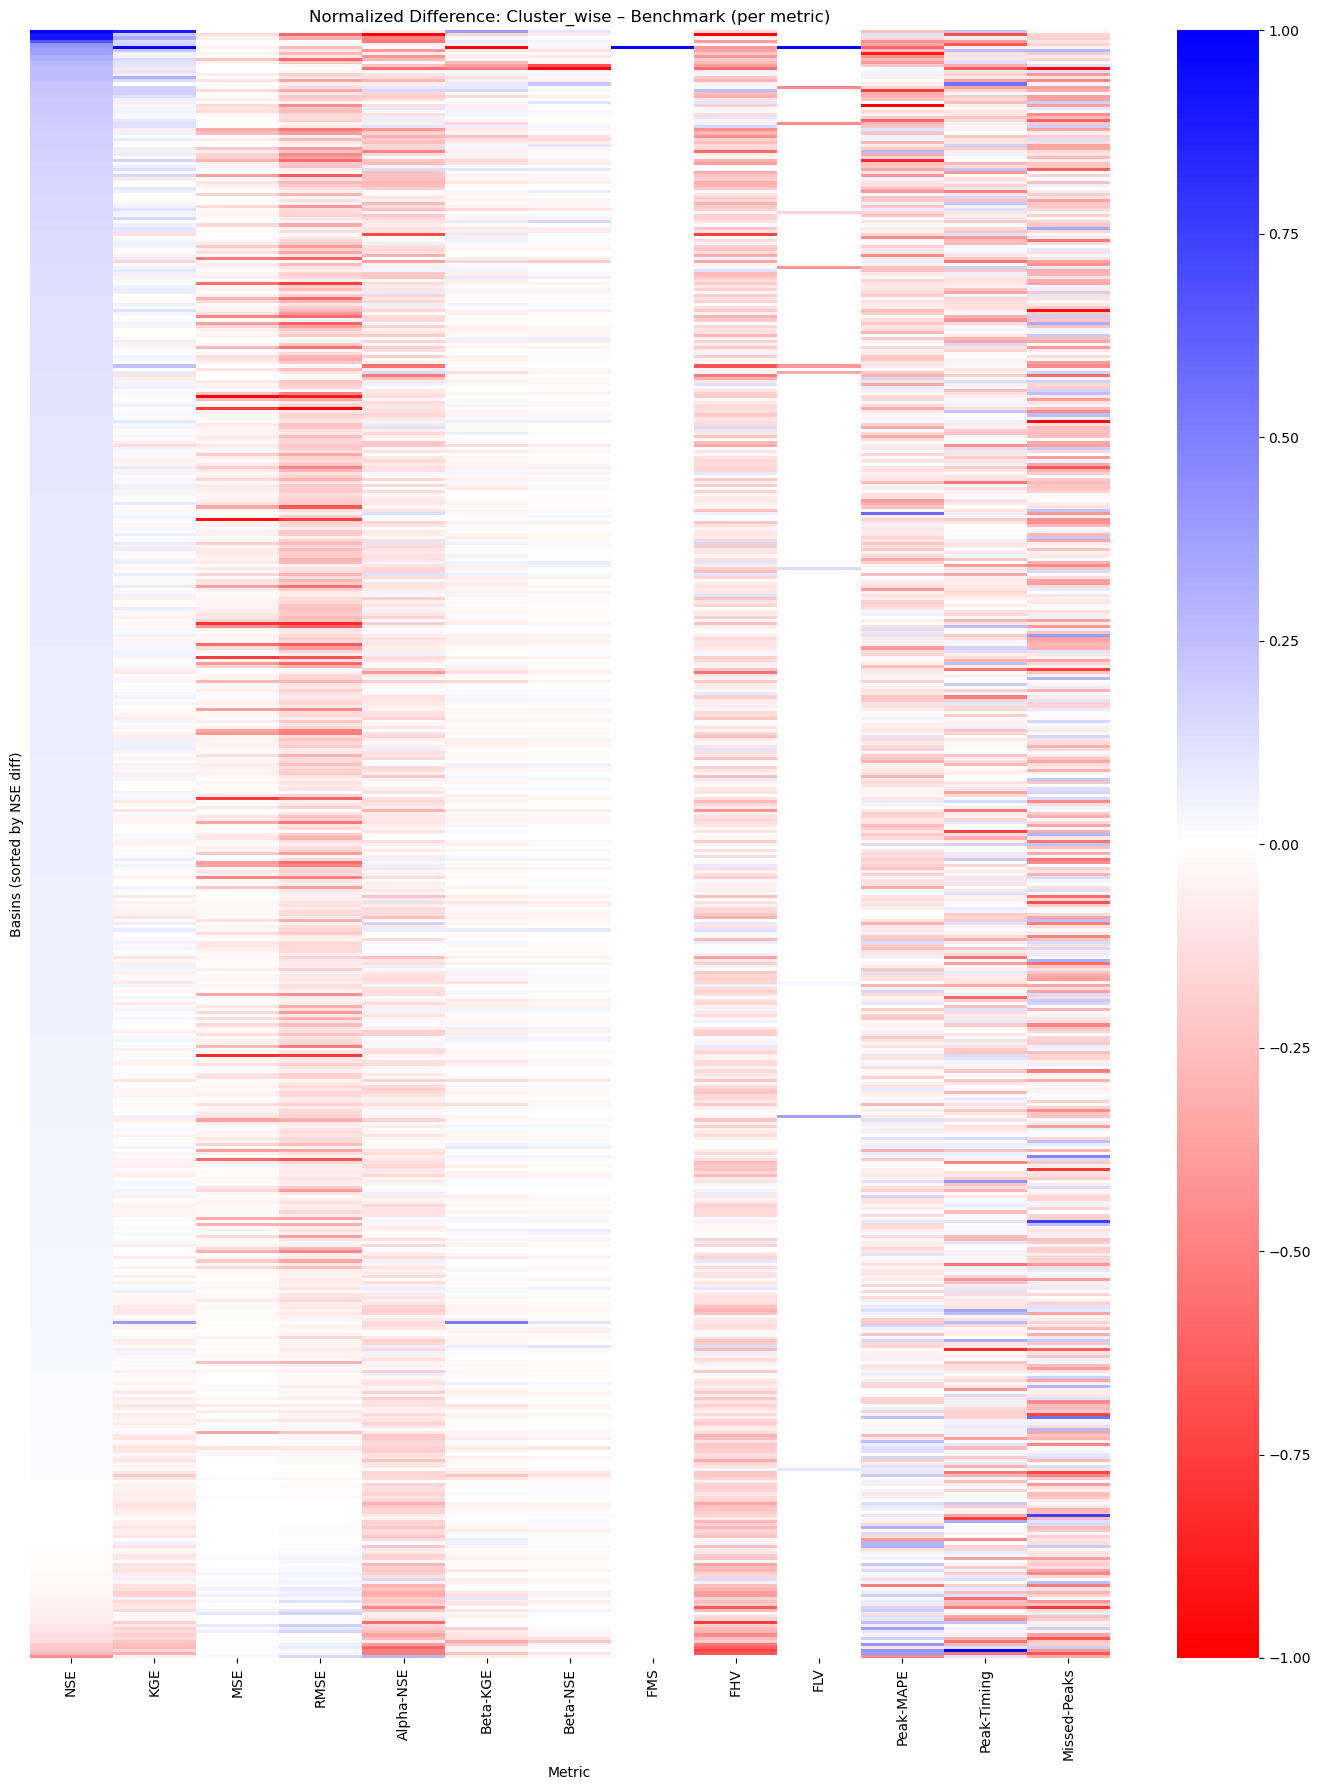

Saved: F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\CAMELS_US_HeatmapDiff_Cluster_vs_Benchmark_ALLMETRICS_NORMED.jpg


In [ ]:
# Final 2

# === Setup ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

# === Flatten into long DataFrame ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === Aggregate by basin/model: mean across seeds ===
# Only keep Cluster_wise and Benchmark
df2 = df[df['model'].isin(['Cluster_wise', 'Benchmark'])]

# Compute mean per (basin, model) for each metric
means = (
    df2
    .groupby(['basin', 'model'])[metrics]
    .mean()
    .unstack('model')   # MultiIndex columns: (metric, model)
)

# Compute difference: Cluster_wise - Benchmark, for each metric
diff = means.xs('Cluster_wise', axis=1, level=1) - means.xs('Benchmark', axis=1, level=1)

# Sort basins by NSE difference, descending
diff = diff.sort_values('NSE', ascending=False)

# === Normalize each column (metric) to [-1, 1] for fair color mapping ===
diff_norm = diff.copy()
for col in diff_norm.columns:
    maxabs = diff_norm[col].abs().max()
    if maxabs > 0:
        diff_norm[col] = diff_norm[col] / maxabs

# === Plot ===
plt.figure(figsize=(14, 18))
sns.heatmap(diff_norm, cmap='bwr_r', center=0, yticklabels=False, annot=False, vmin=-1, vmax=1)
plt.title('Normalized Difference: Cluster_wise – Benchmark (per metric)')
plt.xlabel('Metric')
plt.ylabel('Basins (sorted by NSE diff)')
plt.tight_layout()

out_file = os.path.join(save_dir, "CAMELS_US_HeatmapDiff_Cluster_vs_Benchmark_ALLMETRICS_NORMED.jpg")
plt.savefig(out_file, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Saved: {out_file}")


In [79]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap_diff_custom(wide_df, metrics_best, baseline='Benchmark', metric_name='', save_path=None):
    # 1. Compute absolute difference from best value for each metric and model
    absdev = wide_df.copy()
    for metric, bestval in metrics_best.items():
        if metric in absdev.columns.get_level_values(0):
            for model in absdev.columns.get_level_values(1).unique():
                if (metric, model) in absdev.columns:
                    absdev[(metric, model)] = (absdev[(metric, model)] - bestval).abs()
    # 2. For each model, compute difference to Benchmark's deviation from best
    diff = absdev.copy()
    for metric in metrics_best:
        if (metric, baseline) in absdev.columns:
            for model in absdev.columns.get_level_values(1).unique():
                if model == baseline:
                    continue
                if (metric, model) in absdev.columns:
                    diff[(metric, model)] = absdev[(metric, model)] - absdev[(metric, baseline)]
    # Keep only non-benchmark models
    drop_cols = [(metric, baseline) for metric in metrics_best]
    diff = diff.drop(columns=drop_cols, errors='ignore')
    # Remove column multiindex to make plotting easier
    diff.columns = [f"{metric}_{model}" for metric, model in diff.columns]
    # Sort by NSE_Cluster_wise difference descending if present
    sort_col = "NSE_Cluster_wise"
    if sort_col in diff.columns:
        diff = diff.sort_values(sort_col, ascending=False)
    # Normalize each column (to [-1,1]) for color mapping
    diff_norm = diff.copy()
    for col in diff_norm.columns:
        maxabs = diff_norm[col].abs().max()
        if maxabs > 0:
            diff_norm[col] = diff_norm[col] / maxabs
    # Plot
    plt.figure(figsize=(14, 18))
    sns.heatmap(diff_norm, cmap='bwr_r', center=0, yticklabels=False, vmin=-1, vmax=1)
    plt.title(f'Normalized difference (abs distance to best) vs. {baseline}\nper metric & model')
    plt.xlabel('Metric_Model')
    plt.ylabel('Basins')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# === Setup ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}

metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

metrics_best = {
    # Metrics where 1 is best
    'NSE': 1, 'KGE': 1, 'Alpha-NSE': 1, 'Beta-KGE': 1,
    # All others, 0 is best
    'Beta-NSE': 0, 'MSE': 0, 'RMSE': 0, 'FHV': 0, 'Missed-Peaks': 0,
    'FLV': 0, 'FMS': 0, 'Peak-MAPE': 0, 'Peak-Timing': 0
}

# === Flatten into long DataFrame with MultiIndex columns ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === Groupby: get mean value per (basin, model) for all metrics ===
wide = (
    df
    .groupby(['basin', 'model'])[metrics]
    .mean()
    .unstack('model')
)

# === Plot all metrics & models in one shot ===
out_file = os.path.join(save_dir, 'CAMELS_US_HeatmapDiff_DIST2BEST_vs_Benchmark_ALLMODELS_ALLMETRICS.jpg')
plot_heatmap_diff_custom(wide, metrics_best=metrics_best, baseline='Benchmark', metric_name='All', save_path=out_file)

print("Done. All heatmaps saved.")


Done. All heatmaps saved.


In [80]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_vs_benchmark(wide_df, metrics_best, save_path=None):
    # Calculate abs deviation from best for Cluster_wise and Benchmark
    absdev_cluster = pd.DataFrame({m: (wide_df[(m, 'Cluster_wise')] - b).abs() for m, b in metrics_best.items()})
    absdev_bench   = pd.DataFrame({m: (wide_df[(m, 'Benchmark')]    - b).abs() for m, b in metrics_best.items()})
    # Difference: cluster - benchmark (negative = cluster closer to best)
    diff = absdev_cluster - absdev_bench
    # Sort by NSE difference
    diff = diff.sort_values('NSE', ascending=False)
    # Normalize each metric to [-1,1]
    diff_norm = diff.copy()
    for col in diff_norm.columns:
        maxabs = diff_norm[col].abs().max()
        if maxabs > 0:
            diff_norm[col] = diff_norm[col] / maxabs
    # Plot
    plt.figure(figsize=(14, 18))
    sns.heatmap(diff_norm, cmap='bwr_r', center=0, yticklabels=False, vmin=-1, vmax=1)
    plt.title('Normalized diff: |Cluster-wise - best| minus |Benchmark - best|\n(negative = Cluster-wise better)')
    plt.xlabel('Metric')
    plt.ylabel('Basins (sorted by NSE diff)')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# === Setup ===
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

model_dicts = {
    'RO':           test_metrics_RO,
    'Benchmark':    test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10':        test_metrics_Top10
}
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]
metrics_best = {
    'NSE': 1, 'KGE': 1, 'Alpha-NSE': 1, 'Beta-KGE': 1,
    'Beta-NSE': 0, 'MSE': 0, 'RMSE': 0, 'FHV': 0, 'Missed-Peaks': 0,
    'FLV': 0, 'FMS': 0, 'Peak-MAPE': 0, 'Peak-Timing': 0
}

# === Flatten into long DataFrame with MultiIndex columns ===
rows = []
for model, seeds in model_dicts.items():
    for seed, basins in seeds.items():
        for basin, mets in basins.items():
            r = {'model': model, 'basin': basin, 'seed': seed}
            r.update(mets)
            rows.append(r)
df = pd.DataFrame(rows)

# === Groupby: get mean value per (basin, model) for all metrics ===
wide = (
    df
    .groupby(['basin', 'model'])[metrics]
    .mean()
    .unstack('model')
)

# === Plot only Cluster-wise vs Benchmark, all metrics, sorted by NSE diff ===
out_file = os.path.join(save_dir, 'CAMELS_US_HeatmapDiff_DIST2BEST_Clusterwise_vs_Benchmark_ALLMETRICS.jpg')
plot_cluster_vs_benchmark(wide, metrics_best=metrics_best, save_path=out_file)

print(f"Done. Saved plot to {out_file}")


Done. Saved plot to F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\CAMELS_US_HeatmapDiff_DIST2BEST_Clusterwise_vs_Benchmark_ALLMETRICS.jpg


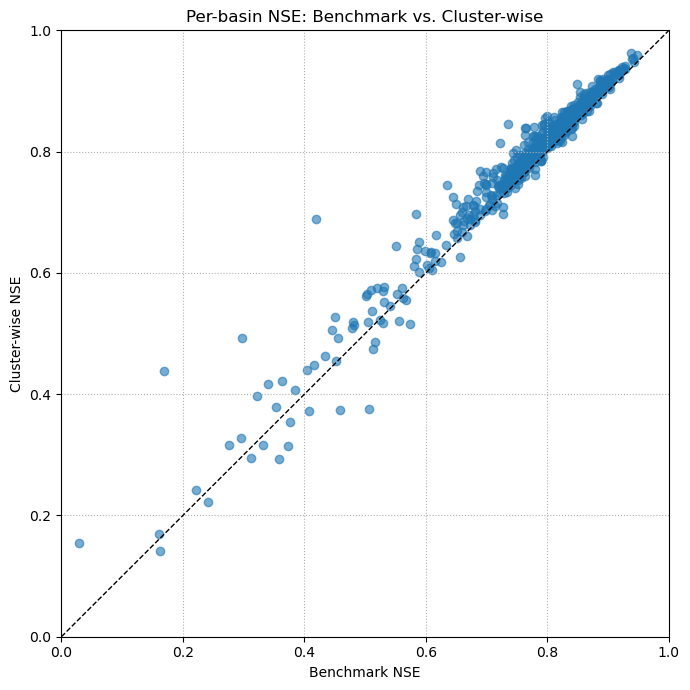

In [81]:
import matplotlib.pyplot as plt

# Group to get per-basin mean (or median) NSE for each model
nse_df = (
    df[df['model'].isin(['Benchmark', 'Cluster_wise'])]
    .groupby(['basin', 'model'])['NSE']
    .mean()     # or .median() if you prefer
    .unstack('model')
    .dropna()
)

plt.figure(figsize=(7, 7))
plt.scatter(nse_df['Benchmark'], nse_df['Cluster_wise'], alpha=0.6)
plt.plot([0, 1], [0, 1], 'k--', lw=1)  # 1:1 reference line
plt.xlabel('Benchmark NSE')
plt.ylabel('Cluster-wise NSE')
plt.title('Per-basin NSE: Benchmark vs. Cluster-wise')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()


C:\Users\hosseinifh\AppData\Local\Temp\ipykernel_21708\3889365923.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['basin'] = sub['basin'].astype(str)
C:\Users\hosseinifh\AppData\Local\Temp\ipykernel_21708\3889365923.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['seed'] = sub['seed'].astype(str)


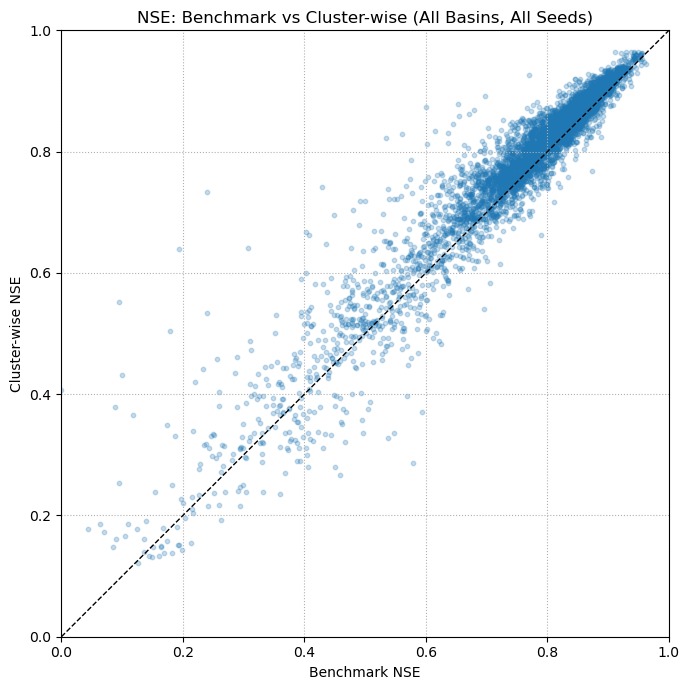

In [85]:
import matplotlib.pyplot as plt

# Select only Benchmark and Cluster_wise data
sub = df[df['model'].isin(['Benchmark', 'Cluster_wise'])]

# Merge all (basin, seed) pairs, keeping both model NSEs
# First, make sure 'basin' and 'seed' are both strings (just in case)
sub['basin'] = sub['basin'].astype(str)
sub['seed'] = sub['seed'].astype(str)

# Pivot: index=(basin,seed), columns=model, values=NSE
pivot = sub.pivot_table(index=['basin', 'seed'], columns='model', values='NSE')

# Drop any rows missing either value (should rarely happen)
pivot = pivot.dropna(subset=['Benchmark', 'Cluster_wise'])

plt.figure(figsize=(7, 7))
plt.scatter(pivot['Benchmark'], pivot['Cluster_wise'], alpha=0.25, s=10)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Benchmark NSE')
plt.ylabel('Cluster-wise NSE')
plt.title('NSE: Benchmark vs Cluster-wise (All Basins, All Seeds)')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()


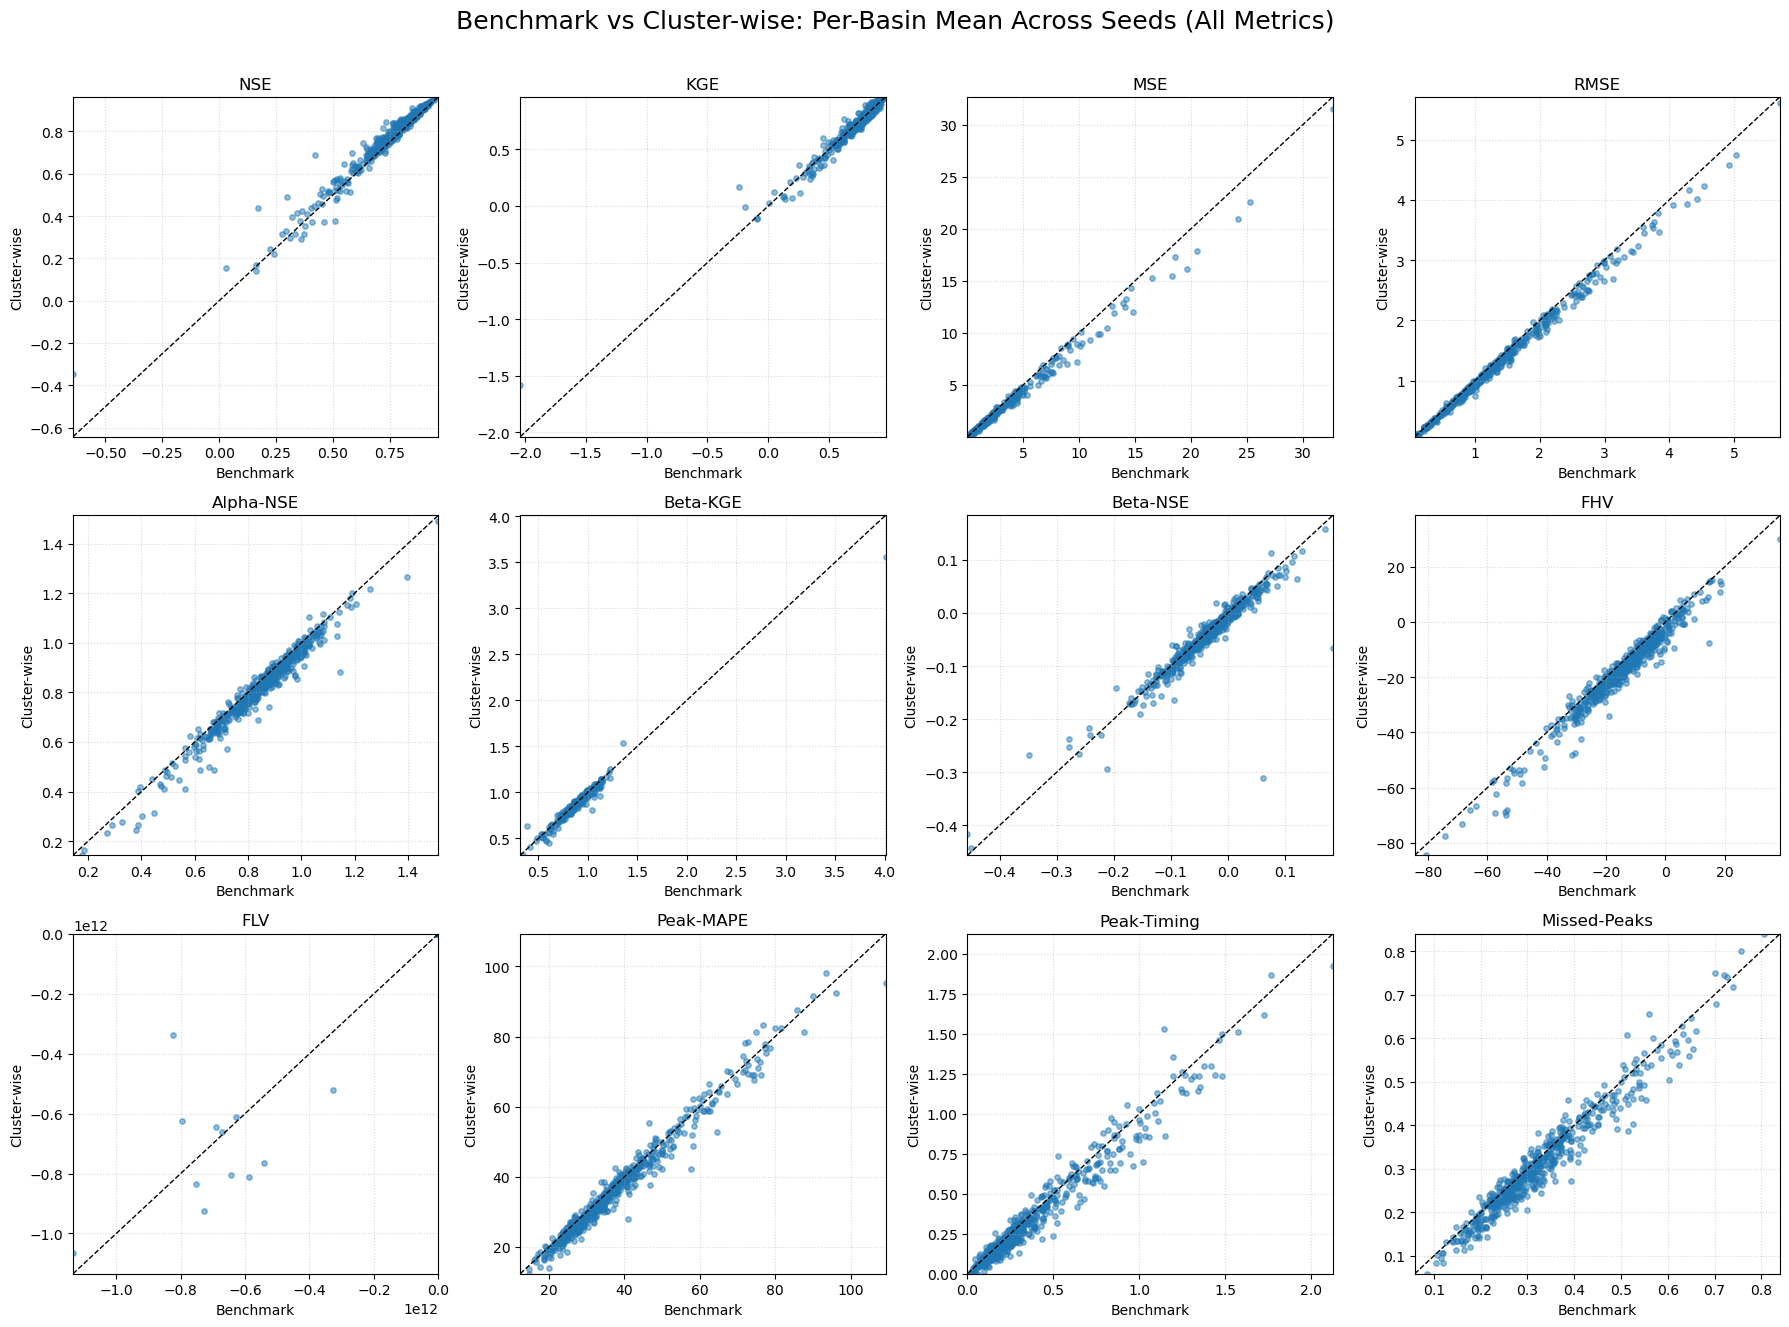

In [94]:
import matplotlib.pyplot as plt
import numpy as np

# -- Subset and group to get mean per basin/model/metric
mean_df = (
    df[df['model'].isin(['Benchmark', 'Cluster_wise'])]
    .groupby(['basin', 'model'])[metrics]
    .mean()
    .unstack('model')
    .dropna()  # drop basins missing one model
)

metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

n_metrics = len(metrics)
ncols = 4
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 4.5*nrows), sharex=False, sharey=False)

for idx, metric in enumerate(metrics):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row, col]
    x = mean_df[(metric, 'Benchmark')]
    y = mean_df[(metric, 'Cluster_wise')]
    ax.scatter(x, y, alpha=0.5, s=15)
    # 1:1 line
    allvals = np.concatenate([x.values, y.values])
    minval = np.nanmin(allvals)
    maxval = np.nanmax(allvals)
    ax.plot([minval, maxval], [minval, maxval], 'k--', lw=1)
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Cluster-wise')
    ax.set_title(metric)
    ax.grid(ls=':', alpha=0.5)
    ax.set_xlim([minval, maxval])
    ax.set_ylim([minval, maxval])

# Hide any empty axes
for i in range(n_metrics, nrows*ncols):
    fig.delaxes(axes.flatten()[i])

plt.suptitle('Benchmark vs Cluster-wise: Per-Basin Mean Across Seeds (All Metrics)', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


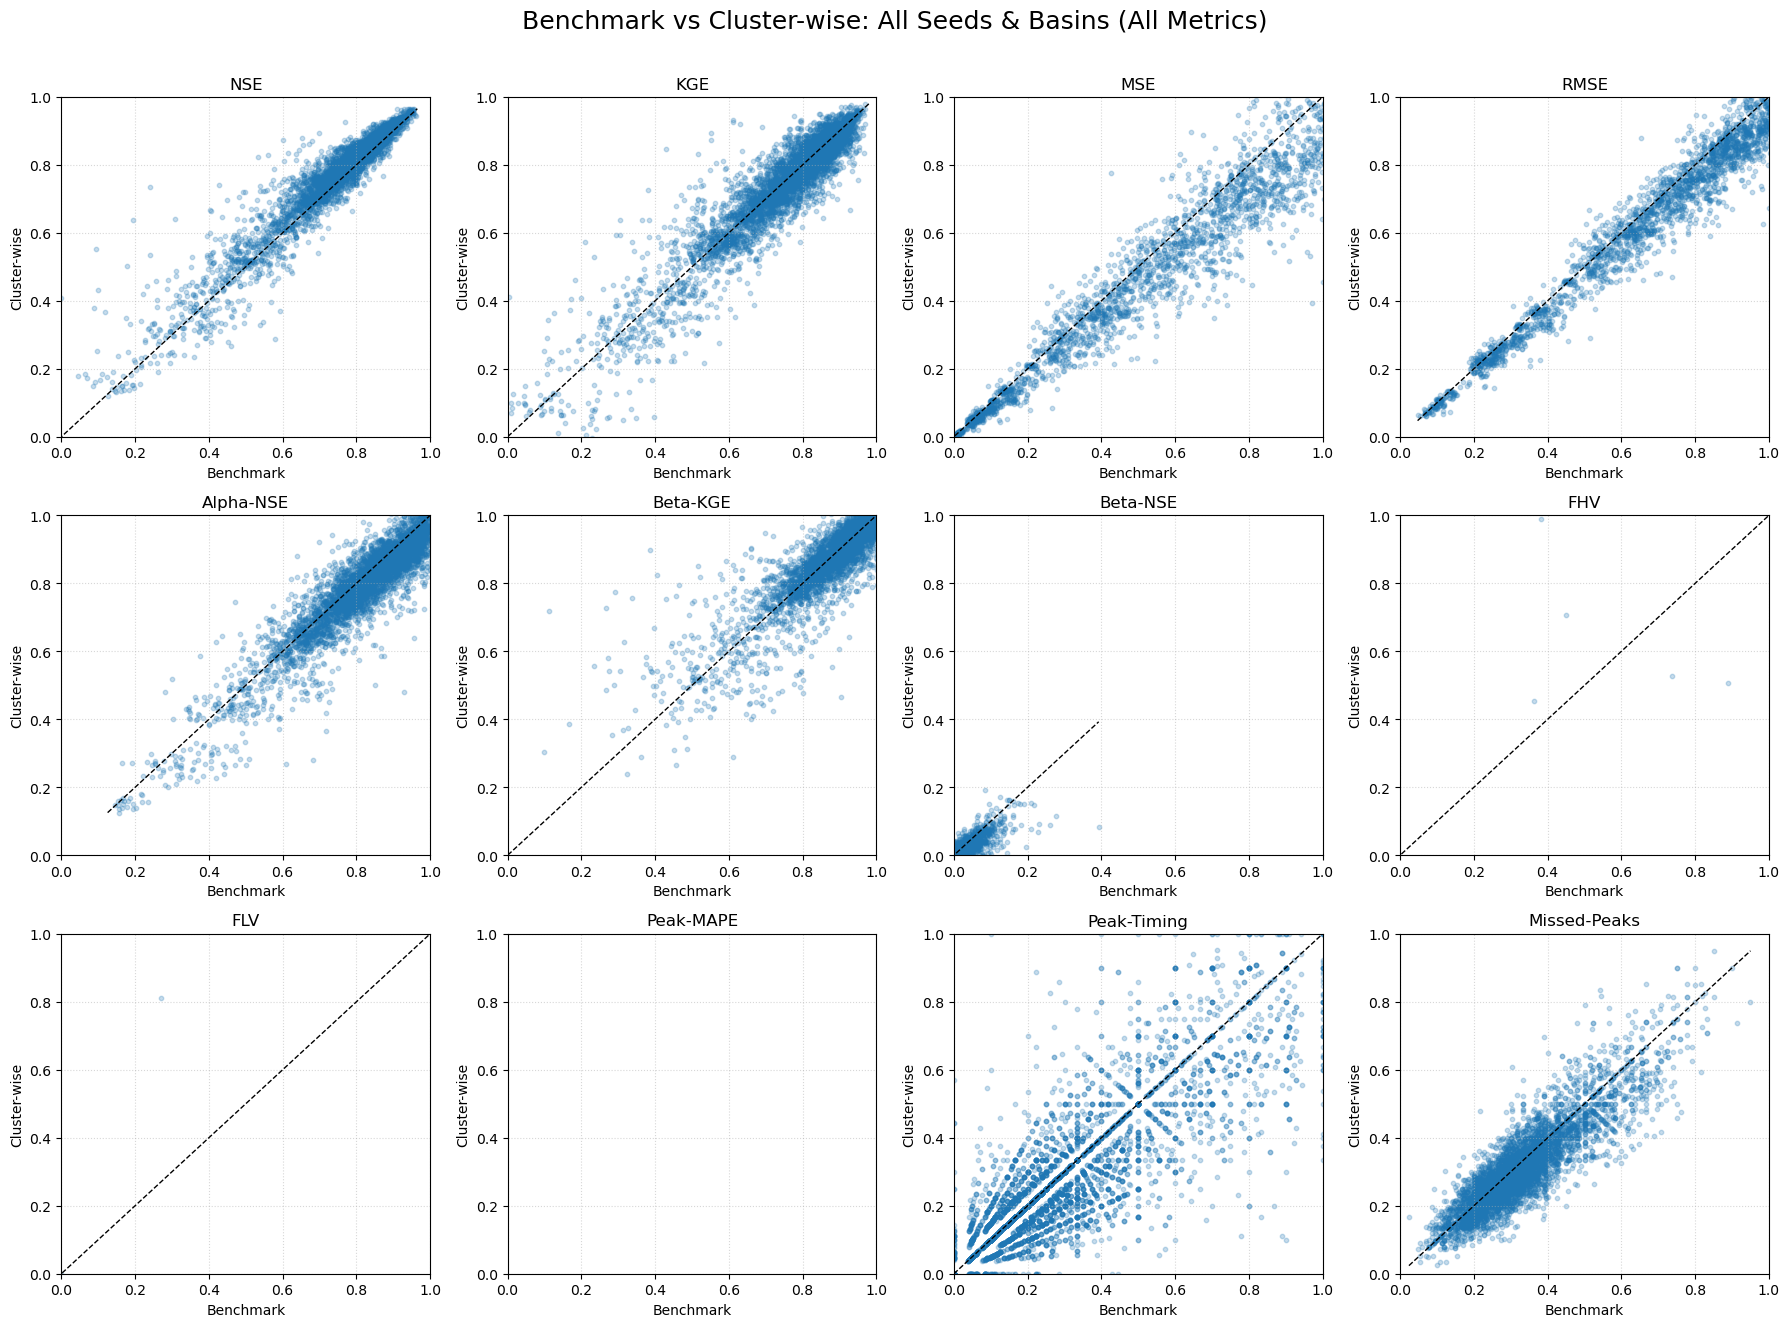

In [90]:
import matplotlib.pyplot as plt
import numpy as np

n_metrics = len(metrics)
ncols = 4
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 4.5*nrows), sharex=False, sharey=False)

for idx, metric in enumerate(metrics):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row, col]
    # Only Benchmark & Cluster-wise models
    sub = df[df['model'].isin(['Benchmark', 'Cluster_wise'])]
    # Pivot: index = (basin, seed), columns = model, values = metric
    pivot = sub.pivot_table(index=['basin', 'seed'], columns='model', values=metric)
    pivot = pivot.dropna(subset=['Benchmark', 'Cluster_wise'])
    x = pivot['Benchmark']
    y = pivot['Cluster_wise']
    ax.scatter(x, y, alpha=0.25, s=10)
    # 1:1 line
    allvals = np.concatenate([x.values, y.values])
    minval = np.nanmin(allvals)
    maxval = np.nanmax(allvals)
    ax.plot([minval, maxval], [minval, maxval], 'k--', lw=1)
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Cluster-wise')
    ax.set_title(metric)
    ax.grid(ls=':', alpha=0.5)
    if metric == 'NSE' or 'KGE':
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
    else:
        ax.set_xlim([minval, maxval])
        ax.set_ylim([minval, maxval])
    

# Hide any empty axes
for i in range(n_metrics, nrows*ncols):
    fig.delaxes(axes.flatten()[i])

plt.suptitle('Benchmark vs Cluster-wise: All Seeds & Basins (All Metrics)', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [96]:
## CDFs on seeds

# Load the Excel files
file_path_cluster = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Cluster_wise_all.xlsx'
file_path_benchmark = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Benchmark_all.xlsx'

df_cluster = pd.read_excel(file_path_cluster, dtype={'basin': str})
df_benchmark = pd.read_excel(file_path_benchmark, dtype={'basin': str})

# Define colors for the models
colors = {
    'Benchmark': '#1f77b4',     # blue
    'Cluster-wise': '#ff7f0e',  # orange
}

# Function to create and save the CDF plot for a single metric
def create_single_metric_cdf(df_benchmark, df_cluster, metric, save_dir):
    # Get the unique seeds
    seeds = sorted(df_cluster['seed'].unique())

    # Define the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Loop through each seed and plot CDFs for Benchmark and Cluster-wise
    for seed in seeds:
        # Filter data for this seed
        df_b = df_benchmark[df_benchmark['seed'] == seed]
        df_c = df_cluster[df_cluster['seed'] == seed]

        # Align by basin to ensure we're comparing the same basins
        merged = pd.merge(df_b, df_c, on='basin', suffixes=('_b', '_c'))

        # Extract metric values
        vals_b = merged[f'{metric}_b'].values
        vals_c = merged[f'{metric}_c'].values

        # Compute and plot CDFs
        sorted_vals_b = np.sort(vals_b)
        cdf_b = np.arange(1, len(sorted_vals_b) + 1) / len(sorted_vals_b)
        ax.plot(sorted_vals_b, cdf_b, color=colors['Benchmark'], alpha=0.3)  # Use alpha for better visualization

        sorted_vals_c = np.sort(vals_c)
        cdf_c = np.arange(1, len(sorted_vals_c) + 1) / len(sorted_vals_c)
        ax.plot(sorted_vals_c, cdf_c, color=colors['Cluster-wise'], alpha=0.3)  # Same for cluster-wise

    # Title and legend
    ax.set_title(f'Cumulative Distribution of {metric}: Benchmark vs. Cluster-wise', fontsize=18)
    ax.set_xlabel(f'{metric} Value', fontsize=14)
    ax.set_ylabel('Cumulative Probability', fontsize=14)
    ax.grid(True)

    # Add a single legend
    ax.plot([], [], color=colors['Benchmark'], label='Benchmark', alpha=1)
    ax.plot([], [], color=colors['Cluster-wise'], label='Cluster-wise', alpha=1)
    ax.legend(loc='lower right', fontsize=12, title='Model Type', title_fontsize=14)

    # Adjust x-axis limits based on the metric
    if metric == 'NSE':
        ax.set_xlim(0.5, 1)
    elif metric == 'KGE':
        ax.set_xlim(0, 1)
    elif metric == 'MSE':
        ax.set_xlim(0, 15)
    elif metric == 'RMSE':
        ax.set_xlim(0, 4)
    elif metric == 'Alpha-NSE':
        ax.set_xlim(0, 1.5)
    elif metric == 'Beta-KGE':
        ax.set_xlim(0.5, 1.5)
    elif metric == 'Beta-NSE':
        ax.set_xlim(-0.2, 0.2)
    elif metric == 'FHV':
        ax.set_xlim(-80, 40)
    elif metric == 'Peak-MAPE':
        ax.set_xlim(0, 80)
    elif metric == 'Peak-Timing':
        ax.set_xlim(0, 1.5)

    # Increase font size for axis tick labels
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Save the plot
    save_path = os.path.join(save_dir, f'CAMELS_US_CDF_{metric}_ver_02.jpg')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(save_path, dpi=600)
    plt.close()

# Metrics to compare
metrics_list = ['NSE', 'KGE', 'MSE', 'RMSE', 'Alpha-NSE', 'Beta-KGE', 'Beta-NSE', 'FHV', 'Peak-MAPE', 'Peak-Timing']

# Directory to save the plots
save_dir = r'F:\Experiments\CAMELS_US\TrainsTests\Results\Plots'

# Loop through each metric and generate/save the plot
for metric in metrics_list:
    create_single_metric_cdf(df_benchmark, df_cluster, metric, save_dir)


In [97]:
## CDFs on seeds

# Load the Excel files
file_path_cluster = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Cluster_wise_all.xlsx'
file_path_benchmark = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Top10_all.xlsx'

df_cluster = pd.read_excel(file_path_cluster, dtype={'basin': str})
df_benchmark = pd.read_excel(file_path_benchmark, dtype={'basin': str})

# Define colors for the models
colors = {
    'Benchmark': '#1f77b4',     # blue
    'Cluster-wise': '#ff7f0e',  # orange
}

# Function to create and save the CDF plot for a single metric
def create_single_metric_cdf(df_benchmark, df_cluster, metric, save_dir):
    # Get the unique seeds
    seeds = sorted(df_cluster['seed'].unique())

    # Define the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Loop through each seed and plot CDFs for Benchmark and Cluster-wise
    for seed in seeds:
        # Filter data for this seed
        df_b = df_benchmark[df_benchmark['seed'] == seed]
        df_c = df_cluster[df_cluster['seed'] == seed]

        # Align by basin to ensure we're comparing the same basins
        merged = pd.merge(df_b, df_c, on='basin', suffixes=('_b', '_c'))

        # Extract metric values
        vals_b = merged[f'{metric}_b'].values
        vals_c = merged[f'{metric}_c'].values

        # Compute and plot CDFs
        sorted_vals_b = np.sort(vals_b)
        cdf_b = np.arange(1, len(sorted_vals_b) + 1) / len(sorted_vals_b)
        ax.plot(sorted_vals_b, cdf_b, color=colors['Benchmark'], alpha=0.3)  # Use alpha for better visualization

        sorted_vals_c = np.sort(vals_c)
        cdf_c = np.arange(1, len(sorted_vals_c) + 1) / len(sorted_vals_c)
        ax.plot(sorted_vals_c, cdf_c, color=colors['Cluster-wise'], alpha=0.3)  # Same for cluster-wise

    # Title and legend
    ax.set_title(f'Cumulative Distribution of {metric}: Top10  vs. Cluster-wise', fontsize=18)
    ax.set_xlabel(f'{metric} Value', fontsize=14)
    ax.set_ylabel('Cumulative Probability', fontsize=14)
    ax.grid(True)

    # Add a single legend
    ax.plot([], [], color=colors['Benchmark'], label='Top10', alpha=1)
    ax.plot([], [], color=colors['Cluster-wise'], label='Cluster-wise', alpha=1)
    ax.legend(loc='lower right', fontsize=12, title='Model Type', title_fontsize=14)

    # Adjust x-axis limits based on the metric
    if metric == 'NSE':
        ax.set_xlim(0.5, 1)
    elif metric == 'KGE':
        ax.set_xlim(0, 1)
    elif metric == 'MSE':
        ax.set_xlim(0, 15)
    elif metric == 'RMSE':
        ax.set_xlim(0, 4)
    elif metric == 'Alpha-NSE':
        ax.set_xlim(0, 1.5)
    elif metric == 'Beta-KGE':
        ax.set_xlim(0.5, 1.5)
    elif metric == 'Beta-NSE':
        ax.set_xlim(-0.2, 0.2)
    elif metric == 'FHV':
        ax.set_xlim(-80, 40)
    elif metric == 'Peak-MAPE':
        ax.set_xlim(0, 80)
    elif metric == 'Peak-Timing':
        ax.set_xlim(0, 1.5)

    # Increase font size for axis tick labels
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Save the plot
    save_path = os.path.join(save_dir, f'CAMELS_US_CDF_{metric}_ver_03.jpg')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(save_path, dpi=600)
    plt.close()

# Metrics to compare
metrics_list = ['NSE', 'KGE', 'MSE', 'RMSE', 'Alpha-NSE', 'Beta-KGE', 'Beta-NSE', 'FHV', 'Peak-MAPE', 'Peak-Timing']

# Directory to save the plots
save_dir = r'F:\Experiments\CAMELS_US\TrainsTests\Results\Plots'

# Loop through each metric and generate/save the plot
for metric in metrics_list:
    create_single_metric_cdf(df_benchmark, df_cluster, metric, save_dir)


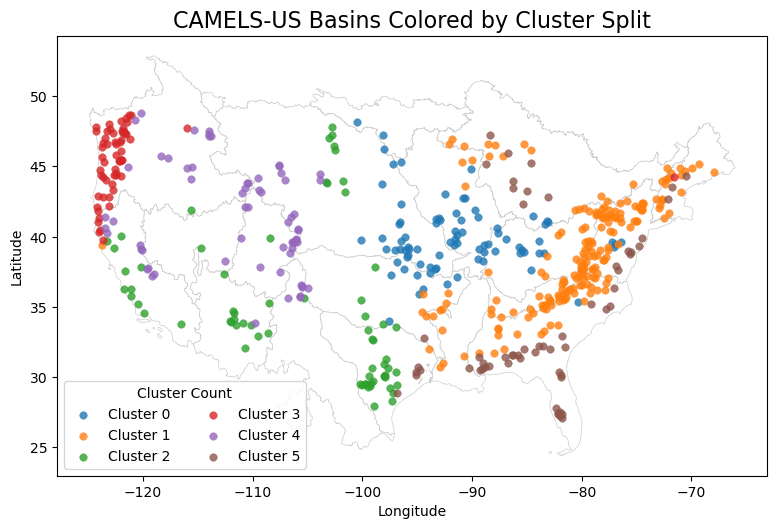

In [99]:
import os
import sys
import importlib.util
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import more_itertools
from tensorboard.backend.event_processing import event_accumulator
from matplotlib.lines import Line2D

# === Dynamic load of camelsus.py ===
sys.path.append(r'C:\Users\hosseinifh\neuralhydrology')
camelsus_file_path = r"F:\Experiments\CAMELS_US\TrainsTests\camelsus.py"
spec = importlib.util.spec_from_file_location("camelsus", camelsus_file_path)
camelsus = importlib.util.module_from_spec(spec)
sys.modules["camelsus"] = camelsus
spec.loader.exec_module(camelsus)

# === Utility functions ===
def cm2inch(width: float, height: float) -> tuple:
    inch = 2.54
    return (width / inch, height / inch)

def ecdf(x: np.ndarray) -> tuple:
    xs = np.sort(x)
    ys = np.arange(1, len(xs) + 1) / float(len(xs))
    return xs, ys

def get_validation_data_as_series(event_file: Path, name: str) -> pd.Series:
    ea = event_accumulator.EventAccumulator(
        str(event_file),
        size_guidance={event_accumulator.SCALARS: 0}
    )
    ea.Reload()
    epochs, values = [], []
    for event in ea.Scalars('valid/median_nse'):
        epochs.append(event.step)
        values.append(event.value)
    ser = pd.Series(data=values, index=epochs, name=name)
    ser.index.name = "Epoch"
    return ser

def get_test_metrics(run_dir: Path) -> pd.DataFrame:
    metric_file = more_itertools.one(
        list((run_dir / "test").glob('*/test_metrics.csv'))
    )
    df = pd.read_csv(metric_file, dtype={'basin': str})
    df.set_index("basin", inplace=True)
    return df

# === Paths ===
CAMELS_DIR = Path(r'F:\Experiments\CAMELS_US\Data')
PAPER_DIR  = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
HUC_GDB    = PAPER_DIR / "misc" / "shapefiles" / "huc_02" / "huc_02_simplified.gdb"

# === Load & filter HUC shapefile ===
gdf = gpd.read_file(str(HUC_GDB))
gdf = gdf.loc[~gdf.huc2.isin(['19', '20', '21', '22'])]

# === Load station attributes ===
attributes_df = camelsus.load_camels_us_attributes(data_dir=CAMELS_DIR)

# === Gather cluster splits ===
RUN_DIRS = Path(r'R:\Experiments\Never.Paper\single-basin-vs-regional-model\run_dirs')
cluster_dirs = RUN_DIRS / "attributes_cluster_splits"
cluster_counts = sorted(
    set(int(p.stem.split('_')[1]) for p in cluster_dirs.glob('*'))
)

cluster_to_basin_ids = {}
for count in cluster_counts:
    run_dir = more_itertools.one(
        x for x in cluster_dirs.glob(f'cluster_{count}_*_experiment_name_0_*')
    )
    df = get_test_metrics(run_dir)
    cluster_to_basin_ids[count] = df.index.to_list()

# === Gather HUC splits (if needed later) ===
huc_dirs = RUN_DIRS / "huc_splits"
hucs = sorted(set(p.stem.split('_')[1] for p in huc_dirs.glob('*')))

huc_to_basin_ids = {}
for huc in hucs:
    run_dir = more_itertools.one(
        x for x in huc_dirs.glob(f'huc_{huc}_*_experiment_name_0_*')
    )
    df = get_test_metrics(run_dir)
    huc_to_basin_ids[huc] = df.index.to_list()

# === Plot map of clusters ===
FIGURE_DIR = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=cm2inch(20, 16))

# Plot the HUC background
gdf.plot(ax=ax, facecolor="white", edgecolor="#cccccc", linewidth=0.5)

# Use a qualitative colormap to get distinct colors
cmap = plt.get_cmap('tab10')
for idx, (cluster_count, basin_ids) in enumerate(cluster_to_basin_ids.items()):
    coords = attributes_df.loc[basin_ids, ['gauge_lon', 'gauge_lat']]
    ax.scatter(
        coords['gauge_lon'],
        coords['gauge_lat'],
        color=cmap(idx % cmap.N),
        label=f"Cluster {cluster_count}",
        s=30,
        alpha=0.8,
        linewidth=0.3
    )

ax.legend(title="Cluster Count", loc='lower left', ncol=2, fontsize=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("CAMELS-US Basins Colored by Cluster Split", fontsize=16)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "map_attribute_split_clusters.jpg",
            bbox_inches="tight", dpi=600, format="jpg")
plt.show()
plt.close()


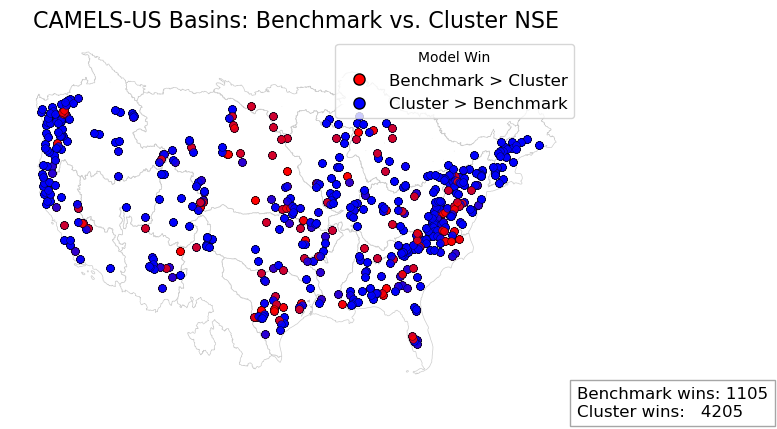

In [100]:

# === Paths ===
PAPER_DIR  = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
FIGURE_DIR = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

file_cluster   = PAPER_DIR / 'PickleFiles' / 'test_metrics_Cluster_wise_all.xlsx'
file_benchmark = PAPER_DIR / 'PickleFiles' / 'test_metrics_Benchmark_all.xlsx'
huc_gdb        = PAPER_DIR / 'misc' / 'shapefiles' / 'huc_02' / 'huc_02_simplified.gdb'

# === 1) Load HUC-02 background ===
gdf = gpd.read_file(str(huc_gdb))
gdf = gdf.loc[~gdf.huc2.isin(['19','20','21','22'])]

# === 2) Load station attributes ===
attributes_df = camelsus.load_camels_us_attributes(data_dir=Path(r'F:\Experiments\CAMELS_US\Data'))
if 'gauge_id' in attributes_df.columns:
    attributes_df.set_index('gauge_id', inplace=True)
assert 'gauge_lon' in attributes_df.columns and 'gauge_lat' in attributes_df.columns

# === 3) Read Excel test metrics ===
df_cluster   = pd.read_excel(file_cluster,   dtype={'basin':str}).set_index('basin')
df_benchmark = pd.read_excel(file_benchmark, dtype={'basin':str}).set_index('basin')

# === 4) Extract NSE and merge ===
cluster_nse   = df_cluster['NSE'].rename('cluster_nse')
benchmark_nse = df_benchmark['NSE'].rename('benchmark_nse')
df_nse = pd.concat([cluster_nse, benchmark_nse], axis=1).dropna()

# === 5) Determine color per basin ===
# red if benchmark > cluster, else blue
df_nse['color'] = np.where(
    df_nse['benchmark_nse'] > df_nse['cluster_nse'],
    'red',
    'blue'
)

# count wins
benchmark_wins = (df_nse['color'] == 'red').sum()
cluster_wins   = (df_nse['color'] == 'blue').sum()

# === 6) Plot ===
fig, ax = plt.subplots(figsize=(20/2.54, 16/2.54))  # 20×16 cm

# background HUC
gdf.plot(ax=ax, facecolor='white', edgecolor='#cccccc', linewidth=0.5)

# scatter basins colored by which model wins
for basin, row in df_nse.iterrows():
    if basin not in attributes_df.index:
        continue
    lon = attributes_df.at[basin, 'gauge_lon']
    lat = attributes_df.at[basin, 'gauge_lat']
    ax.scatter(
        lon, lat,
        c=row['color'],
        s=30,
        edgecolor='k',
        linewidth=0.3,
        alpha=0.8
    )

# annotate win counts
text = (
    f"Benchmark wins: {benchmark_wins}\n"
    f"Cluster wins:   {cluster_wins}"
)
ax.text(
    0.99, 0.01, text,
    transform=ax.transAxes,
    fontsize=12,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=5)
)

# custom legend
legend_elems = [
    Line2D([0], [0], marker='o', color='w', label='Benchmark > Cluster',
           markerfacecolor='red',   markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Cluster > Benchmark',
           markerfacecolor='blue',  markersize=8, markeredgecolor='k'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=12, title='Model Win')

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('CAMELS-US Basins: Benchmark vs. Cluster NSE', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'map_nse_comparison_with_counts.jpg',
            dpi=600, format='jpg', bbox_inches='tight')
plt.show()
plt.close()


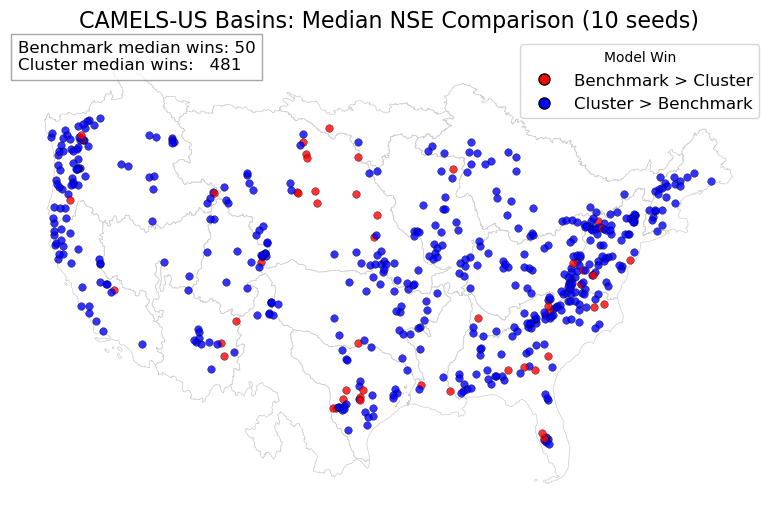

In [101]:

# === Paths ===
PAPER_DIR  = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
FIGURE_DIR = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

file_cluster   = PAPER_DIR / 'PickleFiles' / 'test_metrics_Cluster_wise_all.xlsx'
file_benchmark = PAPER_DIR / 'PickleFiles' / 'test_metrics_Benchmark_all.xlsx'
huc_gdb        = PAPER_DIR / 'misc' / 'shapefiles' / 'huc_02' / 'huc_02_simplified.gdb'

# === 1) Load HUC-02 background ===
gdf = gpd.read_file(str(huc_gdb))
gdf = gdf.loc[~gdf.huc2.isin(['19','20','21','22'])]

# === 2) Load station attributes ===
attributes_df = camelsus.load_camels_us_attributes(data_dir=Path(r'F:\Experiments\CAMELS_US\Data'))
if 'gauge_id' in attributes_df.columns:
    attributes_df.set_index('gauge_id', inplace=True)
assert 'gauge_lon' in attributes_df.columns and 'gauge_lat' in attributes_df.columns

# === 3) Read Excel test metrics (multiple seeds) and compute median per basin ===
df_cluster_all   = pd.read_excel(file_cluster,   dtype={'basin':str})
df_benchmark_all = pd.read_excel(file_benchmark, dtype={'basin':str})

# compute median NSE across seeds for each basin
cluster_nse   = df_cluster_all.groupby('basin')['NSE'].median().rename('cluster_nse')
benchmark_nse = df_benchmark_all.groupby('basin')['NSE'].median().rename('benchmark_nse')

# combine into one DataFrame
df_nse = pd.concat([cluster_nse, benchmark_nse], axis=1).dropna()

# === 4) Determine color per basin ===
# red if benchmark median > cluster median, else blue
df_nse['color'] = np.where(
    df_nse['benchmark_nse'] > df_nse['cluster_nse'],
    'red',
    'blue'
)

# count wins
benchmark_wins = (df_nse['color'] == 'red').sum()
cluster_wins   = (df_nse['color'] == 'blue').sum()

# === 5) Plot ===
fig, ax = plt.subplots(figsize=(20/2.54, 16/2.54))  # 20×16 cm

# background HUC
gdf.plot(ax=ax, facecolor='white', edgecolor='#cccccc', linewidth=0.5)

# scatter basins colored by which model's median NSE is higher
for basin, row in df_nse.iterrows():
    if basin not in attributes_df.index:
        continue
    lon = attributes_df.at[basin, 'gauge_lon']
    lat = attributes_df.at[basin, 'gauge_lat']
    ax.scatter(
        lon, lat,
        c=row['color'],
        s=30,
        edgecolor='k',
        linewidth=0.3,
        alpha=0.8
    )

# annotate win counts
text = (
    f"Benchmark median wins: {benchmark_wins}\n"
    f"Cluster median wins:   {cluster_wins}"
)
ax.text(
    0.01, 0.99, text,
    transform=ax.transAxes,
    fontsize=12,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=5)
)

# custom legend
legend_elems = [
    Line2D([0], [0], marker='o', color='w', label='Benchmark > Cluster',
           markerfacecolor='red',   markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Cluster > Benchmark',
           markerfacecolor='blue',  markersize=8, markeredgecolor='k'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=12, title='Model Win')

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('CAMELS-US Basins: Median NSE Comparison (10 seeds)', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'map_nse_comparison_median_seeds.jpg',
            dpi=600, format='jpg', bbox_inches='tight')
plt.show()
plt.close()


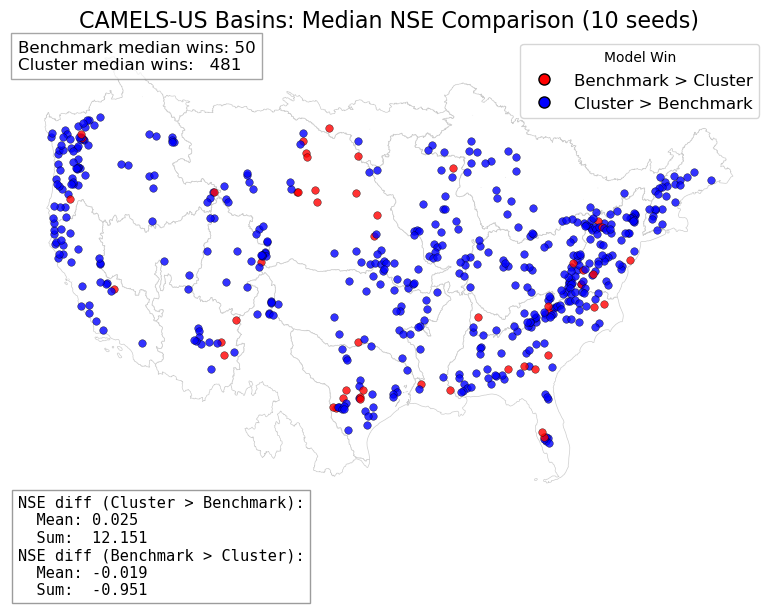

In [102]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D

# === Paths ===
PAPER_DIR  = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
FIGURE_DIR = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

file_cluster   = PAPER_DIR / 'PickleFiles' / 'test_metrics_Cluster_wise_all.xlsx'
file_benchmark = PAPER_DIR / 'PickleFiles' / 'test_metrics_Benchmark_all.xlsx'
huc_gdb        = PAPER_DIR / 'misc' / 'shapefiles' / 'huc_02' / 'huc_02_simplified.gdb'

# === 1) Load HUC-02 background ===
gdf = gpd.read_file(str(huc_gdb))
gdf = gdf.loc[~gdf.huc2.isin(['19','20','21','22'])]

# === 2) Load station attributes ===
attributes_df = camelsus.load_camels_us_attributes(data_dir=Path(r'F:\Experiments\CAMELS_US\Data'))
if 'gauge_id' in attributes_df.columns:
    attributes_df.set_index('gauge_id', inplace=True)
assert 'gauge_lon' in attributes_df.columns and 'gauge_lat' in attributes_df.columns

# === 3) Read Excel test metrics (multiple seeds) and compute median per basin ===
df_cluster_all   = pd.read_excel(file_cluster,   dtype={'basin':str})
df_benchmark_all = pd.read_excel(file_benchmark, dtype={'basin':str})

# compute median NSE across seeds for each basin
cluster_nse   = df_cluster_all.groupby('basin')['NSE'].median().rename('cluster_nse')
benchmark_nse = df_benchmark_all.groupby('basin')['NSE'].median().rename('benchmark_nse')

# combine into one DataFrame
df_nse = pd.concat([cluster_nse, benchmark_nse], axis=1).dropna()

# === 4) Determine color per basin ===
# red if benchmark median > cluster median, else blue
df_nse['color'] = np.where(
    df_nse['benchmark_nse'] > df_nse['cluster_nse'],
    'red',
    'blue'
)

# count wins
benchmark_wins = (df_nse['color'] == 'red').sum()
cluster_wins   = (df_nse['color'] == 'blue').sum()

# === Compute NSE difference statistics ===
df_nse['nse_diff'] = df_nse['cluster_nse'] - df_nse['benchmark_nse']

# For Cluster-wise wins (diff > 0)
cluster_win = df_nse['nse_diff'] > 0
avg_diff_cluster = df_nse.loc[cluster_win, 'nse_diff'].mean()
sum_diff_cluster = df_nse.loc[cluster_win, 'nse_diff'].sum()

# For Benchmark wins (diff < 0)
benchmark_win = df_nse['nse_diff'] < 0
avg_diff_benchmark = df_nse.loc[benchmark_win, 'nse_diff'].mean()
sum_diff_benchmark = df_nse.loc[benchmark_win, 'nse_diff'].sum()

# === 5) Plot ===
fig, ax = plt.subplots(figsize=(20/2.54, 16/2.54))  # 20×16 cm

# background HUC
gdf.plot(ax=ax, facecolor='white', edgecolor='#cccccc', linewidth=0.5)

# scatter basins colored by which model's median NSE is higher
for basin, row in df_nse.iterrows():
    if basin not in attributes_df.index:
        continue
    lon = attributes_df.at[basin, 'gauge_lon']
    lat = attributes_df.at[basin, 'gauge_lat']
    ax.scatter(
        lon, lat,
        c=row['color'],
        s=30,
        edgecolor='k',
        linewidth=0.3,
        alpha=0.8
    )

# annotate win counts
text = (
    f"Benchmark median wins: {benchmark_wins}\n"
    f"Cluster median wins:   {cluster_wins}"
)
ax.text(
    0.01, 0.99, text,
    transform=ax.transAxes,
    fontsize=12,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=5)
)

# === Add your requested summary stats ===
stats_text = (
    "NSE diff (Cluster > Benchmark):\n"
    f"  Mean: {avg_diff_cluster:.3f}\n"
    f"  Sum:  {sum_diff_cluster:.3f}\n"
    "NSE diff (Benchmark > Cluster):\n"
    f"  Mean: {avg_diff_benchmark:.3f}\n"
    f"  Sum:  {sum_diff_benchmark:.3f}"
)
ax.text(
    0.01, 0.02, stats_text,  # 0.02 to avoid overlapping with win counts
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.78, pad=4),
    fontfamily='monospace'
)

# custom legend
legend_elems = [
    Line2D([0], [0], marker='o', color='w', label='Benchmark > Cluster',
           markerfacecolor='red',   markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Cluster > Benchmark',
           markerfacecolor='blue',  markersize=8, markeredgecolor='k'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=12, title='Model Win')

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('CAMELS-US Basins: Median NSE Comparison (10 seeds)', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'map_nse_comparison_median_seeds.jpg',
            dpi=600, format='jpg', bbox_inches='tight')
plt.show()
plt.close()


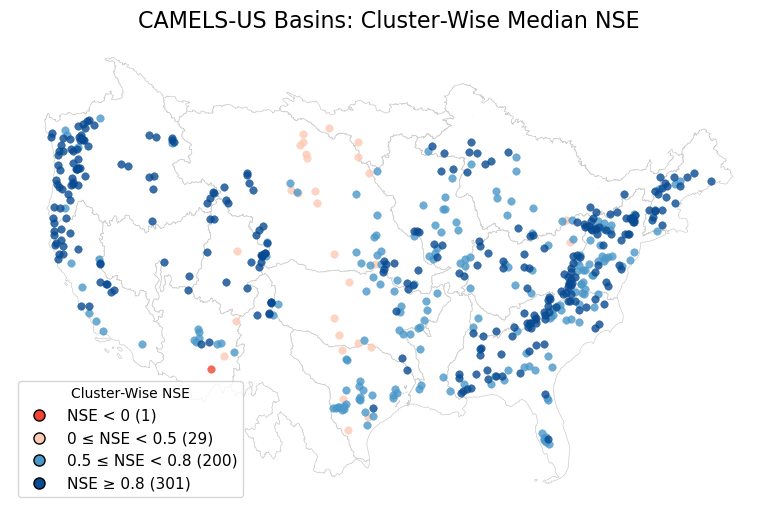

In [103]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D

# === Paths ===
PAPER_DIR   = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
FIGURE_DIR  = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cluster_xlsx = PAPER_DIR / 'PickleFiles' / 'test_metrics_Cluster_wise_all.xlsx'
huc_gdb      = PAPER_DIR / 'misc' / 'shapefiles' / 'huc_02' / 'huc_02_simplified.gdb'

# === 1) Load HUC-02 background ===
gdf = gpd.read_file(str(huc_gdb))
gdf = gdf[~gdf.huc2.isin(['19','20','21','22'])]

# === 2) Load station attributes ===
attributes_df = camelsus.load_camels_us_attributes(
    data_dir=Path(r'F:\Experiments\CAMELS_US\Data')
)
if 'gauge_id' in attributes_df.columns:
    attributes_df = attributes_df.set_index('gauge_id')
assert 'gauge_lon' in attributes_df.columns and 'gauge_lat' in attributes_df.columns

# === 3) Read cluster‐wise metrics & compute median NSE per basin ===
df_cl = pd.read_excel(cluster_xlsx, dtype={'basin':str})
med_nse = df_cl.groupby('basin')['NSE'].median().rename('cluster_nse')

df = med_nse.to_frame().join(
    attributes_df[['gauge_lon','gauge_lat']],
    how='inner'
).dropna()

# === 4) Define the four bin‐colors exactly as in your legend ===
c_neg    = plt.cm.Reds(0.6)   # NSE < 0
c_0_05   = plt.cm.Reds(0.2)   # 0 ≤ NSE < 0.5
c_05_08  = plt.cm.Blues(0.6)  # 0.5 ≤ NSE < 0.8
c_08_1   = plt.cm.Blues(0.9)  # NSE ≥ 0.8

# subset DataFrames
df_neg   = df[df['cluster_nse'] < 0]
df_0_05  = df[(df['cluster_nse'] >= 0.0) & (df['cluster_nse'] < 0.5)]
df_05_08 = df[(df['cluster_nse'] >= 0.5) & (df['cluster_nse'] < 0.8)]
df_08_1  = df[df['cluster_nse'] >= 0.8]

# compute counts for legend
count_neg   = len(df_neg)
count_0_05  = len(df_0_05)
count_05_08 = len(df_05_08)
count_08_1  = len(df_08_1)

# === 5) Plot ===
fig, ax = plt.subplots(figsize=(20/2.54, 16/2.54))  # 20×16 cm

# background HUC
gdf.plot(ax=ax, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)

# plot each bin with its uniform color
ax.scatter(
    df_neg['gauge_lon'], df_neg['gauge_lat'],
    color=c_neg, s=30, linewidth=0.3, alpha=0.8
)
ax.scatter(
    df_0_05['gauge_lon'], df_0_05['gauge_lat'],
    color=c_0_05, s=30, linewidth=0.3, alpha=0.8
)
ax.scatter(
    df_05_08['gauge_lon'], df_05_08['gauge_lat'],
    color=c_05_08, s=30, linewidth=0.3, alpha=0.8
)
ax.scatter(
    df_08_1['gauge_lon'], df_08_1['gauge_lat'],
    color=c_08_1, s=30, linewidth=0.3, alpha=0.8
)

# build a custom legend with counts
legend_elems = [
    Line2D([0], [0], marker='o', color='w',
           label=f'NSE < 0 ({count_neg})',
           markerfacecolor=c_neg,   markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w',
           label=f'0 ≤ NSE < 0.5 ({count_0_05})',
           markerfacecolor=c_0_05,  markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w',
           label=f'0.5 ≤ NSE < 0.8 ({count_05_08})',
           markerfacecolor=c_05_08, markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w',
           label=f'NSE ≥ 0.8 ({count_08_1})',
           markerfacecolor=c_08_1,  markersize=8, markeredgecolor='k'),
]
ax.legend(handles=legend_elems, loc='lower left', fontsize=11, title='Cluster‐Wise NSE')

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('CAMELS-US Basins: Cluster‐Wise Median NSE', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / 'map_cluster_median_nse_custom_bins_with_counts.jpg',
    dpi=600, format='jpg', bbox_inches='tight'
)
plt.show()
plt.close()


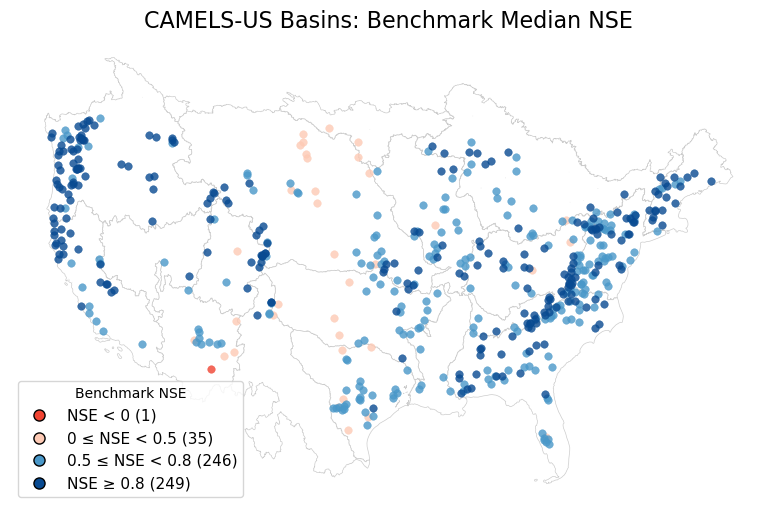

In [104]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D

# === Paths ===
PAPER_DIR     = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
FIGURE_DIR    = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

benchmark_xlsx = PAPER_DIR / 'PickleFiles' / 'test_metrics_Benchmark_all.xlsx'
huc_gdb        = PAPER_DIR / 'misc' / 'shapefiles' / 'huc_02' / 'huc_02_simplified.gdb'

# === 1) Load HUC-02 background ===
gdf = gpd.read_file(str(huc_gdb))
gdf = gdf[~gdf.huc2.isin(['19','20','21','22'])]

# === 2) Load station attributes ===
attributes_df = camelsus.load_camels_us_attributes(
    data_dir=Path(r'F:\Experiments\CAMELS_US\Data')
)
if 'gauge_id' in attributes_df.columns:
    attributes_df = attributes_df.set_index('gauge_id')
assert 'gauge_lon' in attributes_df.columns and 'gauge_lat' in attributes_df.columns

# === 3) Read benchmark metrics & compute median NSE per basin ===
df_bm = pd.read_excel(benchmark_xlsx, dtype={'basin':str})
med_nse = df_bm.groupby('basin')['NSE'].median().rename('benchmark_nse')

df = med_nse.to_frame().join(
    attributes_df[['gauge_lon','gauge_lat']],
    how='inner'
).dropna()

# === 4) Define the four bin‐colors exactly as in your legend ===
c_neg    = plt.cm.Reds(0.6)   # NSE < 0
c_0_05   = plt.cm.Reds(0.2)   # 0 ≤ NSE < 0.5
c_05_08  = plt.cm.Blues(0.6)  # 0.5 ≤ NSE < 0.8
c_08_1   = plt.cm.Blues(0.9)  # NSE ≥ 0.8

# subset DataFrames by benchmark_nse
df_neg   = df[df['benchmark_nse'] < 0]
df_0_05  = df[(df['benchmark_nse'] >= 0.0) & (df['benchmark_nse'] < 0.5)]
df_05_08 = df[(df['benchmark_nse'] >= 0.5) & (df['benchmark_nse'] < 0.8)]
df_08_1  = df[df['benchmark_nse'] >= 0.8]

# compute counts for legend
count_neg   = len(df_neg)
count_0_05  = len(df_0_05)
count_05_08 = len(df_05_08)
count_08_1  = len(df_08_1)

# === 5) Plot ===
fig, ax = plt.subplots(figsize=(20/2.54, 16/2.54))  # 20×16 cm

# background HUC
gdf.plot(ax=ax, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)

# plot each bin with its uniform color
ax.scatter(
    df_neg['gauge_lon'], df_neg['gauge_lat'],
    color=c_neg, s=30, linewidth=0.3, alpha=0.8
)
ax.scatter(
    df_0_05['gauge_lon'], df_0_05['gauge_lat'],
    color=c_0_05, s=30, linewidth=0.3, alpha=0.8
)
ax.scatter(
    df_05_08['gauge_lon'], df_05_08['gauge_lat'],
    color=c_05_08, s=30, linewidth=0.3, alpha=0.8
)
ax.scatter(
    df_08_1['gauge_lon'], df_08_1['gauge_lat'],
    color=c_08_1, s=30, linewidth=0.3, alpha=0.8
)

# build a custom legend with counts
legend_elems = [
    Line2D([0], [0], marker='o', color='w',
           label=f'NSE < 0 ({count_neg})',
           markerfacecolor=c_neg,   markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w',
           label=f'0 ≤ NSE < 0.5 ({count_0_05})',
           markerfacecolor=c_0_05,  markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w',
           label=f'0.5 ≤ NSE < 0.8 ({count_05_08})',
           markerfacecolor=c_05_08, markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w',
           label=f'NSE ≥ 0.8 ({count_08_1})',
           markerfacecolor=c_08_1,  markersize=8, markeredgecolor='k'),
]
ax.legend(handles=legend_elems, loc='lower left', fontsize=11, title='Benchmark NSE')

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('CAMELS-US Basins: Benchmark Median NSE', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / 'map_benchmark_median_nse_custom_bins_with_counts.jpg',
    dpi=600, format='jpg', bbox_inches='tight'
)
plt.show()
plt.close()


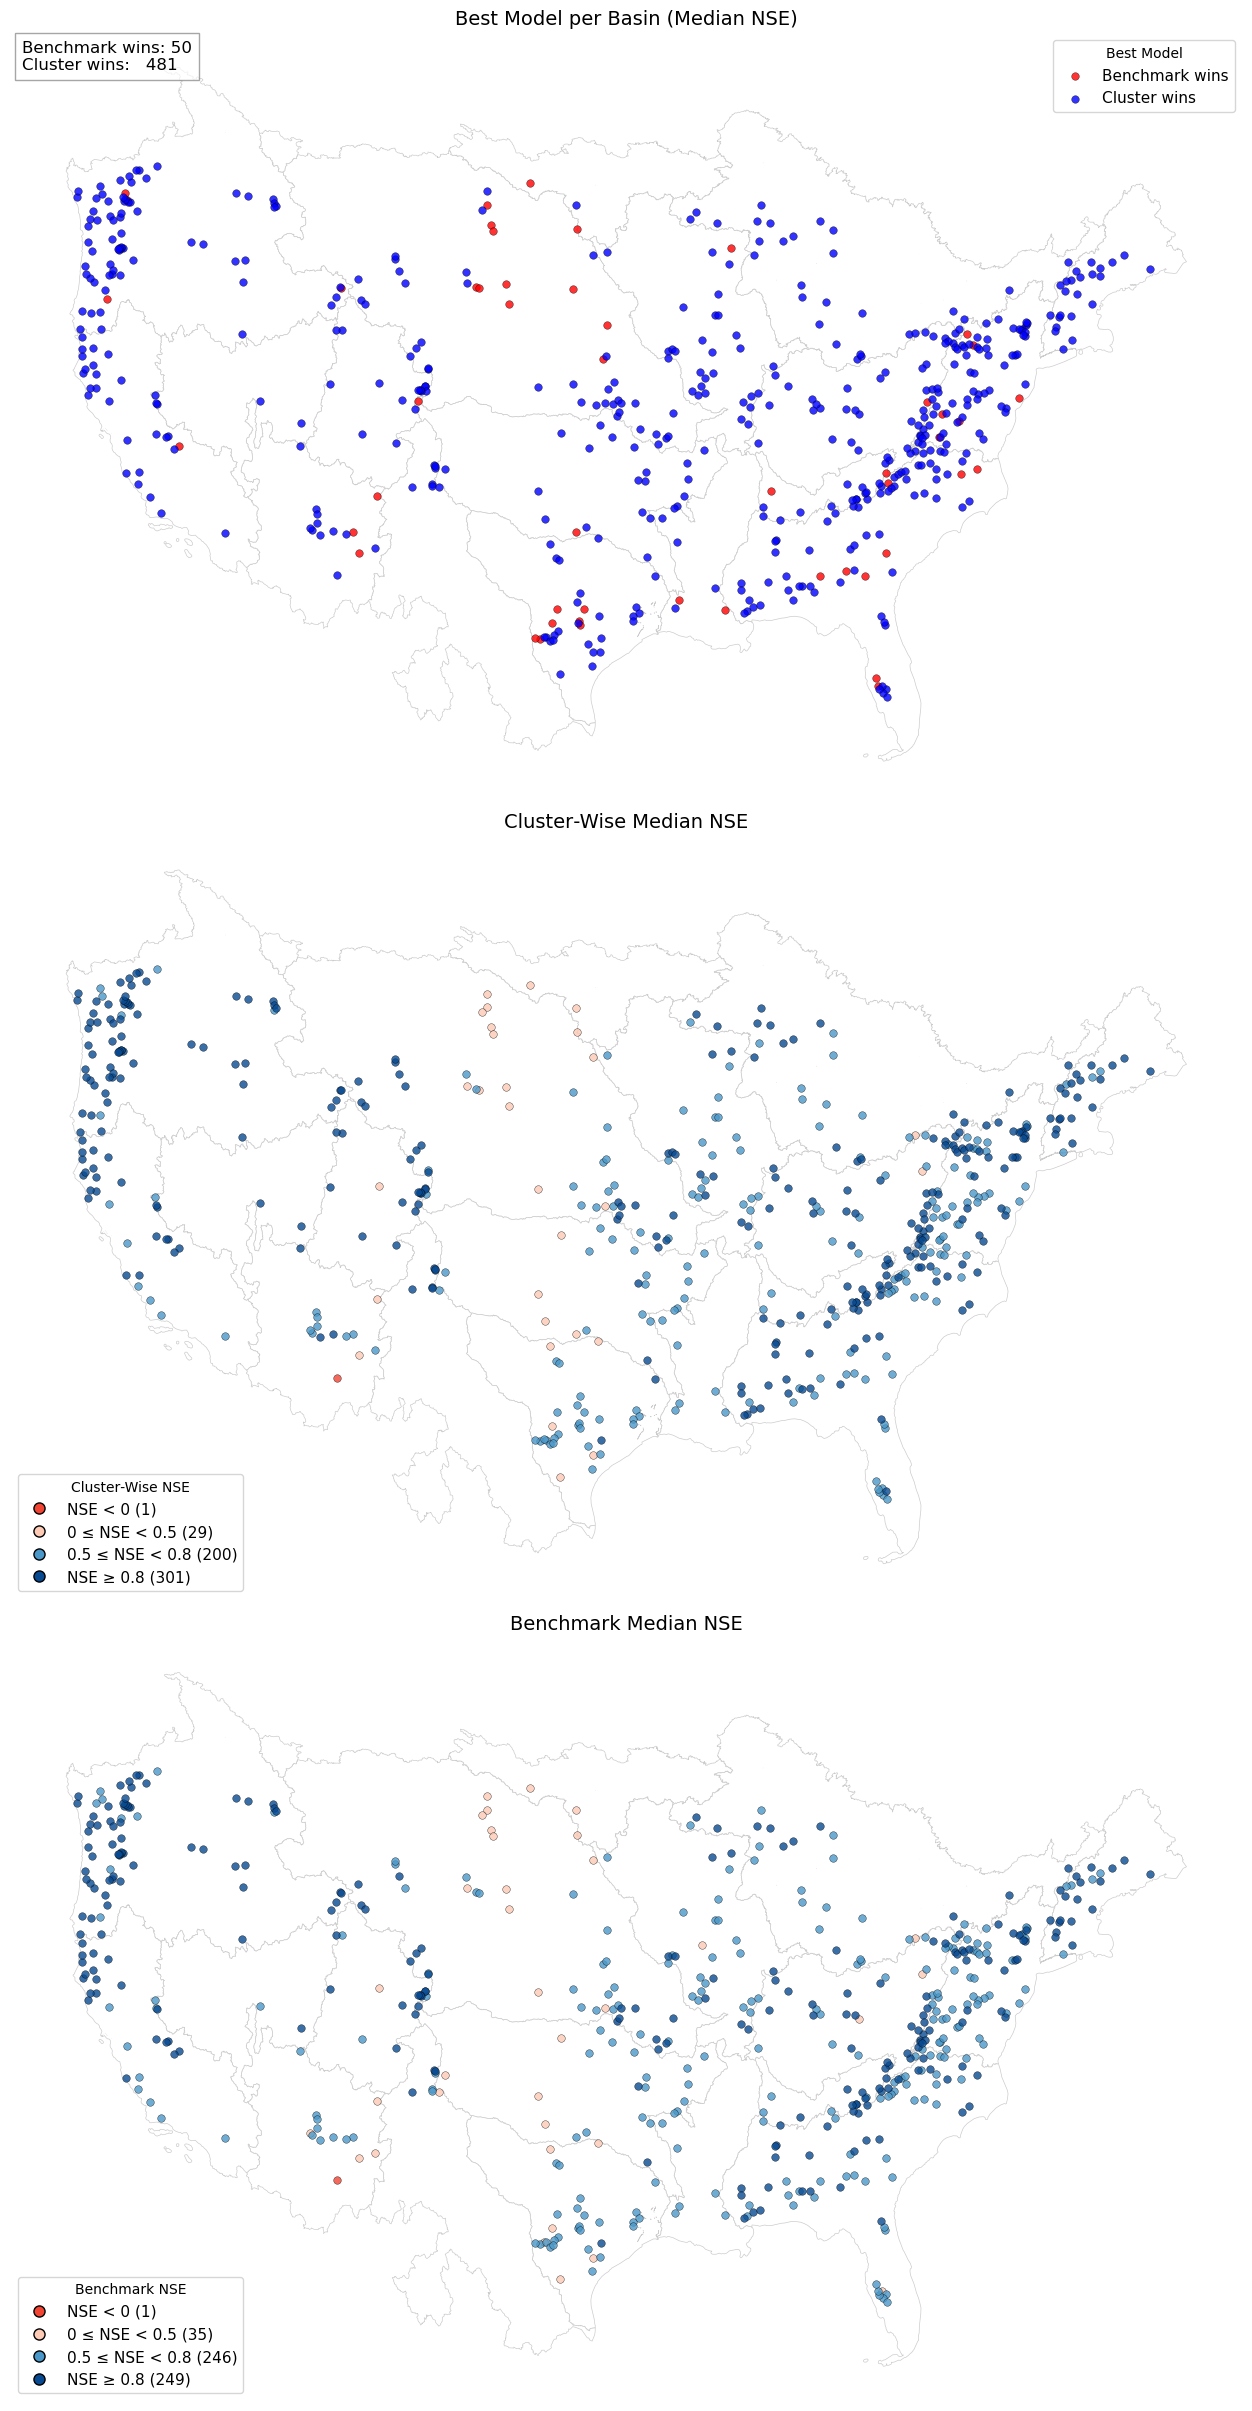

In [105]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D

# === Paths ===
PAPER_DIR     = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
FIGURE_DIR    = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cluster_xlsx   = PAPER_DIR / 'PickleFiles' / 'test_metrics_Cluster_wise_all.xlsx'
benchmark_xlsx = PAPER_DIR / 'PickleFiles' / 'test_metrics_Benchmark_all.xlsx'
huc_gdb        = PAPER_DIR / 'misc' / 'shapefiles' / 'huc_02' / 'huc_02_simplified.gdb'

# === 1) Load HUC-02 background ===
gdf = gpd.read_file(str(huc_gdb))
gdf = gdf[~gdf.huc2.isin(['19','20','21','22'])]

# === 2) Load station attributes ===
attributes_df = camelsus.load_camels_us_attributes(data_dir=Path(r'F:\Experiments\CAMELS_US\Data'))
if 'gauge_id' in attributes_df.columns:
    attributes_df = attributes_df.set_index('gauge_id')
assert 'gauge_lon' in attributes_df.columns and 'gauge_lat' in attributes_df.columns

# === 3) Read and compute median NSE per basin ===
df_cl = pd.read_excel(cluster_xlsx,   dtype={'basin':str})
df_bm = pd.read_excel(benchmark_xlsx, dtype={'basin':str})

cluster_nse   = df_cl.groupby('basin')['NSE'].median().rename('cluster_nse')
benchmark_nse = df_bm.groupby('basin')['NSE'].median().rename('benchmark_nse')

df_nse = pd.concat([cluster_nse, benchmark_nse], axis=1).dropna()
df_nse['best_model'] = np.where(
    df_nse['benchmark_nse'] > df_nse['cluster_nse'],
    'benchmark', 'cluster'
)
df_nse = df_nse.join(attributes_df[['gauge_lon','gauge_lat']], how='inner')

# === 4) Define bin masks & colors ===
bins = {
    'NSE < 0':         (df_nse['cluster_nse'] < 0,          plt.cm.Reds(0.6)),
    '0 ≤ NSE < 0.5':   ((df_nse['cluster_nse'] >= 0) & (df_nse['cluster_nse'] < 0.5), plt.cm.Reds(0.2)),
    '0.5 ≤ NSE < 0.8': ((df_nse['cluster_nse'] >= 0.5) & (df_nse['cluster_nse'] < 0.8), plt.cm.Blues(0.6)),
    'NSE ≥ 0.8':       (df_nse['cluster_nse'] >= 0.8,       plt.cm.Blues(0.9)),
}
bm_bins = {
    'NSE < 0':         (df_nse['benchmark_nse'] < 0,          plt.cm.Reds(0.6)),
    '0 ≤ NSE < 0.5':   ((df_nse['benchmark_nse'] >= 0) & (df_nse['benchmark_nse'] < 0.5), plt.cm.Reds(0.2)),
    '0.5 ≤ NSE < 0.8': ((df_nse['benchmark_nse'] >= 0.5) & (df_nse['benchmark_nse'] < 0.8), plt.cm.Blues(0.6)),
    'NSE ≥ 0.8':       (df_nse['benchmark_nse'] >= 0.8,       plt.cm.Blues(0.9)),
}

# === 5) Create 3‐panel figure ===
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(20, 24),
    constrained_layout=True
)

# --- Panel 1: Best‐model wins ---
gdf.plot(ax=ax1, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)
for model, color in [('benchmark','red'), ('cluster','blue')]:
    sub = df_nse[df_nse['best_model']==model]
    ax1.scatter(
        sub['gauge_lon'], sub['gauge_lat'],
        c=color, s=30, edgecolor='k', linewidth=0.3, alpha=0.8,
        label=f"{model.title()} wins"
    )
bw = (df_nse['best_model']=='benchmark').sum()
cw = (df_nse['best_model']=='cluster').sum()
ax1.text(
    0.01, 0.99,
    f"Benchmark wins: {bw}\nCluster wins:   {cw}",
    transform=ax1.transAxes, va='top', ha='left',
    fontsize=12, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=5)
)
ax1.legend(loc='upper right', title='Best Model', fontsize=11)
ax1.set_title("Best Model per Basin (Median NSE)", fontsize=14)
ax1.set_axis_off()

# --- Panel 2: Cluster‐Wise Median NSE ---
gdf.plot(ax=ax2, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)
legend_elems = []
for label, (mask, color) in bins.items():
    sub = df_nse[mask]
    ax2.scatter(
        sub['gauge_lon'], sub['gauge_lat'],
        color=color, s=30, edgecolor='k', linewidth=0.3, alpha=0.8
    )
    legend_elems.append(
        Line2D([0], [0], marker='o', color='w',
               label=f"{label} ({len(sub)})",
               markerfacecolor=color, markersize=8, markeredgecolor='k')
    )
ax2.legend(handles=legend_elems, loc='lower left', title='Cluster‐Wise NSE', fontsize=11)
ax2.set_title("Cluster‐Wise Median NSE", fontsize=14)
ax2.set_axis_off()

# --- Panel 3: Benchmark Median NSE ---
gdf.plot(ax=ax3, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)
legend_elems = []
for label, (mask, color) in bm_bins.items():
    sub = df_nse[mask]
    ax3.scatter(
        sub['gauge_lon'], sub['gauge_lat'],
        color=color, s=30, edgecolor='k', linewidth=0.3, alpha=0.8
    )
    legend_elems.append(
        Line2D([0], [0], marker='o', color='w',
               label=f"{label} ({len(sub)})",
               markerfacecolor=color, markersize=8, markeredgecolor='k')
    )
ax3.legend(handles=legend_elems, loc='lower left', title='Benchmark NSE', fontsize=11)
ax3.set_title("Benchmark Median NSE", fontsize=14)
ax3.set_axis_off()

# === 6) Save ===
out_file = FIGURE_DIR / 'nse_threepanel_overview.jpg'
plt.savefig(out_file, dpi=600, format='jpg', bbox_inches='tight')
plt.show()
plt.close()


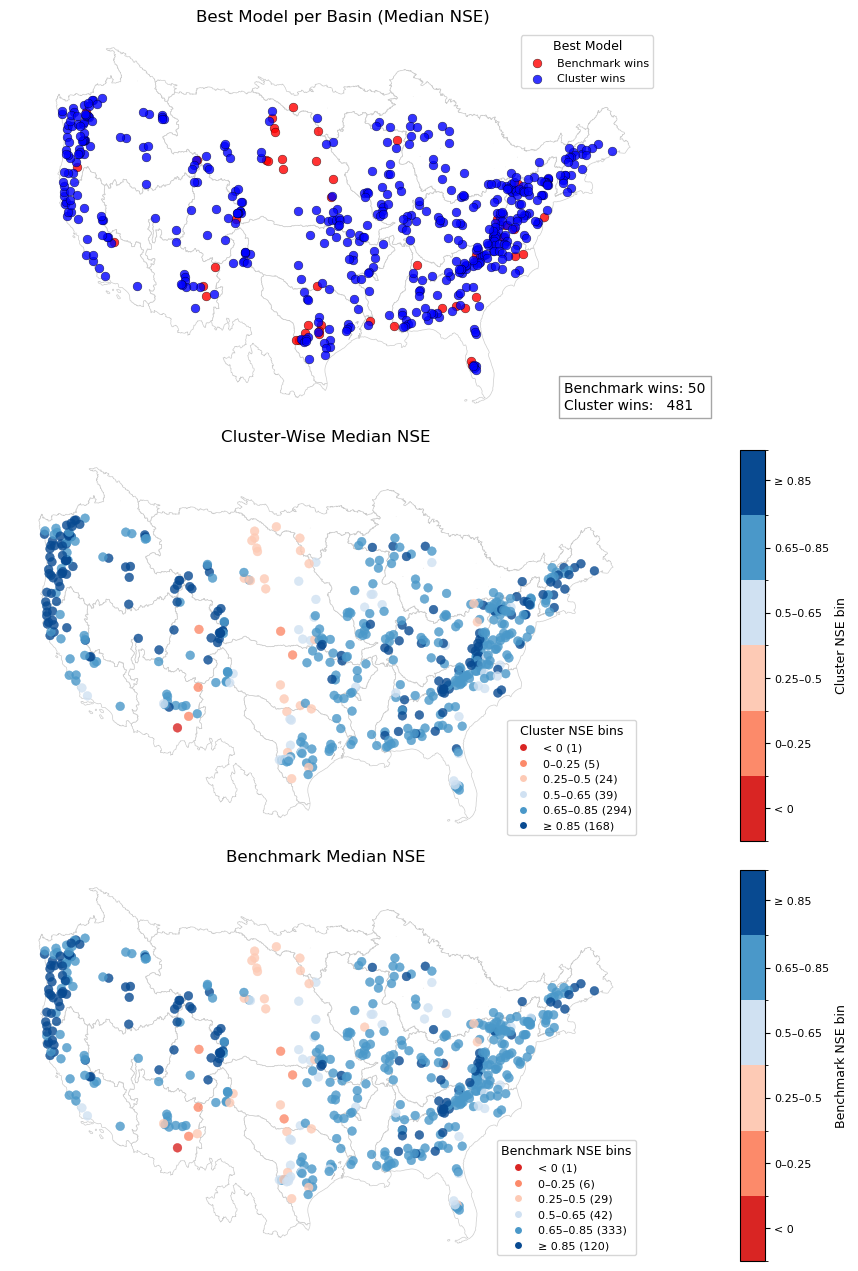

In [107]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as cm
from matplotlib.cm import ScalarMappable

# === Paths ===
PAPER_DIR     = Path(r'F:\Experiments\CAMELS_US\TrainsTests')
FIGURE_DIR    = PAPER_DIR / 'Results' / 'Plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cluster_xlsx   = PAPER_DIR / 'PickleFiles' / 'test_metrics_Cluster_wise_all.xlsx'
benchmark_xlsx = PAPER_DIR / 'PickleFiles' / 'test_metrics_Benchmark_all.xlsx'
huc_gdb        = PAPER_DIR / 'misc' / 'shapefiles' / 'huc_02' / 'huc_02_simplified.gdb'

# === 1) Load background ===
gdf = gpd.read_file(str(huc_gdb))
gdf = gdf[~gdf.huc2.isin(['19','20','21','22'])]

# === 2) Load station coords ===
attributes_df = camelsus.load_camels_us_attributes(
    data_dir=Path(r'F:\Experiments\CAMELS_US\Data')
)
if 'gauge_id' in attributes_df.columns:
    attributes_df = attributes_df.set_index('gauge_id')

# === 3) Read & median‐aggregate NSE ===
df_cl = pd.read_excel(cluster_xlsx,   dtype={'basin':str})
df_bm = pd.read_excel(benchmark_xlsx, dtype={'basin':str})
cluster_nse   = df_cl.groupby('basin')['NSE'].median().rename('cluster_nse')
benchmark_nse = df_bm.groupby('basin')['NSE'].median().rename('benchmark_nse')

df = pd.concat([cluster_nse, benchmark_nse], axis=1).dropna()
df['best_model'] = np.where(
    df['benchmark_nse'] > df['cluster_nse'], 'benchmark', 'cluster'
)
df = df.join(attributes_df[['gauge_lon','gauge_lat']], how='inner').dropna()

# === 4) Define bins & colormap (6 bins) ===
colors = [
    plt.cm.Reds(0.7),   # <0
    plt.cm.Reds(0.4),   # 0–0.25
    plt.cm.Reds(0.2),   # 0.25–0.5
    plt.cm.Blues(0.2),  # 0.5–0.65
    plt.cm.Blues(0.6),  # 0.65–0.85
    plt.cm.Blues(0.9)   # ≥0.85
]
cmap_bins = ListedColormap(colors)
bounds = [-1, 0, 0.25, 0.5, 0.65, 0.85, 1]
norm_bins = BoundaryNorm(bounds, ncolors=cmap_bins.N, clip=True)
bin_labels = ['< 0', '0–0.25', '0.25–0.5', '0.5–0.65', '0.65–0.85', '≥ 0.85']
bin_ticks = [-0.5, 0.125, 0.375, 0.575, 0.75, 0.93]

# === 5) Create 3‐panel figure ===
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(24/2.54, 32/2.54),
    sharex=True, sharey=True,
    constrained_layout=True
)

# Panel 1: Best‐model wins
gdf.plot(ax=ax1, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)
for model, color in [('benchmark','red'), ('cluster','blue')]:
    sub = df[df['best_model']==model]
    ax1.scatter(
        sub['gauge_lon'], sub['gauge_lat'],
        c=color, s=40, edgecolor='k', linewidth=0.3, alpha=0.8,
        label=f"{model.title()} wins"
    )
bw = (df['best_model']=='benchmark').sum()
cw = (df['best_model']=='cluster').sum()
ax1.text(
    0.85, 0.1,
    f"Benchmark wins: {bw}\nCluster wins:   {cw}",
    transform=ax1.transAxes, ha='left', va='top',
    fontsize=10, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=4)
)
ax1.legend(loc='upper right', title='Best Model', fontsize=8, title_fontsize=9)
ax1.set_title("Best Model per Basin (Median NSE)", fontsize=12)
ax1.set_axis_off()

# Panel 2: Cluster‐Wise Median NSE
gdf.plot(ax=ax2, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)
sc2 = ax2.scatter(
    df['gauge_lon'], df['gauge_lat'],
    c=df['cluster_nse'], cmap=cmap_bins, norm=norm_bins,
    s=40, linewidth=0.3, alpha=0.8
)
ax2.set_title("Cluster‐Wise Median NSE", fontsize=12)
ax2.set_axis_off()

# legend for panel 2
legend_elems = []
for i, label in enumerate(bin_labels):
    count = len(df[(df['cluster_nse'] >= bounds[i]) & (df['cluster_nse'] < bounds[i+1])])
    legend_elems.append(
        Line2D([0],[0], marker='o', color='w',
               label=f"{label} ({count})",
               markerfacecolor=colors[i],
               markersize=6)
    )
ax2.legend(handles=legend_elems, loc='lower right', title='Cluster NSE bins',
           fontsize=8, title_fontsize=9)

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.1)
cb2 = fig.colorbar(ScalarMappable(norm=norm_bins, cmap=cmap_bins),
                   cax=cax2, boundaries=bounds, ticks=bin_ticks)
cb2.ax.set_yticklabels(bin_labels)
cb2.ax.tick_params(labelsize=8)
cb2.set_label('Cluster NSE bin', fontsize=9)

# Panel 3: Benchmark Median NSE
gdf.plot(ax=ax3, facecolor='white', edgecolor='#CCCCCC', linewidth=0.5)
sc3 = ax3.scatter(
    df['gauge_lon'], df['gauge_lat'],
    c=df['benchmark_nse'], cmap=cmap_bins, norm=norm_bins,
    s=40, linewidth=0.3, alpha=0.8
)
ax3.set_title("Benchmark Median NSE", fontsize=12)
ax3.set_axis_off()

# legend for panel 3
legend_elems = []
for i, label in enumerate(bin_labels):
    count = len(df[(df['benchmark_nse'] >= bounds[i]) & (df['benchmark_nse'] < bounds[i+1])])
    legend_elems.append(
        Line2D([0],[0], marker='o', color='w',
               label=f"{label} ({count})",
               markerfacecolor=colors[i],
               markersize=6)
    )
ax3.legend(handles=legend_elems, loc='lower right', title='Benchmark NSE bins',
           fontsize=8, title_fontsize=9)

divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes("right", size="3%", pad=0.1)
cb3 = fig.colorbar(ScalarMappable(norm=norm_bins, cmap=cmap_bins),
                   cax=cax3, boundaries=bounds, ticks=bin_ticks)
cb3.ax.set_yticklabels(bin_labels)
cb3.ax.tick_params(labelsize=8)
cb3.set_label('Benchmark NSE bin', fontsize=9)

# === 6) Save ===
out_file = FIGURE_DIR / 'nse_threepanel_overview_with_colorbars_aligned.jpg'
plt.savefig(out_file, dpi=600, format='jpg', bbox_inches='tight')
plt.show()
plt.close()


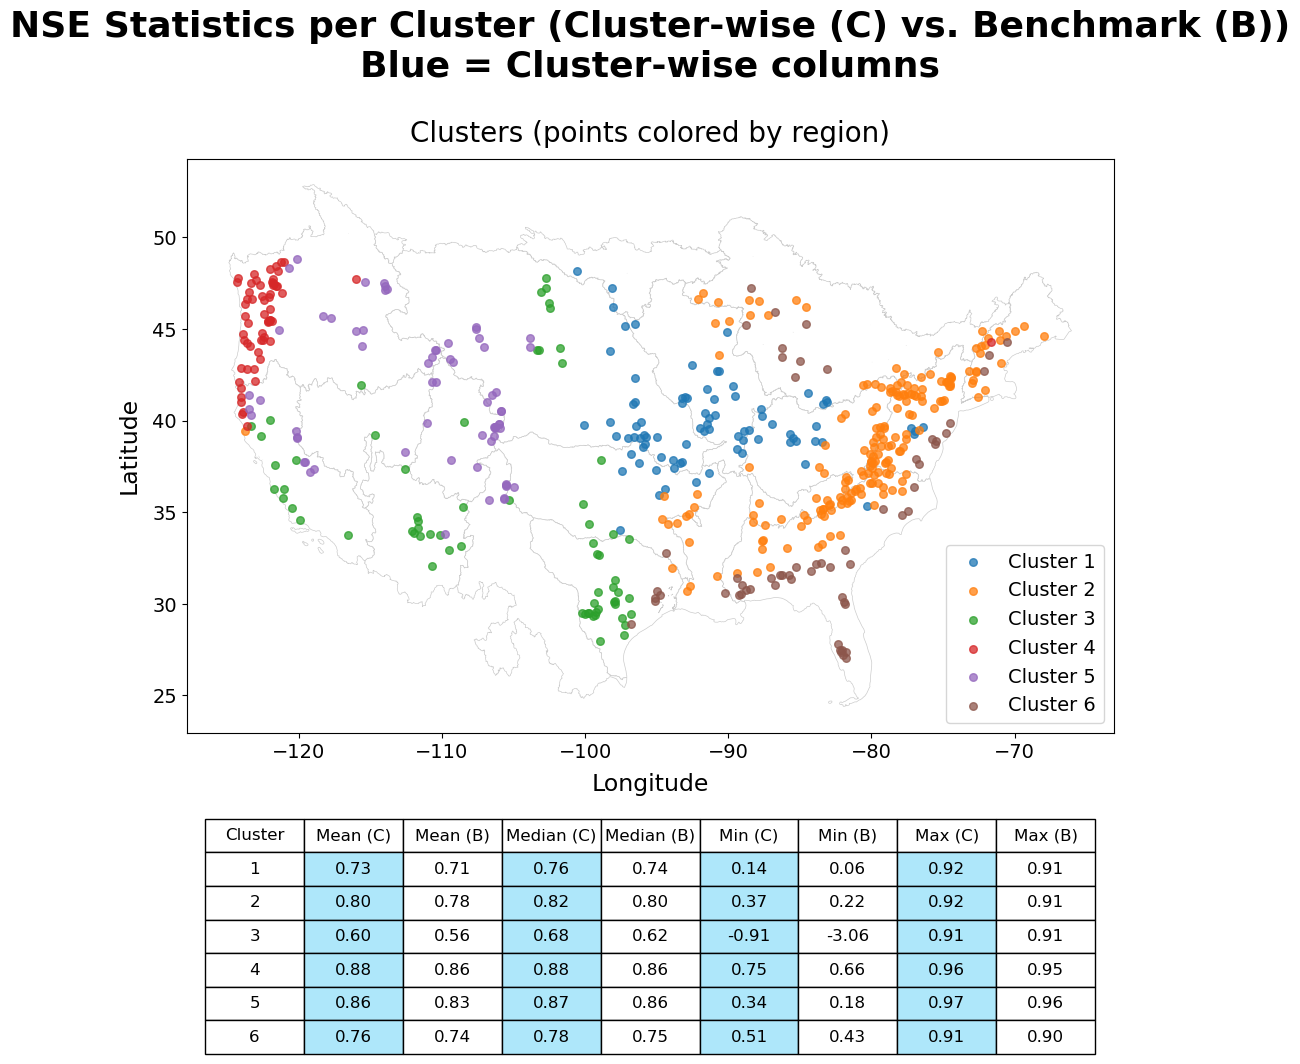

In [130]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load Excel files
file_path_cluster = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Cluster_wise_all.xlsx'
file_path_benchmark = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Benchmark_all.xlsx'

df_cluster = pd.read_excel(file_path_cluster, dtype={'basin': str})
df_benchmark = pd.read_excel(file_path_benchmark, dtype={'basin': str})

# --- Calculate NSE stats per cluster/region
table_rows = []
for cluster, basins_ids in cluster_to_basin_ids.items():
    cluster_nse = df_cluster[df_cluster['basin'].isin(basins_ids)]['NSE']
    bench_nse   = df_benchmark[df_benchmark['basin'].isin(basins_ids)]['NSE']
    stats = {
        'Cluster': int(cluster) + 1,
        'Mean_C': np.mean(cluster_nse),
        'Mean_B': np.mean(bench_nse),
        'Median_C': np.median(cluster_nse),
        'Median_B': np.median(bench_nse),
        'Min_C': np.min(cluster_nse),
        'Min_B': np.min(bench_nse),
        'Max_C': np.max(cluster_nse),
        'Max_B': np.max(bench_nse)
    }
    table_rows.append(stats)

table_df = pd.DataFrame(table_rows).sort_values('Cluster')

# --- Figure settings ---
fig_w, fig_h = 38, 27  # in centimeters
figsize = (fig_w / 2.54, fig_h / 2.54)
fig = plt.figure(figsize=figsize)

# Map axis: Only top 60% of figure
map_rect = [0.05, 0.39, 0.9, 0.54]  # [left, bottom, width, height]
ax_map = fig.add_axes(map_rect)
gdf.plot(ax=ax_map, facecolor="white", edgecolor="#cccccc", linewidth=0.5)
for cluster, basins_ids in cluster_to_basin_ids.items():
    x = attributes_df.loc[basins_ids, 'gauge_lon'].values
    y = attributes_df.loc[basins_ids, 'gauge_lat'].values
    ax_map.scatter(x, y, color=f"C{cluster}", label=f"Cluster {int(cluster)+1}", alpha=0.75, s=30)
ax_map.legend(fontsize=14, loc='lower right')
ax_map.set_xlabel("Longitude", fontsize=17, labelpad=8)
ax_map.set_ylabel("Latitude", fontsize=17, labelpad=8)
ax_map.set_title("Clusters (points colored by region)", fontsize=20, pad=12)
ax_map.tick_params(axis='both', which='major', labelsize=14)

# --- Add suptitle (well above the map)
plt.figtext(0.5, 1.07,
    "NSE Statistics per Cluster (Cluster-wise (C) vs. Benchmark (B))\nBlue = Cluster-wise columns",
    fontsize=26, ha='center', va='top', weight='bold')

# --- Table: add to the figure, not as subplot ---
display_df = table_df.copy()
display_df = display_df[
    ['Cluster', 'Mean_C', 'Mean_B', 'Median_C', 'Median_B', 'Min_C', 'Min_B', 'Max_C', 'Max_B']
]
for col in display_df.columns:
    if col != 'Cluster':
        display_df[col] = display_df[col].apply(lambda v: f"{v:.2f}")

col_labels = [
    "Cluster", "Mean (C)", "Mean (B)", "Median (C)", "Median (B)",
    "Min (C)", "Min (B)", "Max (C)", "Max (B)"
]
cell_col_blue = "#aee7fa"  # pastel blue
cell_col_white = "white"
colors = []
for i, row in display_df.iterrows():
    colors.append([
        cell_col_white,   # Cluster
        cell_col_blue,    # Mean_C
        cell_col_white,   # Mean_B
        cell_col_blue,    # Median_C
        cell_col_white,   # Median_B
        cell_col_blue,    # Min_C
        cell_col_white,   # Min_B
        cell_col_blue,    # Max_C
        cell_col_white    # Max_B
    ])
table = plt.table(
    cellText=display_df.values,
    colLabels=col_labels,
    cellColours=colors,
    cellLoc='center', colLoc='center',
    loc='bottom',
    bbox=[0.02, -0.56, 0.96, 0.41]  # [left, bottom, width, height]
)
table.auto_set_font_size(False)
table.set_fontsize(12)

plt.subplots_adjust(top=0.87, bottom=0.31, left=0.04, right=0.98)
plt.savefig(FIGURE_DIR / "map_attribute_split_with_nse_stats_colorful_table_final_fixed.jpg", bbox_inches="tight", format="jpg", dpi=600)
plt.show()


In [131]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_cluster_map_table_for_metric(metric,
    df_cluster,
    df_benchmark,
    cluster_to_basin_ids,
    attributes_df,
    gdf,
    FIGURE_DIR,
    cmap_blue="#aee7fa",
    cmap_white="white"
):
    # --- Calculate stats per cluster/region ---
    table_rows = []
    for cluster, basins_ids in cluster_to_basin_ids.items():
        cluster_vals = df_cluster[df_cluster['basin'].isin(basins_ids)][metric]
        bench_vals   = df_benchmark[df_benchmark['basin'].isin(basins_ids)][metric]
        stats = {
            'Cluster': int(cluster) + 1,
            'Mean_C': np.mean(cluster_vals),
            'Mean_B': np.mean(bench_vals),
            'Median_C': np.median(cluster_vals),
            'Median_B': np.median(bench_vals),
            'Min_C': np.min(cluster_vals),
            'Min_B': np.min(bench_vals),
            'Max_C': np.max(cluster_vals),
            'Max_B': np.max(bench_vals)
        }
        table_rows.append(stats)
    table_df = pd.DataFrame(table_rows).sort_values('Cluster')

    # --- Figure settings ---
    fig_w, fig_h = 38, 27  # in centimeters
    figsize = (fig_w / 2.54, fig_h / 2.54)
    fig = plt.figure(figsize=figsize)

    # Map axis: Only top 60% of figure
    map_rect = [0.05, 0.39, 0.9, 0.54]  # [left, bottom, width, height]
    ax_map = fig.add_axes(map_rect)
    gdf.plot(ax=ax_map, facecolor="white", edgecolor="#cccccc", linewidth=0.5)
    for cluster, basins_ids in cluster_to_basin_ids.items():
        x = attributes_df.loc[basins_ids, 'gauge_lon'].values
        y = attributes_df.loc[basins_ids, 'gauge_lat'].values
        ax_map.scatter(x, y, color=f"C{cluster}", label=f"Cluster {int(cluster)+1}", alpha=0.75, s=30)
    ax_map.legend(fontsize=14, loc='lower right')
    ax_map.set_xlabel("Longitude", fontsize=17, labelpad=8)
    ax_map.set_ylabel("Latitude", fontsize=17, labelpad=8)
    ax_map.set_title(f"Clusters (points colored by region): {metric}", fontsize=20, pad=12)
    ax_map.tick_params(axis='both', which='major', labelsize=14)

    # --- Add suptitle (well above the map)
    plt.figtext(0.5, 1.07,
        f"{metric} Statistics per Cluster (Cluster-wise (C) vs. Benchmark (B))\nBlue = Cluster-wise columns",
        fontsize=26, ha='center', va='top', weight='bold')

    # --- Table: add to the figure, not as subplot ---
    display_df = table_df.copy()
    display_df = display_df[
        ['Cluster', 'Mean_C', 'Mean_B', 'Median_C', 'Median_B', 'Min_C', 'Min_B', 'Max_C', 'Max_B']
    ]
    for col in display_df.columns:
        if col != 'Cluster':
            display_df[col] = display_df[col].apply(lambda v: f"{v:.2f}")

    col_labels = [
        "Cluster", "Mean (C)", "Mean (B)", "Median (C)", "Median (B)",
        "Min (C)", "Min (B)", "Max (C)", "Max (B)"
    ]
    colors = []
    for i, row in display_df.iterrows():
        colors.append([
            cmap_white,   # Cluster
            cmap_blue,    # Mean_C
            cmap_white,   # Mean_B
            cmap_blue,    # Median_C
            cmap_white,   # Median_B
            cmap_blue,    # Min_C
            cmap_white,   # Min_B
            cmap_blue,    # Max_C
            cmap_white    # Max_B
        ])
    table = plt.table(
        cellText=display_df.values,
        colLabels=col_labels,
        cellColours=colors,
        cellLoc='center', colLoc='center',
        loc='bottom',
        bbox=[0.02, -0.56, 0.96, 0.41]  # [left, bottom, width, height]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)

    plt.subplots_adjust(top=0.87, bottom=0.31, left=0.04, right=0.98)
    filename = f"map_attribute_split_with_{metric.lower()}_stats_colorful_table.jpg"
    plt.savefig(FIGURE_DIR / filename, bbox_inches="tight", format="jpg", dpi=600)
    plt.close()
    print(f"Saved: {filename}")

# --------- USAGE EXAMPLE (batch plotting) ---------

# Define your list of metrics (matching your Excel files):
all_metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

for metric in all_metrics:
    plot_cluster_map_table_for_metric(
        metric,
        df_cluster,
        df_benchmark,
        cluster_to_basin_ids,
        attributes_df,
        gdf,
        FIGURE_DIR
    )


Saved: map_attribute_split_with_nse_stats_colorful_table.jpg
Saved: map_attribute_split_with_kge_stats_colorful_table.jpg
Saved: map_attribute_split_with_mse_stats_colorful_table.jpg
Saved: map_attribute_split_with_rmse_stats_colorful_table.jpg
Saved: map_attribute_split_with_alpha-nse_stats_colorful_table.jpg
Saved: map_attribute_split_with_beta-kge_stats_colorful_table.jpg
Saved: map_attribute_split_with_beta-nse_stats_colorful_table.jpg
Saved: map_attribute_split_with_fms_stats_colorful_table.jpg
Saved: map_attribute_split_with_fhv_stats_colorful_table.jpg
Saved: map_attribute_split_with_flv_stats_colorful_table.jpg
Saved: map_attribute_split_with_peak-mape_stats_colorful_table.jpg
Saved: map_attribute_split_with_peak-timing_stats_colorful_table.jpg
Saved: map_attribute_split_with_missed-peaks_stats_colorful_table.jpg


In [140]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Directory to save the plots
FIGURE_DIR = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(FIGURE_DIR, exist_ok=True)

# Function to plot histograms for a single metric
def create_single_metric_histogram(test_metrics_dicts, metric_key, bins=30):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Color mapping for models
    colors = {
        'Benchmark': 'orange',
        'Cluster_wise': 'blue',
    }

    # --- 1. Gather metric values for both models
    metric_values = {}
    for model in colors.keys():
        vals = []
        test_metrics = test_metrics_dicts[model]
        for basin_id, basin_data in test_metrics.items():
            for site_id, site_metrics in basin_data.items():
                if metric_key in site_metrics:
                    vals.append(site_metrics[metric_key])
        metric_values[model] = np.array(vals)

    # --- 2. Set common bins (using combined data)
    all_vals = np.concatenate(list(metric_values.values()))
    data_min, data_max = np.min(all_vals), np.max(all_vals)
    # Optionally clip for metrics where the support is known
    if metric_key in ['NSE', 'KGE', 'Alpha-NSE', 'Beta-KGE', 'Beta-NSE']:
        data_min, data_max = 0, 1
    bins_edges = np.linspace(data_min, data_max, bins + 1)

    # --- 3. Plot each model with the same bins
    for model, color in colors.items():
        ax.hist(
            metric_values[model],
            bins=bins_edges,
            alpha=0.55,
            label=f'{model} Model',
            color=color,
            edgecolor='k',
            linewidth=0.5
        )

    # Customize the plot
    ax.set_xlabel(f'{metric_key} values', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Save the plot
    save_path = os.path.join(FIGURE_DIR, f'CAMELS_US_Hist_{metric_key}.jpg')
    plt.savefig(save_path, dpi=600)
    plt.close()

# --------- Example usage ---------
metrics = [
    'NSE', 'KGE', 'MSE', 'RMSE',
    'Alpha-NSE', 'Beta-KGE', 'Beta-NSE',
    'FMS', 'FHV', 'FLV',
    'Peak-MAPE', 'Peak-Timing', 'Missed-Peaks'
]

for metric in metrics:
    create_single_metric_histogram(
        test_metrics_dicts={
            'Benchmark': test_metrics_Benchmark,
            'Cluster_wise': test_metrics_Cluster_wise
        },
        metric_key=metric,
        bins=30  # You can adjust this
    )


In [141]:
import numpy as np
import pandas as pd

def compute_regional_summary(test_metrics_dicts, metrics_dicts):
    # Create a dictionary to hold summaries for each model
    summary_stats = {}

    for model in test_metrics_dicts.keys():
        model_stats = {metric: [] for metric in metrics_dicts}

        test_metrics = test_metrics_dicts[model]
        for basin_id, basin_data in test_metrics.items():
            for site_id, site_metrics in basin_data.items():
                for metric in metrics_dicts:
                    if metric in site_metrics:
                        model_stats[metric].append(site_metrics[metric])

        # Now compute summary stats for this model
        model_summary = {}
        for metric in metrics_dicts:
            values = np.array(model_stats[metric])
            model_summary[metric] = {
                'Mean': np.mean(values),
                'Median': np.median(values),
                'Min': np.min(values),
                'Max': np.max(values)
            }

        summary_stats[model] = model_summary

    return summary_stats

# Example usage:
summary_stats = compute_regional_summary(
    test_metrics_dicts={
        'RO': test_metrics_RO,
        'Benchmark': test_metrics_Benchmark,
        'Cluster_wise': test_metrics_Cluster_wise,
        'Top10': test_metrics_Top10
    },
    metrics_dicts=metrics_dicts
)


In [143]:
# Convert to a clean DataFrame
def summary_to_dataframe(summary_stats, metrics_dicts):
    rows = []
    for model, model_summary in summary_stats.items():
        for metric in metrics_dicts:
            stats = model_summary[metric]
            rows.append({
                'Model': model,
                'Metric': metric,
                'Mean': stats['Mean'],
                'Median': stats['Median'],
                'Min': stats['Min'],
                'Max': stats['Max']
            })

    return pd.DataFrame(rows)

# Convert and display
summary_df = summary_to_dataframe(summary_stats, metrics_dicts)
print(summary_df)

# Optionally: save to CSV
summary_df.to_csv(os.path.join(FIGURE_DIR, 'Regional_Summary_Stats.csv'), index=False)


           Model       Metric       Mean     Median        Min         Max
0             RO          NSE   0.755898   0.796005  -1.220399    0.959074
1             RO          KGE   0.745078   0.796755  -2.265382    0.976299
2             RO          MSE   2.439858   1.246338   0.003018   35.021961
3             RO         RMSE   1.307218   1.116395   0.054936    5.917936
4             RO    Alpha-NSE   0.854667   0.866210   0.132174    1.906181
5             RO     Beta-KGE   0.933119   0.938540   0.198126    4.253633
6             RO     Beta-NSE  -0.034500  -0.029924  -0.491433    0.387875
7             RO          FHV -13.916903 -12.897342 -83.441597   90.181571
8             RO    Peak-MAPE  38.045205  35.133108   9.350779  138.844614
9             RO  Peak-Timing   0.383616   0.263158   0.000000    2.250000
10     Benchmark          NSE   0.753311   0.793967  -3.058969    0.962571
11     Benchmark          KGE   0.734331   0.788764  -2.589510    0.968551
12     Benchmark         

In [ ]:
## Plots that compare metrics basin by basin for all basins

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Path to basin list
basin_list_path = r'F:\Experiments\CAMELS_US\TrainsTests\Never.Paper.data.info\531_basin_list.txt'

# Read all lines, strip whitespace, skip empty lines
with open(basin_list_path, 'r') as f:
    CAMELSUS_basins = [line.strip() for line in f if line.strip()]

# Remove problematic basins for better visibility of other basins
if "09484600" in CAMELSUS_basins:
    CAMELSUS_basins.remove("09484600")

# --- Aggregate mean NSE for each basin across all seeds (Cluster-wise model) ---
basin_nse = {}
for seed in test_metrics_Cluster_wise.keys():
    for basin in CAMELSUS_basins:
        if basin not in basin_nse:
            basin_nse[basin] = []
        basin_nse[basin].append(test_metrics_Cluster_wise[seed][basin]['NSE'])

mean_nse_per_basin = {b: np.mean(vals) for b, vals in basin_nse.items()}

# --- Find 50 worst basins ---
sorted_basins = sorted(mean_nse_per_basin.items(), key=lambda x: x[1])  # ascending
worst_50_basins = [b for b, v in sorted_basins[:50]]
remaining_basins = [b for b in CAMELSUS_basins if b not in worst_50_basins]

def split_into_groups(basins, group_size=54):
    return [basins[i:i + group_size] for i in range(0, len(basins), group_size)]

basin_groups_rest = split_into_groups(remaining_basins, group_size=54)
basin_groups = [worst_50_basins] + basin_groups_rest  # First group: worst 50

plot_configs_camels = [
    {'variable': 'qmean', 'metric': 'NSE'},
    {'variable': 'qmean', 'metric': 'KGE'},
    {'variable': 'qmean', 'metric': 'Alpha-NSE'},
    {'variable': 'qmean', 'metric': 'Beta-KGE'},
    {'variable': 'qmean', 'metric': 'Beta-NSE'},
    {'variable': 'qmean', 'metric': 'FMS'},
    {'variable': 'qmean', 'metric': 'FHV'},
    {'variable': 'qmean', 'metric': 'Peak-MAPE'}
]

hatch_patterns = ['+', 'x', 'o', '*', '.']

def extract_data(basins, variable, metric, data_dict):
    data = {basin: [] for basin in basins}
    for seed in data_dict.keys():
        for basin in basins:
            data[basin].append(data_dict[seed][basin][metric])
    return [data[basin] for basin in basins]

def create_boxplots(ax, data, positions, color, label, hatch_pattern):
    ax.boxplot(
        data,
        positions=[positions],
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor=color, edgecolor=color, hatch=hatch_pattern),
        showmeans=False,
        tick_labels=[label],
        flierprops=dict(marker='o', markersize=1, markerfacecolor='lightgray'),
        medianprops=dict(color='lightgray', linestyle='-', linewidth=0.5)
    )

for config in plot_configs_camels:
    variable, metric = config['variable'], config['metric']

    for group_idx, basins in enumerate(basin_groups):
        # Extract data
        boxplot_data_Catchment_Wise = extract_data(basins, variable, metric, test_metrics_Cluster_wise)
        boxplot_data_Top_10 = extract_data(basins, variable, metric, test_metrics_Top10)
        boxplot_data_Benchmark = extract_data(basins, variable, metric, test_metrics_Benchmark)

        fig, ax = plt.subplots(figsize=(14, 6))
        # Shade alternating columns for basins
        for i in range(len(basins)):
            color = 'whitesmoke' if i % 2 == 0 else 'lightgrey'
            ax.axvspan(i - 0.5, i + 0.5, color=color, alpha=0.5, zorder=0)

        positions = np.arange(len(basins))

        for i, basin in enumerate(basins):
            position01 = i - 0.3
            position02 = i - 0
            position03 = i + 0.3

            create_boxplots(ax, boxplot_data_Catchment_Wise[i], position01, 'blue', f'{basin}', hatch_patterns[0])
            create_boxplots(ax, boxplot_data_Top_10[i], position02, 'red', f'{basin}', hatch_patterns[1])
            create_boxplots(ax, boxplot_data_Benchmark[i], position03, 'orange', f'{basin}', hatch_patterns[3])

        ax.set_xticks(np.arange(len(basins)))
        ax.set_xticklabels(basins, rotation=90, fontsize=8)
        ax.set_xlim(-0.5, len(basins) - 0.5)
        if metric == 'NSE':
            # Flatten all the data for each model
            all_vals = (
                [item for sublist in boxplot_data_Catchment_Wise for item in sublist] +
                [item for sublist in boxplot_data_Top_10 for item in sublist] +
                [item for sublist in boxplot_data_Benchmark for item in sublist]
            )
            min_val = np.min(all_vals)
            max_val = np.max(all_vals)
            ax.set_ylim(max(-0.2, min_val - 0.05), min(1.05, max_val + 0.05))
        ax.set_ylabel(metric)

        # Special title for the first group
        if group_idx == 0:
            ax.set_title(f'Lowest NSE Basins (Worst 50) | {metric}', fontsize=16)
        else:
            ax.set_title(f'CAMELS {variable} - {metric} | Group {group_idx}', fontsize=16)

        # ax.grid(True, which='major', linestyle='--', linewidth=0.5)

        legend_patches = [
            mpatches.Patch(color='blue', label='Catchment-Wise'),
            mpatches.Patch(color='red', label='Top 10'),
            mpatches.Patch(color='orange', label='Benchmark')
        ]
        ax.legend(handles=legend_patches, loc='best', fontsize=9)
        plt.tight_layout()

        save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Catchment_performances"
        save_path = os.path.join(save_dir, f'Group_{group_idx+1}_{metric}_{variable}.tiff')
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300)
        plt.close()

        print(f"Finished: {metric}, Group {group_idx+1}")


Finished: NSE, Group 1
Finished: NSE, Group 2
Finished: NSE, Group 3
Finished: NSE, Group 4
Finished: NSE, Group 5
Finished: NSE, Group 6
Finished: NSE, Group 7
Finished: NSE, Group 8
Finished: NSE, Group 9
Finished: NSE, Group 10
Finished: KGE, Group 1
Finished: KGE, Group 2
Finished: KGE, Group 3
Finished: KGE, Group 4
Finished: KGE, Group 5
Finished: KGE, Group 6
Finished: KGE, Group 7
Finished: KGE, Group 8
Finished: KGE, Group 9
Finished: KGE, Group 10
Finished: Alpha-NSE, Group 1
Finished: Alpha-NSE, Group 2
Finished: Alpha-NSE, Group 3
Finished: Alpha-NSE, Group 4
Finished: Alpha-NSE, Group 5
Finished: Alpha-NSE, Group 6
Finished: Alpha-NSE, Group 7
Finished: Alpha-NSE, Group 8
Finished: Alpha-NSE, Group 9
Finished: Alpha-NSE, Group 10
Finished: Beta-KGE, Group 1
Finished: Beta-KGE, Group 2
Finished: Beta-KGE, Group 3
Finished: Beta-KGE, Group 4
Finished: Beta-KGE, Group 5
Finished: Beta-KGE, Group 6
Finished: Beta-KGE, Group 7
Finished: Beta-KGE, Group 8
Finished: Beta-KGE, Gro

In [176]:
## Plots that compare metrics basin by basin ater removing some for better visibility without compromising results

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Path to basin list
basin_list_path = r'F:\Experiments\CAMELS_US\TrainsTests\Never.Paper.data.info\531_basin_list.txt'

with open(basin_list_path, 'r') as f:
    CAMELSUS_basins = [line.strip() for line in f if line.strip()]

# List of problematic basins to remove (no matter if some are repeated)
basins_to_remove = [
    "09484600","06847900","09447800","07299670","07301410","08150800","01411300",
    "01487000","02102908","02082950","02055100","02299950","04043050","04105700",
    "04127997","03238500","05507600","05501000","05413500","07263295","06404000",
    "06853500","06431500","07057500","06853800","06876700","06878000","06885500",
    "07145700","07315700","09497980","08202700","09404450","09430600","08178880",
    "12383500","10244950","12375900","11151300","10259000","14362250","11468500",
    "11141280", "90505800"
]
basins_to_remove = list(set(basins_to_remove))  # remove duplicates for safety

# Remove all basins in the list from CAMELSUS_basins
CAMELSUS_basins = [b for b in CAMELSUS_basins if b not in basins_to_remove]

# --- Aggregate mean NSE for each basin across all seeds (Cluster-wise model) ---
basin_nse = {}
for seed in test_metrics_Cluster_wise.keys():
    for basin in CAMELSUS_basins:
        if basin not in basin_nse:
            basin_nse[basin] = []
        basin_nse[basin].append(test_metrics_Cluster_wise[seed][basin]['NSE'])

mean_nse_per_basin = {b: np.mean(vals) for b, vals in basin_nse.items()}

# --- Find 50 worst basins ---
sorted_basins = sorted(mean_nse_per_basin.items(), key=lambda x: x[1])  # ascending
worst_50_basins = [b for b, v in sorted_basins[:50]]
remaining_basins = [b for b in CAMELSUS_basins if b not in worst_50_basins]

def split_into_groups(basins, group_size=50):
    return [basins[i:i + group_size] for i in range(0, len(basins), group_size)]

basin_groups_rest = split_into_groups(remaining_basins, group_size=50)
basin_groups = [worst_50_basins] + basin_groups_rest  # First group: worst 50

plot_configs_camels = [
    {'variable': 'qmean', 'metric': 'NSE'},
    {'variable': 'qmean', 'metric': 'KGE'},
    {'variable': 'qmean', 'metric': 'Alpha-NSE'},
    {'variable': 'qmean', 'metric': 'Beta-KGE'},
    {'variable': 'qmean', 'metric': 'Beta-NSE'},
    {'variable': 'qmean', 'metric': 'FMS'},
    {'variable': 'qmean', 'metric': 'FHV'},
    {'variable': 'qmean', 'metric': 'Peak-MAPE'}
]

hatch_patterns = ['+', 'x', 'o', '*', '.']

def extract_data(basins, variable, metric, data_dict):
    data = {basin: [] for basin in basins}
    for seed in data_dict.keys():
        for basin in basins:
            data[basin].append(data_dict[seed][basin][metric])
    return [data[basin] for basin in basins]

def create_boxplots(ax, data, positions, color, label, hatch_pattern):
    ax.boxplot(
        data,
        positions=[positions],
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor=color, edgecolor=color, hatch=hatch_pattern),
        showmeans=False,
        tick_labels=[label],
        flierprops=dict(marker='o', markersize=1, markerfacecolor='lightgray'),
        medianprops=dict(color='lightgray', linestyle='-', linewidth=0.5)
    )

for config in plot_configs_camels:
    variable, metric = config['variable'], config['metric']

    for group_idx, basins in enumerate(basin_groups):
        # Extract data
        boxplot_data_Catchment_Wise = extract_data(basins, variable, metric, test_metrics_Cluster_wise)
        boxplot_data_Top_10 = extract_data(basins, variable, metric, test_metrics_Top10)
        boxplot_data_Benchmark = extract_data(basins, variable, metric, test_metrics_Benchmark)

        fig, ax = plt.subplots(figsize=(14, 6))
        # Shade alternating columns for basins
        for i in range(len(basins)):
            color = 'whitesmoke' if i % 2 == 0 else 'lightgrey'
            ax.axvspan(i - 0.5, i + 0.5, color=color, alpha=0.5, zorder=0)

        positions = np.arange(len(basins))

        for i, basin in enumerate(basins):
            position01 = i - 0.3
            position02 = i - 0
            position03 = i + 0.3

            create_boxplots(ax, boxplot_data_Catchment_Wise[i], position01, 'blue', f'{basin}', hatch_patterns[0])
            create_boxplots(ax, boxplot_data_Top_10[i], position02, 'red', f'{basin}', hatch_patterns[1])
            create_boxplots(ax, boxplot_data_Benchmark[i], position03, 'orange', f'{basin}', hatch_patterns[3])

        ax.set_xticks(np.arange(len(basins)))
        ax.set_xticklabels(basins, rotation=90, fontsize=8)
        ax.set_xlim(-0.5, len(basins) - 0.5)
        if metric == 'NSE':
            # Flatten all the data for each model
            all_vals = (
                [item for sublist in boxplot_data_Catchment_Wise for item in sublist] +
                [item for sublist in boxplot_data_Top_10 for item in sublist] +
                [item for sublist in boxplot_data_Benchmark for item in sublist]
            )
            min_val = np.min(all_vals)
            max_val = np.max(all_vals)
            ax.set_ylim(max(-0.2, min_val - 0.05), min(1.05, max_val + 0.05))
        ax.set_ylabel(metric)

        # Special title for the first group
        if group_idx == 0:
            ax.set_title(f'Lowest NSE Basins (Worst 50) | {metric}', fontsize=16)
        else:
            ax.set_title(f'CAMELS {variable} - {metric} | Group {group_idx}', fontsize=16)

        # ax.grid(True, which='major', linestyle='--', linewidth=0.5)

        legend_patches = [
            mpatches.Patch(color='blue', label='Catchment-Wise'),
            mpatches.Patch(color='red', label='Top 10'),
            mpatches.Patch(color='orange', label='Benchmark')
        ]
        ax.legend(handles=legend_patches, loc='best', fontsize=9)
        plt.tight_layout()

        save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Catchment_performances"
        save_path = os.path.join(save_dir, f'Group_{group_idx+1}_{metric}_{variable}.tiff')
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300)
        plt.close()

        print(f"Finished: {metric}, Group {group_idx+1}")


Finished: NSE, Group 1
Finished: NSE, Group 2
Finished: NSE, Group 3
Finished: NSE, Group 4
Finished: NSE, Group 5
Finished: NSE, Group 6
Finished: NSE, Group 7
Finished: NSE, Group 8
Finished: NSE, Group 9
Finished: NSE, Group 10
Finished: KGE, Group 1
Finished: KGE, Group 2
Finished: KGE, Group 3
Finished: KGE, Group 4
Finished: KGE, Group 5
Finished: KGE, Group 6
Finished: KGE, Group 7
Finished: KGE, Group 8
Finished: KGE, Group 9
Finished: KGE, Group 10
Finished: Alpha-NSE, Group 1
Finished: Alpha-NSE, Group 2
Finished: Alpha-NSE, Group 3
Finished: Alpha-NSE, Group 4
Finished: Alpha-NSE, Group 5
Finished: Alpha-NSE, Group 6
Finished: Alpha-NSE, Group 7
Finished: Alpha-NSE, Group 8
Finished: Alpha-NSE, Group 9
Finished: Alpha-NSE, Group 10
Finished: Beta-KGE, Group 1
Finished: Beta-KGE, Group 2
Finished: Beta-KGE, Group 3
Finished: Beta-KGE, Group 4
Finished: Beta-KGE, Group 5
Finished: Beta-KGE, Group 6
Finished: Beta-KGE, Group 7
Finished: Beta-KGE, Group 8
Finished: Beta-KGE, Gro

In [178]:
## Hydrographs

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

def plot_camels_simulations(start_date, end_date, basin, seeds, output_folder, Obs_loaded):

    # Extract observation data for the specified basin from Obs_loaded
    obs_daily = Obs_loaded[basin]

    # Convert the xarray DataArray to a Pandas DataFrame for easier handling
    obs_df = obs_daily.to_dataframe().reset_index()

    # Filter the DataFrame to include only the dates within the specified range
    mask = (obs_df['date'] >= start_date) & (obs_df['date'] <= end_date)
    obs_df_subset = obs_df[mask]

    # Extract the subset of observation values
    obs_daily_subset = obs_df_subset['QObs(mm/d)_obs'].values

    # Loop through each seed and create a plot for each
    for seed in seeds:
        # Initialize empty lists to store the predictions for each model
        ntLSTMsonSBs_values = []
        Top10_values = []
        Cluster_wise_values = []

        # Access predictions for RO, ntLSTMsonSBs, Top10, and Cluster_wise models
        ntLSTMsonSBs_values.append(ntLSTMsonSBs[seed][basin]['QObs(mm/d)_sim'].values.flatten())
        Top10_values.append(Top10[seed][basin]['ensemble'].values.flatten())
        Cluster_wise_values.append(Cluster_wise[seed][basin]['ensemble'].values.flatten())

        # Convert the lists of predictions into NumPy arrays (2D: seeds x time steps)
        ntLSTMsonSBs_array = np.array(ntLSTMsonSBs_values)
        Top10_array = np.array(Top10_values)
        Cluster_wise_array = np.array(Cluster_wise_values)

        # Calculate the median across all seeds (axis=0: median for each time step)
        ntLSTMsonSBs_med = np.median(ntLSTMsonSBs_array, axis=0)[mask]
        Top10_med = np.median(Top10_array, axis=0)[mask]
        Cluster_wise_med = np.median(Cluster_wise_array, axis=0)[mask]

        # Create the plot
        plt.figure(figsize=(14, 7))

        # Define color scheme
        colors = {
            'ntLSTMsonSBs': 'darkblue',
            'Top10': 'forestgreen',
            'Cluster_wise': 'lightcoral',
            'observations': 'orangered',
        }

        # Define line styles and plot styles
        line_styles = {
            'observations': {'color': colors['observations'], 'marker': '*', 's': 12, 'edgecolor': 'black', 'linewidths': 0.5},
            'ntLSTMsonSBs': {'color': colors['ntLSTMsonSBs'], 'linestyle': '--', 'linewidth': 2},
            'Top10': {'color': colors['Top10'], 'linestyle': '-.', 'linewidth': 2},
            'Cluster_wise': {'color': colors['Cluster_wise'], 'linestyle': '--', 'linewidth': 2},
        }

        # Plot observations
        plt.scatter(obs_df_subset['date'], obs_daily_subset, **line_styles['observations'], label='Observations')

        # Plot the model predictions
        plt.plot(obs_df_subset['date'], ntLSTMsonSBs_med, **line_styles['ntLSTMsonSBs'], label='ntLSTMsonSBs')
        plt.plot(obs_df_subset['date'], Top10_med, **line_styles['Top10'], label='Top 10 Ensemble')
        plt.plot(obs_df_subset['date'], Cluster_wise_med, **line_styles['Cluster_wise'], label='Cluster-wise Ensemble')

        # Add labels, title, legend, and grid
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('Streamflow (mm/d)', fontsize=12)
        plt.title(f'Streamflow for Basin {basin} ({start_date} to {end_date}) - Seed {seed}', fontsize=14)
        plt.legend(loc='upper right', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.5)

        # Plot thresholds for streamflow
        max_obs = np.max(obs_daily_subset)
        plt.axhline(y=0.8 * max_obs, color='purple', linestyle='--', linewidth=0.8, label='Threshold 1: 0.80 * Max')
        plt.axhline(y=1.2 * max_obs, color='purple', linestyle='--', linewidth=0.8, label='Threshold 2: 1.20 * Max')

        # Display the plot
        plt.tight_layout()

        # Save the plot
        plot_folder = os.path.join(output_folder)
        os.makedirs(plot_folder, exist_ok=True)
        plt.savefig(
            os.path.join(plot_folder, f'{basin}_{start_date}-{end_date}_Seed{seed}.png'),
            dpi=300,  # Set the dpi value for high quality
            bbox_inches='tight'  # To ensure that the entire plot is saved
        )

        plt.close()  # Close the plot to avoid overlap with the next seed's plot

    print(f"Plots for seeds {seeds} saved successfully in {output_folder}")

# Example usage for Basin '01022500'
start_date = '1993-10-01'
end_date = '1994-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_camels_simulations(start_date, end_date, basin, seeds, output_folder, Obs_loaded)


Plots for seeds ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461'] saved successfully in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs


In [180]:
## Hydrographs for median of predictions on all 10 seeds

def plot_camels_simulations_median(start_date, end_date, basin, seeds, output_folder, Obs_loaded):
    # Extract observation data for the specified basin from Obs_loaded
    obs_daily = Obs_loaded[basin]
    obs_df = obs_daily.to_dataframe().reset_index()
    mask = (obs_df['date'] >= start_date) & (obs_df['date'] <= end_date)
    obs_df_subset = obs_df[mask]
    obs_daily_subset = obs_df_subset['QObs(mm/d)_obs'].values

    # --- Collect predictions across all seeds ---
    ntLSTMsonSBs_values = []
    Top10_values = []
    Cluster_wise_values = []

    for seed in seeds:
        ntLSTMsonSBs_values.append(ntLSTMsonSBs[seed][basin]['QObs(mm/d)_sim'].values.flatten())
        Top10_values.append(Top10[seed][basin]['ensemble'].values.flatten())
        Cluster_wise_values.append(Cluster_wise[seed][basin]['ensemble'].values.flatten())

    ntLSTMsonSBs_array = np.array(ntLSTMsonSBs_values)
    Top10_array = np.array(Top10_values)
    Cluster_wise_array = np.array(Cluster_wise_values)

    # Take the median across all seeds for each model
    ntLSTMsonSBs_med = np.median(ntLSTMsonSBs_array, axis=0)[mask]
    Top10_med = np.median(Top10_array, axis=0)[mask]
    Cluster_wise_med = np.median(Cluster_wise_array, axis=0)[mask]

    # --- Plot all on one hydrograph ---
    plt.figure(figsize=(14, 7))

    colors = {
        'ntLSTMsonSBs': 'darkblue',
        'Top10': 'forestgreen',
        'Cluster_wise': 'lightcoral',
        'observations': 'orangered',
    }
    line_styles = {
        'observations': {'color': colors['observations'], 'marker': '*', 's': 12, 'edgecolor': 'black', 'linewidths': 0.5},
        'ntLSTMsonSBs': {'color': colors['ntLSTMsonSBs'], 'linestyle': '--', 'linewidth': 2},
        'Top10': {'color': colors['Top10'], 'linestyle': '-.', 'linewidth': 2},
        'Cluster_wise': {'color': colors['Cluster_wise'], 'linestyle': '--', 'linewidth': 2},
    }

    plt.scatter(obs_df_subset['date'], obs_daily_subset, **line_styles['observations'], label='Observations')
    plt.plot(obs_df_subset['date'], ntLSTMsonSBs_med, **line_styles['ntLSTMsonSBs'], label='ntLSTMsonSBs')
    plt.plot(obs_df_subset['date'], Top10_med, **line_styles['Top10'], label='Top 10 Ensemble')
    plt.plot(obs_df_subset['date'], Cluster_wise_med, **line_styles['Cluster_wise'], label='Cluster-wise Ensemble')

    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Streamflow (mm/d)', fontsize=12)
    plt.title(f'Streamflow for Basin {basin} ({start_date} to {end_date})\nMedian Prediction across 10 Seeds', fontsize=15)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)

    max_obs = np.max(obs_daily_subset)
    plt.axhline(y=0.8 * max_obs, color='purple', linestyle='--', linewidth=0.8, label='Threshold 1: 0.80 * Max')
    plt.axhline(y=1.2 * max_obs, color='purple', linestyle='--', linewidth=0.8, label='Threshold 2: 1.20 * Max')

    plt.tight_layout()
    plot_folder = os.path.join(output_folder)
    os.makedirs(plot_folder, exist_ok=True)
    plt.savefig(
        os.path.join(plot_folder, f'{basin}_{start_date}-{end_date}_MedianOfSeeds.png'),
        dpi=300, bbox_inches='tight'
    )
    plt.close()

    print(f"Median hydrograph for {basin} saved in {output_folder}")

# Example usage:

# Example usage for Basin '01022500'
start_date = '1993-10-01'
end_date = '1994-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_camels_simulations_median(start_date, end_date, basin, seeds, output_folder, Obs_loaded)



Median hydrograph for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs


In [186]:
## Hydrographs with bands for Cluster wise only

def plot_clusterwise_hydrograph_with_confidence_band(
    start_date, end_date, basin, seeds, output_folder, Obs_loaded
):
    # --- Observations ---
    obs_daily = Obs_loaded[basin]
    obs_df = obs_daily.to_dataframe().reset_index()
    mask = (obs_df['date'] >= start_date) & (obs_df['date'] <= end_date)
    obs_df_subset = obs_df[mask]
    obs_daily_subset = obs_df_subset['QObs(mm/d)_obs'].values

    # --- Cluster-wise predictions for all seeds ---
    cluster_preds = []
    for seed in seeds:
        cluster_preds.append(Cluster_wise[seed][basin]['ensemble'].values.flatten())
    cluster_preds = np.array(cluster_preds)  # shape: (n_seeds, n_timesteps)
    cluster_preds = cluster_preds[:, mask]

    # Compute statistics across seeds for each timestep
    median_pred = np.median(cluster_preds, axis=0)
    lower_95 = np.percentile(cluster_preds, 2.5, axis=0)
    upper_95 = np.percentile(cluster_preds, 97.5, axis=0)

    # --- Plot ---
    plt.figure(figsize=(14, 7))

    # Plot 95% confidence band (shaded)
    plt.fill_between(
        obs_df_subset['date'], lower_95, upper_95,
        color='skyblue', alpha=0.4, label='Cluster-wise 95% CI (2.5-97.5%)'
    )

    # Plot median prediction
    plt.plot(
        obs_df_subset['date'], median_pred,
        color='blue', linestyle='-', linewidth=1, label='Cluster-wise Median (all seeds)'
    )

    # Plot observations
    plt.scatter(
        obs_df_subset['date'], obs_daily_subset,
        color='orangered', marker='*', s=16, edgecolor='k', linewidths=0.5, label='Observations'
    )

    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Streamflow (mm/d)', fontsize=12)
    plt.title(
        f'Cluster-wise Streamflow for Basin {basin}\n{start_date} to {end_date} (Median + 95% Confidence Band)',
        fontsize=15
    )
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plot_folder = os.path.join(output_folder)
    os.makedirs(plot_folder, exist_ok=True)
    plt.savefig(
        os.path.join(plot_folder, f'{basin}_{start_date}-{end_date}_ClusterWise.png'),
        dpi=300, bbox_inches='tight'
    )
    plt.close()

    print(f"Cluster-wise hydrograph (median/95% CI) for {basin} saved in {output_folder}")

# Example usage:

# Example usage:
# Example usage for Basin '01022500'
start_date = '1989-10-01'
end_date = '1999-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)


Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs


In [187]:
# Example usage for Basin '01022500'
start_date = '1989-10-01'
end_date = '1990-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)

# Example usage for Basin '01022500'
start_date = '1990-10-01'
end_date = '1991-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)

# Example usage for Basin '01022500'
start_date = '1991-10-01'
end_date = '1992-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)

# Example usage for Basin '01022500'
start_date = '1992-10-01'
end_date = '1993-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)

# Example usage for Basin '01022500'
start_date = '1993-10-01'
end_date = '1994-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)

# Example usage for Basin '01022500'
start_date = '1994-10-01'
end_date = '1995-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)
# Example usage for Basin '01022500'
start_date = '1995-10-01'
end_date = '1996-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)
# Example usage for Basin '01022500'
start_date = '1996-10-01'
end_date = '1997-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)

# Example usage for Basin '01022500'
start_date = '1997-10-01'
end_date = '1998-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)

# Example usage for Basin '01022500'
start_date = '1998-10-01'
end_date = '1999-09-30'
basin = '01022500'
seeds = ['643969', '845563', '191889', '307443', '985957', '385445', '665980', '993061', '328237', '473461']
output_folder = 'F:\\Experiments\\CAMELS_US\\TrainsTests\\Results\\Plots\\Hydrographs'

plot_clusterwise_hydrograph_with_confidence_band(start_date, end_date, basin, seeds, output_folder, Obs_loaded)


Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs
Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs
Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs
Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs
Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs
Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs
Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs
Cluster-wise hydrograph (median/95% CI) for 01022500 saved in F:\Experiments\CAMELS_US\TrainsTests\Results\Plots\Hydrographs


In [77]:
## Extract Metrics into excel

def extract_and_save_metrics(test_metrics_dicts, output_folder):
    os.makedirs(output_folder, exist_ok=True)  # Ensure the output folder exists

    for model_name, model_dict in test_metrics_dicts.items():
        records = []
        for seed, seed_dict in model_dict.items():
            for basin, metrics in seed_dict.items():
                if 'NSE' in metrics and 'KGE' in metrics:
                    records.append({
                        'seed': seed,
                        'basin': basin,
                        'NSE': metrics['NSE'],
                        'KGE': metrics['KGE'],
                        'MSE': metrics['MSE'],
                        'RMSE': metrics['RMSE'],
                        'Alpha-NSE': metrics['Alpha-NSE'],
                        'Beta-KGE': metrics['Beta-KGE'],
                        'Beta-NSE': metrics['Beta-NSE'],
                        'FMS': metrics['FMS'],
                        'FHV': metrics['FHV'],
                        'FLV': metrics['FLV'],
                        'Peak-MAPE': metrics['Peak-MAPE'],
                        'Peak-Timing': metrics['Peak-Timing'],
                        'Missed-Peaks': metrics['Missed-Peaks']
                    })

        # Create a DataFrame for this model
        df_model = pd.DataFrame(records)

        # Define file path
        file_path = os.path.join(output_folder, f'test_metrics_{model_name}_all.xlsx')

        # Save to Excel
        df_model.to_excel(file_path, index=False)
        print(f"Saved: {file_path}")

# Your input dict of test metrics
test_metrics_dicts = {
    'RO': test_metrics_RO,
    'Benchmark': test_metrics_Benchmark,
    'Cluster_wise': test_metrics_Cluster_wise,
    'Top10': test_metrics_Top10
}

# Output folder
output_folder = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles'

# Call the function
extract_and_save_metrics(test_metrics_dicts, output_folder)


Saved: F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_RO_all.xlsx
Saved: F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Benchmark_all.xlsx
Saved: F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Cluster_wise_all.xlsx
Saved: F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Top10_all.xlsx


In [195]:
# This code will be used for plotting the outcomes of statistical tests
# Load the Excel file into a DataFrame

file_path_Catchment_Wise = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Cluster_wise.xlsx'
file_path_Top_10 = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Top10.xlsx'
file_path_RO = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_RO.xlsx'
file_path_Benchmark = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\test_metrics_Benchmark.xlsx'

df_Catchment_Wise = pd.read_excel(file_path_Catchment_Wise, dtype={'basin': str})
df_Top_10 = pd.read_excel(file_path_Top_10, dtype={'basin': str})
df_RO = pd.read_excel(file_path_RO, dtype={'basin': str})
df_Benchmark = pd.read_excel(file_path_Benchmark, dtype={'basin': str})

# Extract relevant columns
df_regional_Catchment_Wise_NSE_SF   = df_Catchment_Wise[['basin', 'seed', 'NSE']]
df_regional_Catchment_Wise_KGE_SF   = df_Catchment_Wise[['basin', 'seed', 'KGE']]
df_regional_Top_10_NSE_SF   = df_Top_10[['basin', 'seed', 'NSE']]
df_regional_Top_10_KGE_SF   = df_Top_10[['basin', 'seed', 'KGE']]
df_regional_RO_NSE_SF   = df_RO[['basin', 'seed', 'NSE']]
df_regional_RO_KGE_SF   = df_RO[['basin', 'seed', 'KGE']]
df_regional_Benchmark_NSE_SF   = df_Benchmark[['basin', 'seed', 'NSE']]
df_regional_Benchmark_KGE_SF   = df_Benchmark[['basin', 'seed', 'KGE']]

# Pivot the DataFrame to get the desired structure
df_regional_Catchment_Wise_NSE_SF   = df_regional_Catchment_Wise_NSE_SF.pivot_table(index='basin', columns='seed', values='NSE', aggfunc='mean')
df_regional_Catchment_Wise_KGE_SF   = df_regional_Catchment_Wise_KGE_SF.pivot_table(index='basin', columns='seed', values='KGE', aggfunc='mean')
df_regional_Top_10_NSE_SF   = df_regional_Top_10_NSE_SF.pivot_table(index='basin', columns='seed', values='NSE', aggfunc='mean')
df_regional_Top_10_KGE_SF   = df_regional_Top_10_KGE_SF.pivot_table(index='basin', columns='seed', values='KGE', aggfunc='mean')
df_regional_RO_NSE_SF   = df_regional_RO_NSE_SF.pivot_table(index='basin', columns='seed', values='NSE', aggfunc='mean')
df_regional_RO_KGE_SF   = df_regional_RO_KGE_SF.pivot_table(index='basin', columns='seed', values='KGE', aggfunc='mean')
df_regional_Benchmark_NSE_SF   = df_regional_Benchmark_NSE_SF.pivot_table(index='basin', columns='seed', values='NSE', aggfunc='mean')
df_regional_Benchmark_KGE_SF   = df_regional_Benchmark_KGE_SF.pivot_table(index='basin', columns='seed', values='KGE', aggfunc='mean')


In [196]:
## 09_02 - Code to run statistical tests between metrics of the two different configurations of RO and ERO 
## for distribution of ten different metrics/targets on each random seeds that they were trained
## We apllied three different statistical tests and we found that maybe some test types on the final outcomes

def cm2inch(width: float, height: float) -> Tuple[float, float]:
    """Converts figure size from centimeters to inch."""
    inch = 2.54
    return (width / inch, height / inch)

def Wilcoxon_signed_rank(df_01, df_02, Basins, alpha=0.05):
    new_better = []
    old_better = []
    both_equal = []
    
    for basin in Basins:
        old_values = df_01.loc[basin].values
        new_values = df_02.loc[basin].values
        _, p_value = wilcoxon(old_values, new_values)

        if (p_value < alpha) and (np.mean(old_values) > np.mean(new_values)):
            old_better.append(basin)
        elif (p_value < alpha) and (np.mean(old_values) < np.mean(new_values)):
            new_better.append(basin)
        else:
            both_equal.append(basin)
        
    return {'statistically different (worse)': old_better, 'statistically different (better)': new_better, 'not statistically different': both_equal}

def Mann_Whitney_U(df_01, df_02, Basins, alpha=0.05):
    new_better = []
    old_better = []
    both_equal = []
    
    for basin in Basins:
        old_values = df_01.loc[basin].values
        new_values = df_02.loc[basin].values
        _, p_value = mannwhitneyu(old_values, new_values)

        if (p_value < alpha) and (np.mean(old_values) > np.mean(new_values)):
            old_better.append(basin)
        elif (p_value < alpha) and (np.mean(old_values) < np.mean(new_values)):
            new_better.append(basin)
        else:
            both_equal.append(basin)
        
    return {'statistically different (worse)': old_better, 'statistically different (better)': new_better, 'not statistically different': both_equal}

def ANOVA(df_01, df_02, Basins, alpha=0.05):
    new_better = []
    old_better = []
    both_equal = []
    
    for basin in Basins:
        old_values = df_01.loc[basin].values
        new_values = df_02.loc[basin].values
        _, p_value = f_oneway(old_values, new_values)

        if (p_value < alpha) and (np.mean(old_values) > np.mean(new_values)):
            old_better.append(basin)
        elif (p_value < alpha) and (np.mean(old_values) < np.mean(new_values)):
            new_better.append(basin)
        else:
            both_equal.append(basin)
        
    return {'statistically different (worse)': old_better, 'statistically different (better)': new_better, 'not statistically different': both_equal}

# Define the directory to save the plots
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats"

# Path to basin list
basin_list_path = r'F:\Experiments\CAMELS_US\TrainsTests\Never.Paper.data.info\531_basin_list.txt'

with open(basin_list_path, 'r') as f:
    CAMELSUS_basins = [line.strip() for line in f if line.strip()]



In [197]:
# 09_03 - Performing Statistical Tests

approach_to_compared_Catchment_wise_vs_Benchmark_models = {}
approach_to_compared_Catchment_wise_vs_Top_10_models = {}
approach_to_compared_Top_10_vs_Benchmark_models = {}
approach_to_compared_RO_vs_Benchmark_models = {}

Basins = CAMELSUS_basins

approach_to_compared_Catchment_wise_vs_Benchmark_models["Wilcoxon_signed_rank_NSE_SF"] = Wilcoxon_signed_rank(df_regional_Benchmark_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Benchmark_models["Wilcoxon_signed_rank_KGE_SF"] = Wilcoxon_signed_rank(df_regional_Benchmark_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Benchmark_models["Mann_Whitney_U_NSE_SF"] = Mann_Whitney_U(df_regional_Benchmark_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Benchmark_models["Mann_Whitney_U_KGE_SF"] = Mann_Whitney_U(df_regional_Benchmark_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Benchmark_models["ANOVA_NSE_SF"] = ANOVA(df_regional_Benchmark_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Benchmark_models["ANOVA_KGE_SF"] = ANOVA(df_regional_Benchmark_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)

approach_to_compared_Catchment_wise_vs_Top_10_models["Wilcoxon_signed_rank_NSE_SF"] = Wilcoxon_signed_rank(df_regional_Top_10_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Top_10_models["Wilcoxon_signed_rank_KGE_SF"] = Wilcoxon_signed_rank(df_regional_Top_10_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Top_10_models["Mann_Whitney_U_NSE_SF"] = Mann_Whitney_U(df_regional_Top_10_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Top_10_models["Mann_Whitney_U_KGE_SF"] = Mann_Whitney_U(df_regional_Top_10_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Top_10_models["ANOVA_NSE_SF"] = ANOVA(df_regional_Top_10_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Catchment_wise_vs_Top_10_models["ANOVA_KGE_SF"] = ANOVA(df_regional_Top_10_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)

approach_to_compared_Top_10_vs_Benchmark_models["Wilcoxon_signed_rank_NSE_SF"] = Wilcoxon_signed_rank(df_regional_Benchmark_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Top_10_vs_Benchmark_models["Wilcoxon_signed_rank_KGE_SF"] = Wilcoxon_signed_rank(df_regional_Benchmark_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)
approach_to_compared_Top_10_vs_Benchmark_models["Mann_Whitney_U_NSE_SF"] = Mann_Whitney_U(df_regional_Benchmark_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Top_10_vs_Benchmark_models["Mann_Whitney_U_KGE_SF"] = Mann_Whitney_U(df_regional_Benchmark_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)
approach_to_compared_Top_10_vs_Benchmark_models["ANOVA_NSE_SF"] = ANOVA(df_regional_Benchmark_NSE_SF, df_regional_Catchment_Wise_NSE_SF, Basins)
approach_to_compared_Top_10_vs_Benchmark_models["ANOVA_KGE_SF"] = ANOVA(df_regional_Benchmark_KGE_SF, df_regional_Catchment_Wise_KGE_SF, Basins)

approach_to_compared_RO_vs_Benchmark_models["Wilcoxon_signed_rank_NSE_SF"] = Wilcoxon_signed_rank(df_regional_Benchmark_NSE_SF, df_regional_RO_NSE_SF, Basins)
approach_to_compared_RO_vs_Benchmark_models["Wilcoxon_signed_rank_KGE_SF"] = Wilcoxon_signed_rank(df_regional_Benchmark_KGE_SF, df_regional_RO_KGE_SF, Basins)
approach_to_compared_RO_vs_Benchmark_models["Mann_Whitney_U_NSE_SF"] = Mann_Whitney_U(df_regional_Benchmark_NSE_SF, df_regional_RO_NSE_SF, Basins)
approach_to_compared_RO_vs_Benchmark_models["Mann_Whitney_U_KGE_SF"] = Mann_Whitney_U(df_regional_Benchmark_KGE_SF, df_regional_RO_KGE_SF, Basins)
approach_to_compared_RO_vs_Benchmark_models["ANOVA_NSE_SF"] = ANOVA(df_regional_Benchmark_NSE_SF, df_regional_RO_NSE_SF, Basins)
approach_to_compared_RO_vs_Benchmark_models["ANOVA_KGE_SF"] = ANOVA(df_regional_Benchmark_KGE_SF, df_regional_RO_KGE_SF, Basins)


In [198]:
## 09_04 - These are going to be used by next codes

x_order = ['Wilcoxon_signed_rank_NSE_SF', 'Mann_Whitney_U_NSE_SF',  'ANOVA_NSE_SF',
           'Wilcoxon_signed_rank_KGE_SF', 'Mann_Whitney_U_KGE_SF',  'ANOVA_KGE_SF']
approach_to_label = {
    'Wilcoxon_signed_rank_NSE_SF': 'Wilcoxon signed rank NSE SF',
    'Mann_Whitney_U_NSE_SF': 'Mann Whitney U NSE SF',
    'ANOVA_NSE_SF': 'ANOVA NSE SF',
    'Wilcoxon_signed_rank_KGE_SF': 'Wilcoxon signed rank KGE SF',
    'Mann_Whitney_U_KGE_SF': 'Mann Whitney U KGE SF',
    'ANOVA_KGE_SF': 'ANOVA KGE SF'
}


In [199]:
# 09_05

for name, approach in [('Catchment_wise_vs_Benchmark', approach_to_compared_Catchment_wise_vs_Benchmark_models), 
                       ('Catchment_wise_vs_Top_10', approach_to_compared_Catchment_wise_vs_Top_10_models), 
                       ('Top_10_vs_Benchmark', approach_to_compared_Top_10_vs_Benchmark_models),
                       ('RO_vs_Benchmark', approach_to_compared_RO_vs_Benchmark_models)]:

    # Create a DataFrame to store the results
    results_df = pd.DataFrame(columns=["Basin"] + x_order)

    # Iterate over basins and update the DataFrame with better or worse classification
    row_data_list = []
    for basin in Basins:
        row_data = {"Basin": basin}
        for test in x_order:
            better_count = len(approach[test]["statistically different (better)"])
            worse_count = len(approach[test]["statistically different (worse)"])
            no_diff_count = len(approach[test]["not statistically different"])
            if basin in approach[test]["statistically different (better)"]:
                row_data[test] = "Better"
            elif basin in approach[test]["statistically different (worse)"]:
                row_data[test] = "Worse"
            elif basin in approach[test]["not statistically different"]:
                row_data[test] = "No difference"
            else:
                row_data[test] = ""
        row_data_list.append(row_data)

    results_df = pd.concat([results_df, pd.DataFrame(row_data_list)], ignore_index=True)

    # Save the DataFrame to Excel
    results_df.to_excel(os.path.join(save_dir, f'{name}_basin_classification_results.xlsx'), index=False)



In [ ]:
# 09_06

def map_value(value):
    """
    Map string values to numerical values (-1, 0, 1).
    """
    if value == 'Worse':
        return -1
    elif value == 'No difference':
        return 0
    elif value == 'Better':
        return 1
    else:
        return np.nan

def sort_and_save_results(df, output_file_path):
    """
    Sort DataFrame based on sum column and save to Excel.
    """
    sort_cols = ['Wilcoxon_signed_rank_NSE', 'Mann_Whitney_U_NSE', 'ANOVA_NSE',
                 'Wilcoxon_signed_rank_KGE', 'Mann_Whitney_U_KGE', 'ANOVA_KGE']

    df['sum'] = df[sort_cols].sum(axis=1)
    df_sorted = df.sort_values(by='sum', ascending=False)
    df_positive = df_sorted[df_sorted['sum'] > 0].copy()
    df_negative = df_sorted[df_sorted['sum'] < 0].copy()
    df_zeros = df_sorted[df_sorted['sum'] == 0].copy()
    df_final = pd.concat([df_positive, df_negative, df_zeros])
    df_final.drop(columns=['sum'], inplace=True)
    df_final.to_excel(output_file_path, index=False)

# Read the Excel files
file_paths = [r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Catchment_wise_vs_Benchmark_basin_classification_results.xlsx",
              r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Catchment_wise_vs_Top_10_basin_classification_results.xlsx",
              r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Top_10_vs_Benchmark_basin_classification_results.xlsx",
              r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\RO_vs_Benchmark_basin_classification_results.xlsx"]

df_list = []
for file_path in file_paths:
    df_list.append(pd.read_excel(file_path))

# Select required columns and apply mapping function
selected_cols = ['Basin', 'Wilcoxon_signed_rank_NSE_SF', 'Mann_Whitney_U_NSE_SF', 'ANOVA_NSE_SF',
                 'Wilcoxon_signed_rank_KGE_SF', 'Mann_Whitney_U_KGE_SF', 'ANOVA_KGE_SF']

for df in df_list:
    for col in selected_cols[1:]:
        df[col] = df[col].apply(map_value)

# Sort and save results
output_file_paths = [r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Data_Catchment_wise_vs_Benchmark.xlsx",
                     r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Data_Catchment_wise_vs_Top_10.xlsx",
                     r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Data_Top_10_vs_Benchmark.xlsx",
                     r"F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Data_RO_vs_Benchmark.xlsx"]

for df, output_file_path in zip(df_list, output_file_paths):
    sort_and_save_results(df[selected_cols].copy(), output_file_path)


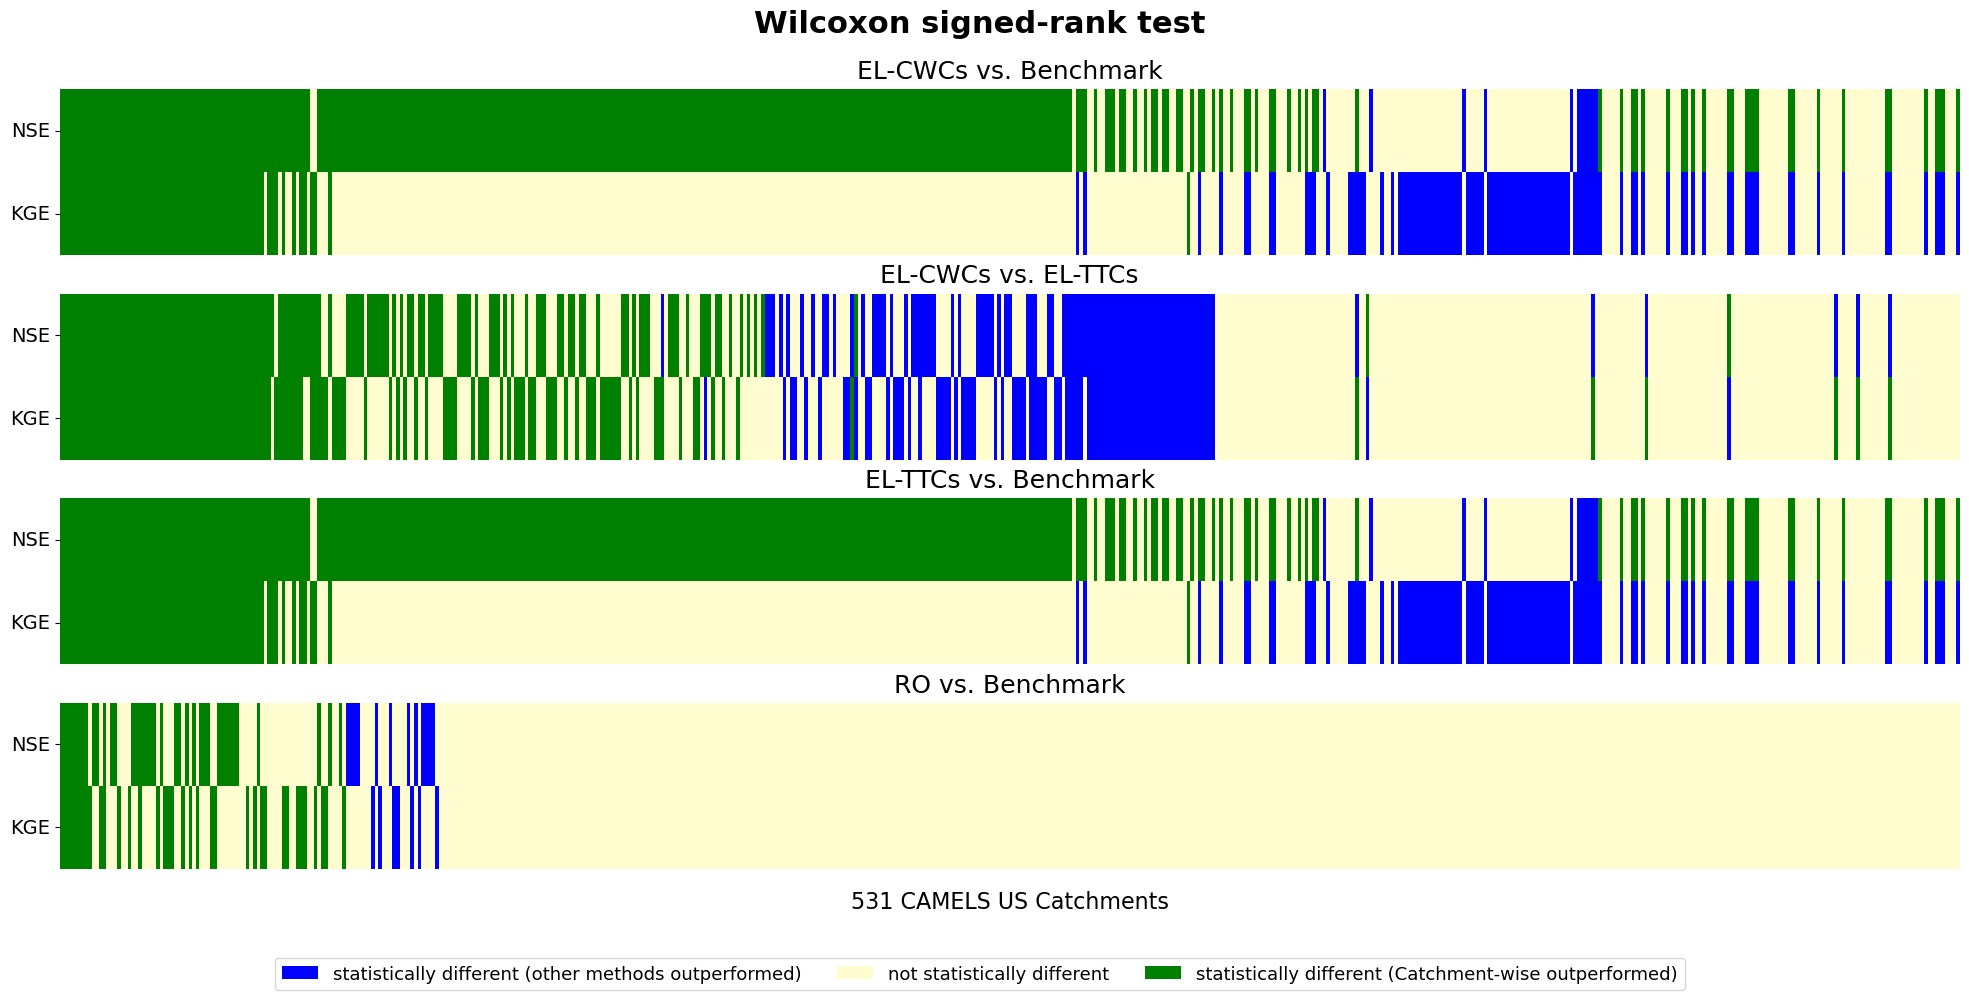

In [223]:

from matplotlib.colors import ListedColormap

save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
fig, axes = plt.subplots(4, 1, figsize=(20, 10))

legend_labels = [
    'statistically different (other methods outperformed)', 
    'not statistically different', 
    'statistically different (Catchment-wise outperformed)'
]
colors = ['blue', '#FFFDD0', 'green']
patches = [plt.Rectangle((0, 0), 1, 1, fc=color) for color in colors]

subplot_cfgs = [
    ('Data_Catchment_wise_vs_Benchmark_Wilcoxon', 'EL-CWCs vs. Benchmark'), 
    ('Data_Catchment_wise_vs_Top_10_Wilcoxon', 'EL-CWCs vs. EL-TTCs'),
    ('Data_Top_10_vs_Benchmark_Wilcoxon', 'EL-TTCs vs. Benchmark'),
    ('Data_RO_vs_Benchmark_Wilcoxon', 'RO vs. Benchmark')
]

for i, (ax, (name, title)) in enumerate(zip(axes, subplot_cfgs)):
    # Read the Excel file (Basin is index, metrics as columns)
    data = pd.read_excel(
        rf'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\{name}.xlsx',
        index_col='Basin'
    )
    # Transpose so rows = metrics, cols = basins
    data_T = data.T
    cmap = ListedColormap(colors)
    # yticklabels will be metrics!
    sns.heatmap(
        data_T, cmap=cmap, cbar=False, ax=ax,
        xticklabels=False, yticklabels=True
    )
    if i == 3:
        ax.set_xlabel('531 CAMELS US Catchments', fontsize=16, labelpad=15)
    else:
        ax.set_xlabel('')
    clean_labels = [col.replace('Wilcoxon_signed_rank_', '').replace('_SF','') for col in data_T.index]
    ax.set_yticklabels(clean_labels, fontsize=14)

    # yticklabels are already metric names
    ax.set_title(title, fontsize=18, pad=8)
    ax.tick_params(axis='both', which='major', labelsize=14)

fig.legend(
    patches, legend_labels, loc='lower center',
    bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=13
)
fig.suptitle('Wilcoxon signed-rank test', fontsize=22, fontweight='bold', y=1.01)
plt.subplots_adjust(wspace=0.05, top=0.93, bottom=0.15, left=0.04, right=0.99, hspace=0.23)
save_path_png = os.path.join(save_dir, 'Wilcoxon_stats.tiff')
plt.savefig(save_path_png, dpi=300, bbox_inches='tight')
plt.show()


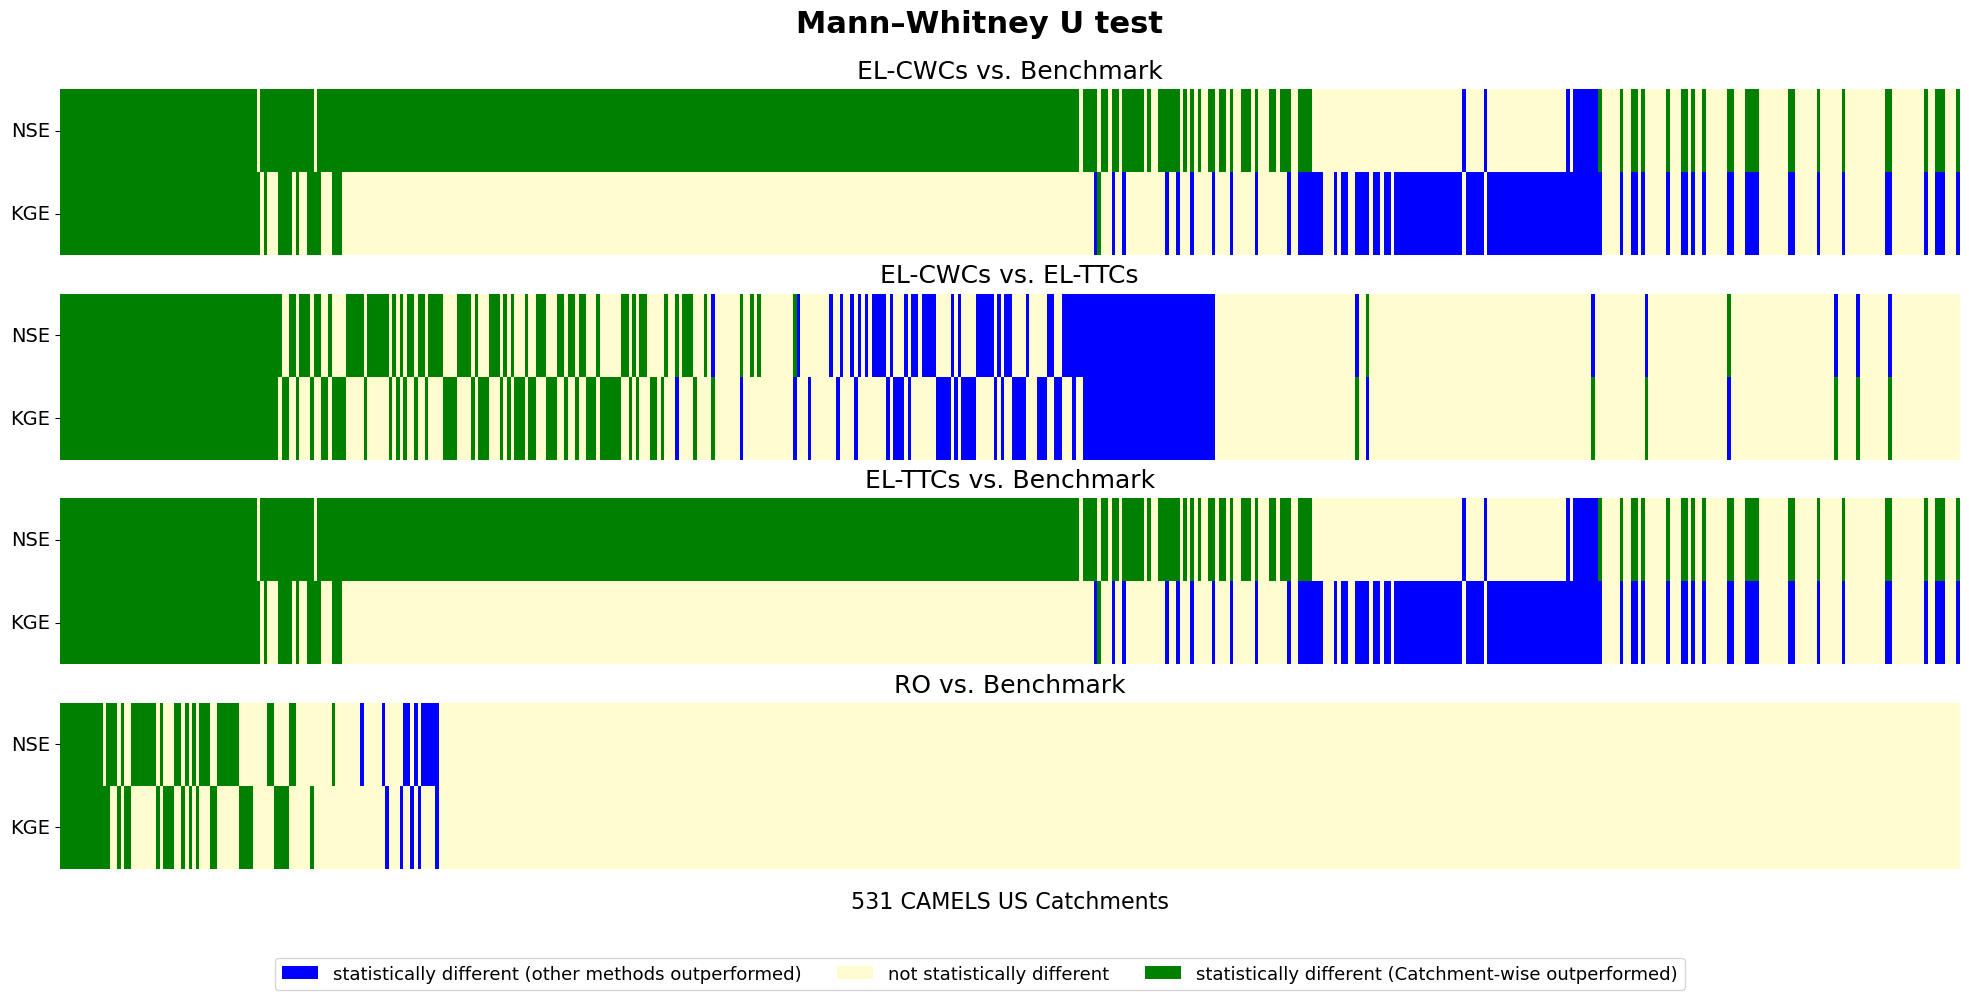

In [224]:
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
fig, axes = plt.subplots(4, 1, figsize=(20, 10))

legend_labels = [
    'statistically different (other methods outperformed)', 
    'not statistically different', 
    'statistically different (Catchment-wise outperformed)'
]
colors = ['blue', '#FFFDD0', 'green']
patches = [plt.Rectangle((0, 0), 1, 1, fc=color) for color in colors]

subplot_cfgs = [
    ('Data_Catchment_wise_vs_Benchmark_Mann', 'EL-CWCs vs. Benchmark'), 
    ('Data_Catchment_wise_vs_Top_10_Mann', 'EL-CWCs vs. EL-TTCs'),
    ('Data_Top_10_vs_Benchmark_Mann', 'EL-TTCs vs. Benchmark'),
    ('Data_RO_vs_Benchmark_Mann', 'RO vs. Benchmark')
]

for i, (ax, (name, title)) in enumerate(zip(axes, subplot_cfgs)):
    # Read the Excel file (Basin is index, metrics as columns)
    data = pd.read_excel(
        rf'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\{name}.xlsx',
        index_col='Basin'
    )
    # Transpose so rows = metrics, cols = basins
    data_T = data.T
    cmap = ListedColormap(colors)
    # yticklabels will be metrics!
    sns.heatmap(
        data_T, cmap=cmap, cbar=False, ax=ax,
        xticklabels=False, yticklabels=True
    )
    if i == 3:
        ax.set_xlabel('531 CAMELS US Catchments', fontsize=16, labelpad=15)
    else:
        ax.set_xlabel('')
    clean_labels = [col.replace('Mann_Whitney_U_', '').replace('_SF','') for col in data_T.index]
    ax.set_yticklabels(clean_labels, fontsize=14)

    # yticklabels are already metric names
    ax.set_title(title, fontsize=18, pad=8)
    ax.tick_params(axis='both', which='major', labelsize=14)

fig.legend(
    patches, legend_labels, loc='lower center',
    bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=13
)
fig.suptitle('Mann–Whitney U test', fontsize=22, fontweight='bold', y=1.01)
plt.subplots_adjust(wspace=0.05, top=0.93, bottom=0.15, left=0.04, right=0.99, hspace=0.23)
save_path_png = os.path.join(save_dir, 'Mann_Whitney_U_stats.tiff')
plt.savefig(save_path_png, dpi=300, bbox_inches='tight')
plt.show()


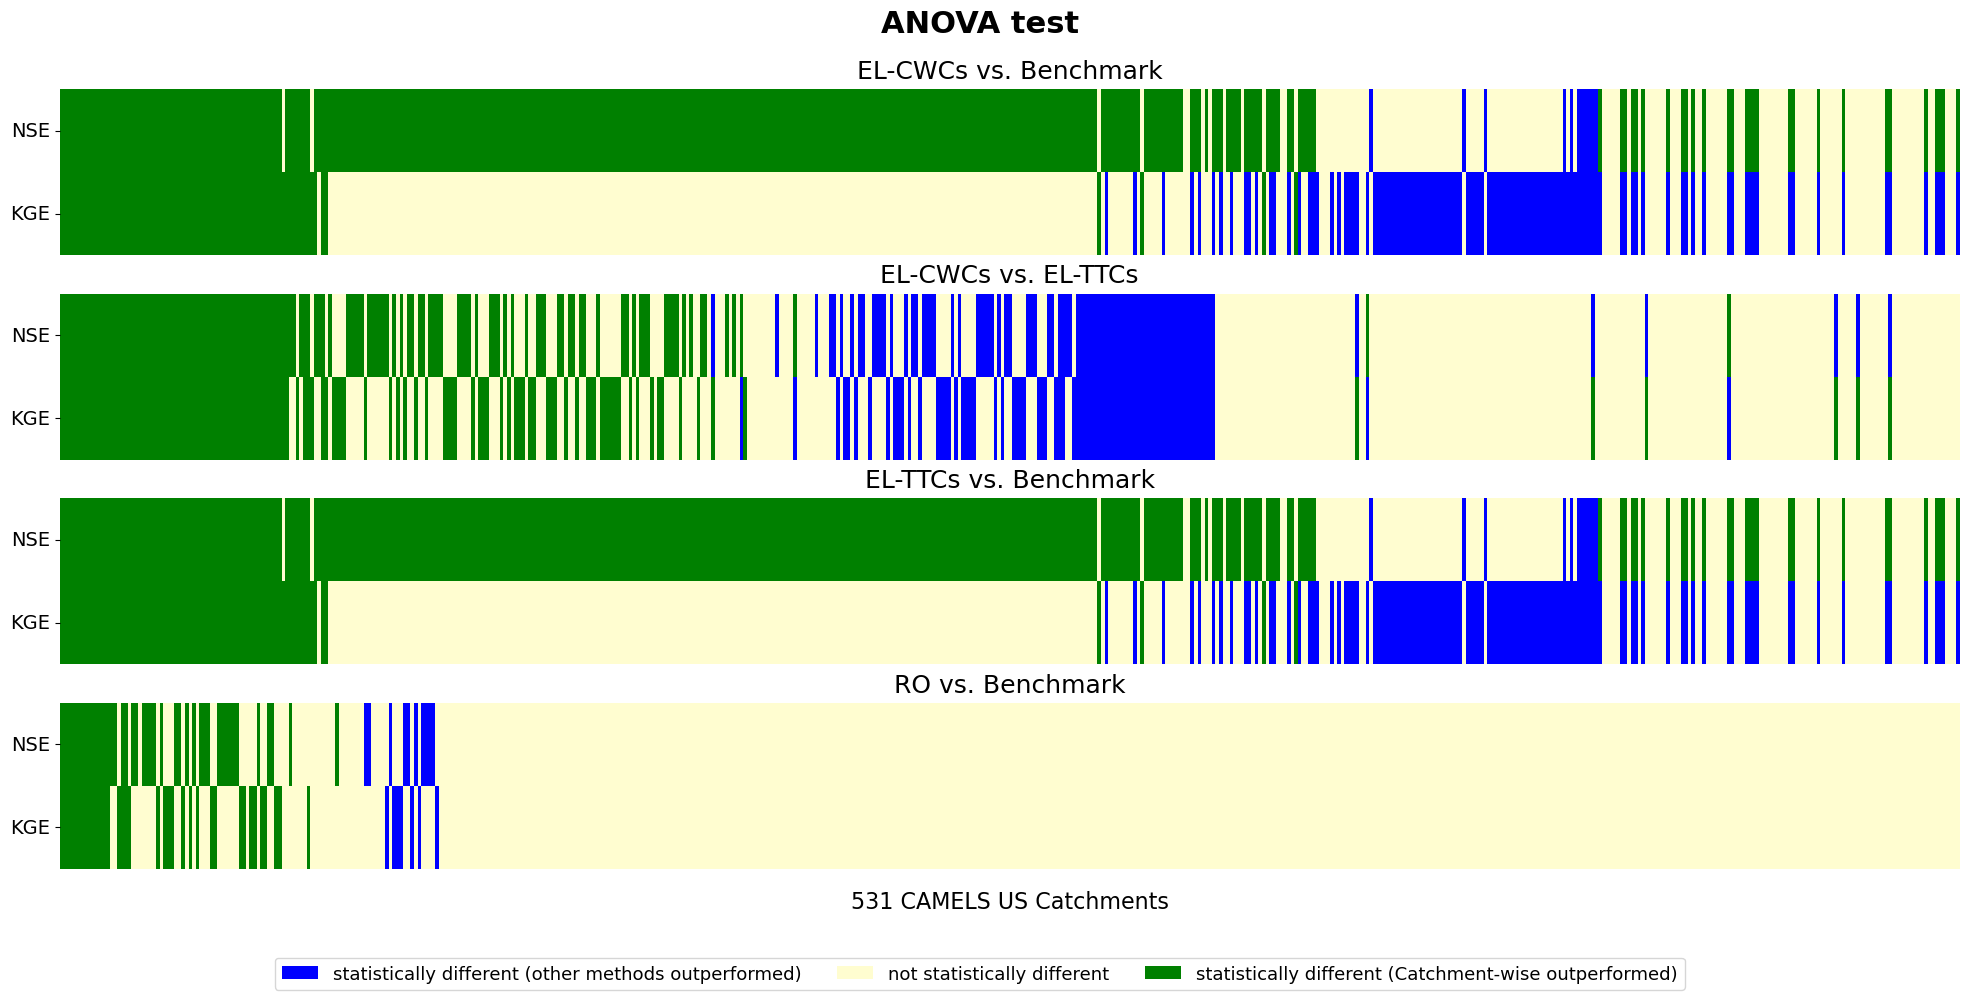

In [225]:
save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
fig, axes = plt.subplots(4, 1, figsize=(20, 10))

legend_labels = [
    'statistically different (other methods outperformed)', 
    'not statistically different', 
    'statistically different (Catchment-wise outperformed)'
]
colors = ['blue', '#FFFDD0', 'green']
patches = [plt.Rectangle((0, 0), 1, 1, fc=color) for color in colors]

subplot_cfgs = [
    ('Data_Catchment_wise_vs_Benchmark_ANOVA', 'EL-CWCs vs. Benchmark'), 
    ('Data_Catchment_wise_vs_Top_10_ANOVA', 'EL-CWCs vs. EL-TTCs'),
    ('Data_Top_10_vs_Benchmark_ANOVA', 'EL-TTCs vs. Benchmark'),
    ('Data_RO_vs_Benchmark_ANOVA', 'RO vs. Benchmark')
]

for i, (ax, (name, title)) in enumerate(zip(axes, subplot_cfgs)):
    # Read the Excel file (Basin is index, metrics as columns)
    data = pd.read_excel(
        rf'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\{name}.xlsx',
        index_col='Basin'
    )
    # Transpose so rows = metrics, cols = basins
    data_T = data.T
    cmap = ListedColormap(colors)
    # yticklabels will be metrics!
    sns.heatmap(
        data_T, cmap=cmap, cbar=False, ax=ax,
        xticklabels=False, yticklabels=True
    )
    if i == 3:
        ax.set_xlabel('531 CAMELS US Catchments', fontsize=16, labelpad=15)
    else:
        ax.set_xlabel('')
    clean_labels = [col.replace('ANOVA_', '').replace('_SF','') for col in data_T.index]
    ax.set_yticklabels(clean_labels, fontsize=14)

    # yticklabels are already metric names
    ax.set_title(title, fontsize=18, pad=8)
    ax.tick_params(axis='both', which='major', labelsize=14)

fig.legend(
    patches, legend_labels, loc='lower center',
    bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=13
)
fig.suptitle('ANOVA test', fontsize=22, fontweight='bold', y=1.01)
plt.subplots_adjust(wspace=0.05, top=0.93, bottom=0.15, left=0.04, right=0.99, hspace=0.23)
save_path_png = os.path.join(save_dir, 'ANOVA_stats.tiff')
plt.savefig(save_path_png, dpi=300, bbox_inches='tight')
plt.show()


# Comparison of the two networks performances

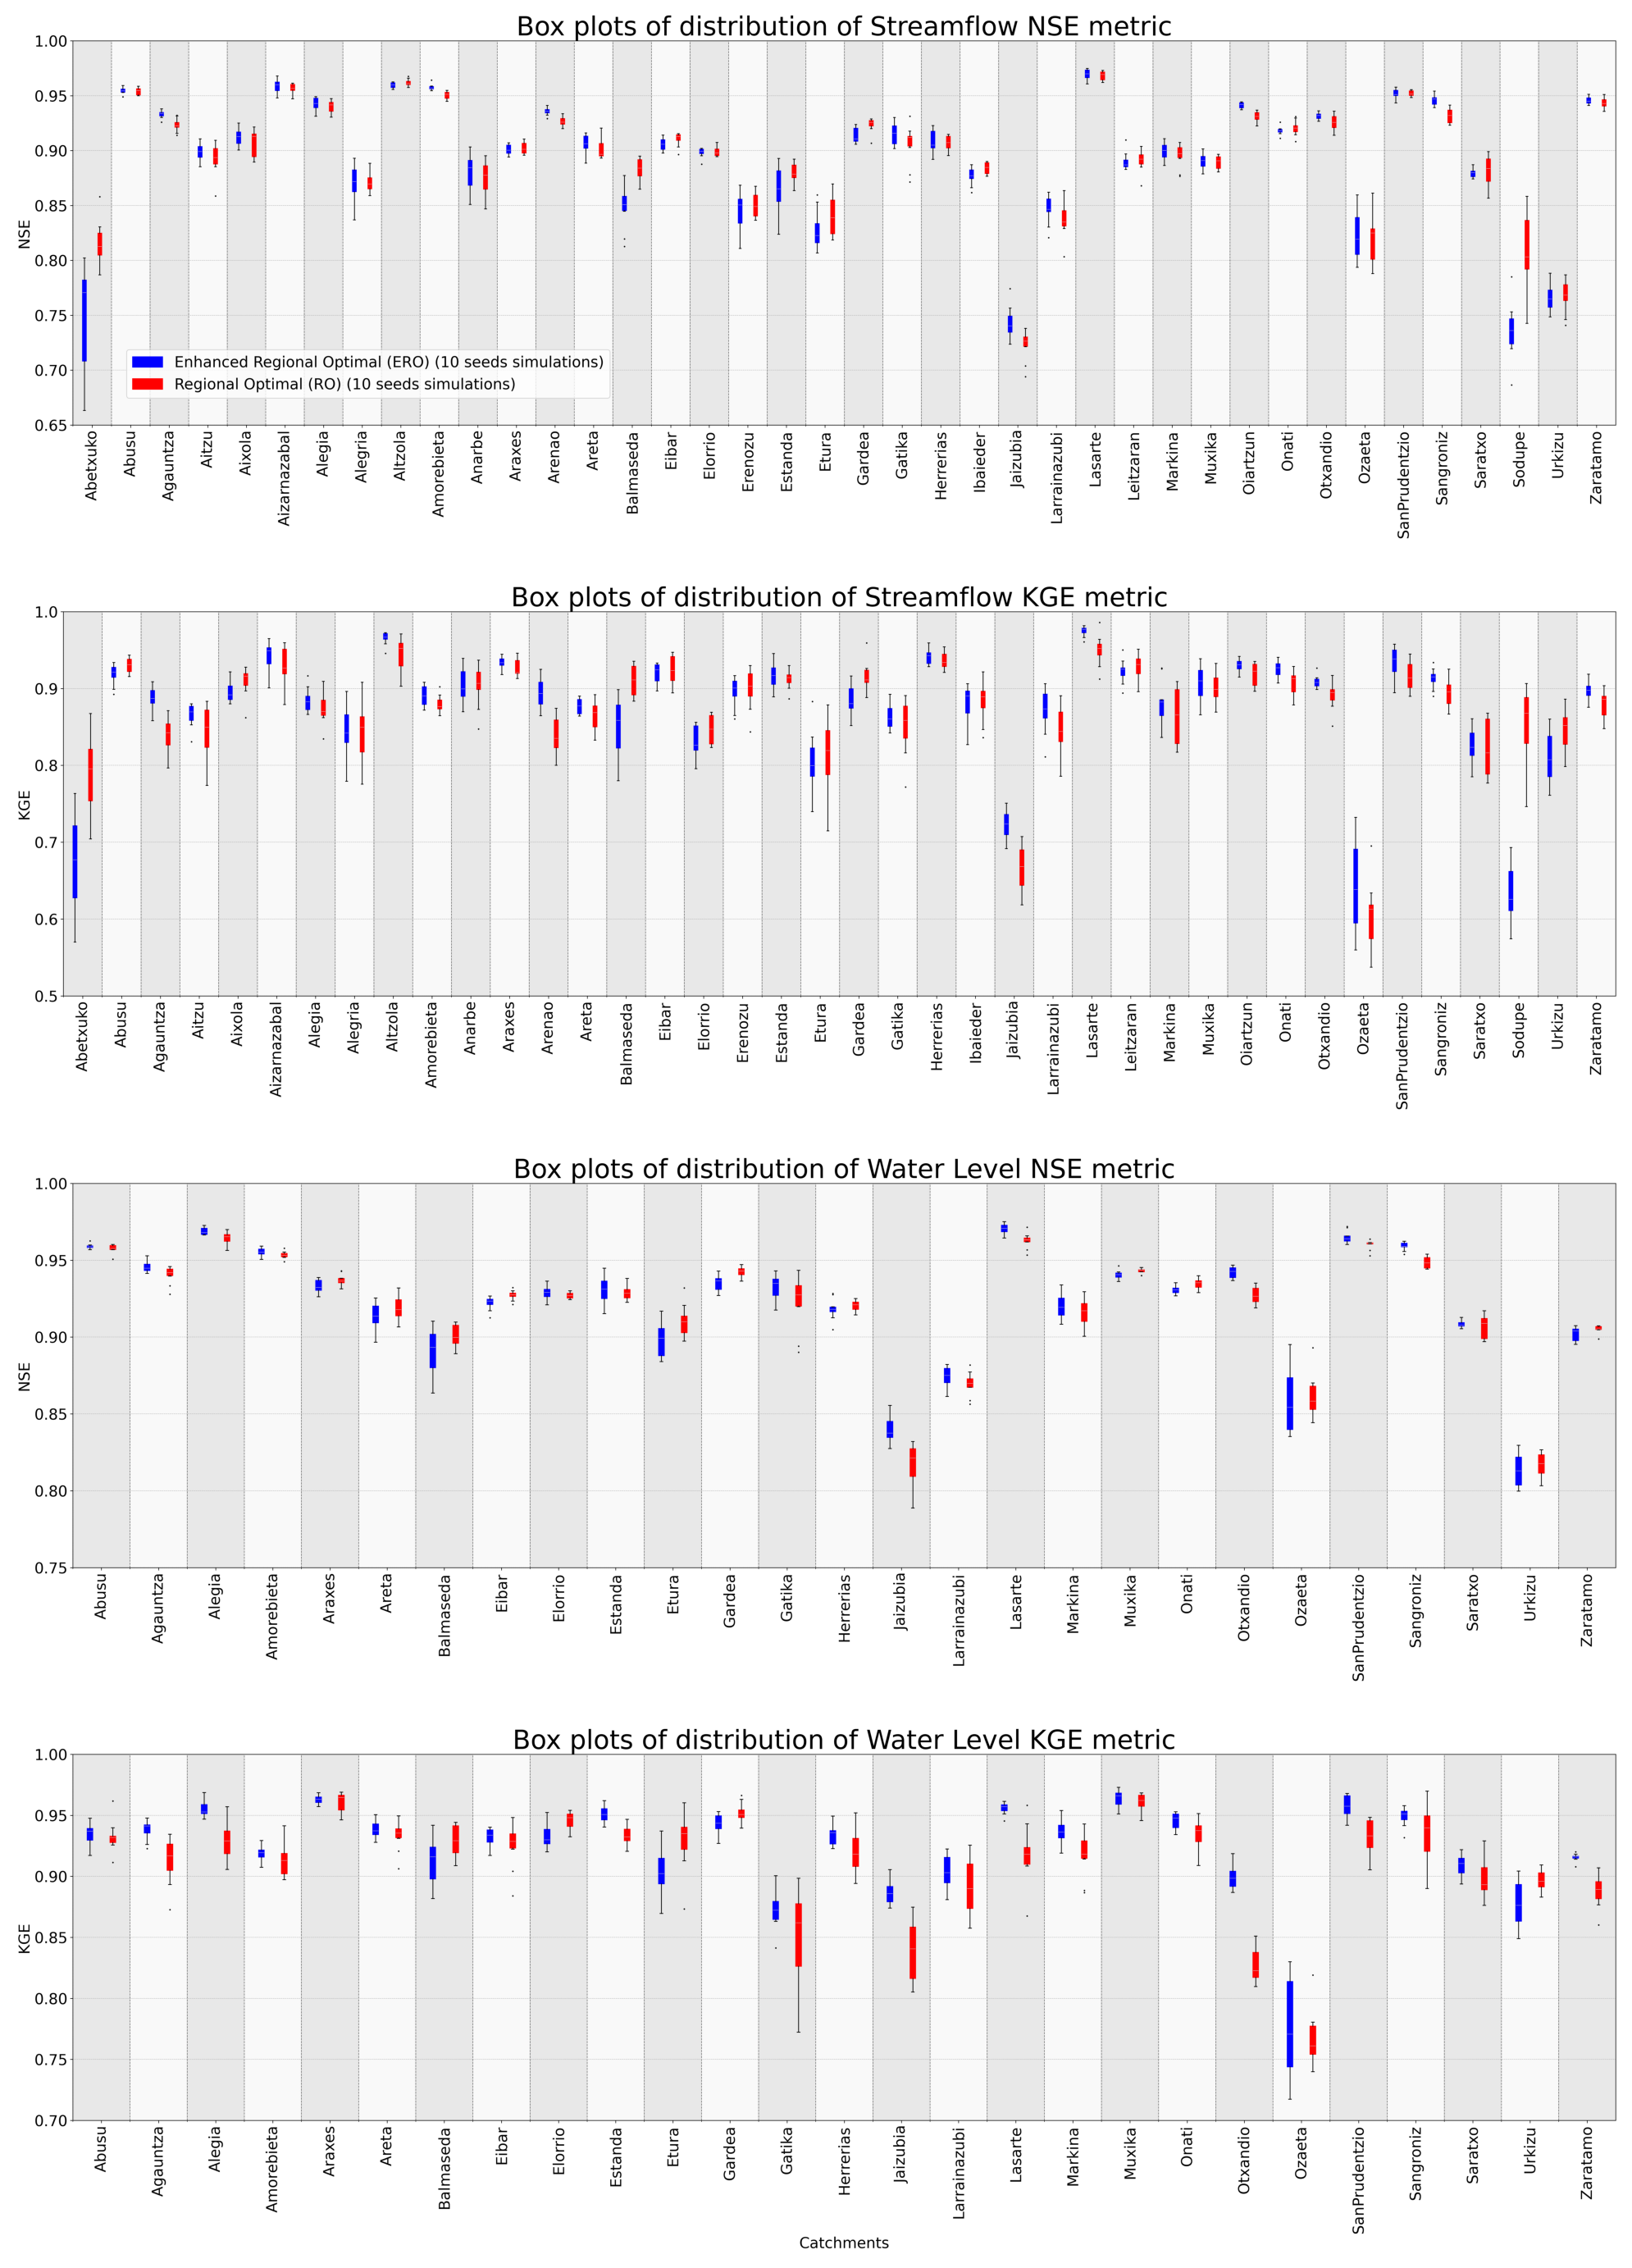

In [6]:
## This code combines all 4 figures for the paper

# Load your figures
fig_paths = [
    r"D:\Thesis2024\Papers.OnGoing\Papers.UnderWork\Paper.01.01.RandomSearch.SHpT.URA\Supplementary_materials\Figures\NSE_q_mean_box_plot_40Basins.png",
    r"D:\Thesis2024\Papers.OnGoing\Papers.UnderWork\Paper.01.01.RandomSearch.SHpT.URA\Supplementary_materials\Figures\KGE_q_mean_box_plot_40Basins.png",
    r"D:\Thesis2024\Papers.OnGoing\Papers.UnderWork\Paper.01.01.RandomSearch.SHpT.URA\Supplementary_materials\Figures\NSE_l_mean_box_plot_40Basins.png",
    r"D:\Thesis2024\Papers.OnGoing\Papers.UnderWork\Paper.01.01.RandomSearch.SHpT.URA\Supplementary_materials\Figures\KGE_l_mean_box_plot_40Basins.png"
]

# Create a 4x1 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(20, 28))

# Loop through each subplot and add the corresponding figure
for i, ax in enumerate(axes):
    img = imread(fig_paths[i])
    ax.imshow(img)
    ax.axis('off')  # Hide axis labels

# Adjust layout to prevent overlap
plt.tight_layout()

# Define the directory to save the plots
save_dir = r"D:\Thesis2024\Papers.OnGoing\Papers.UnderWork\Paper.01.01.RandomSearch.SHpT.URA\Supplementary_materials\Figures"

# Save the plot to a file
save_path = os.path.join(save_dir, f'combined_figures.pdf')
os.makedirs(os.path.dirname(save_path), exist_ok=True)  # Create folder if it doesn't exist
plt.savefig(save_path, format='pdf', dpi=600)
plt.show()  # Display the combined figure


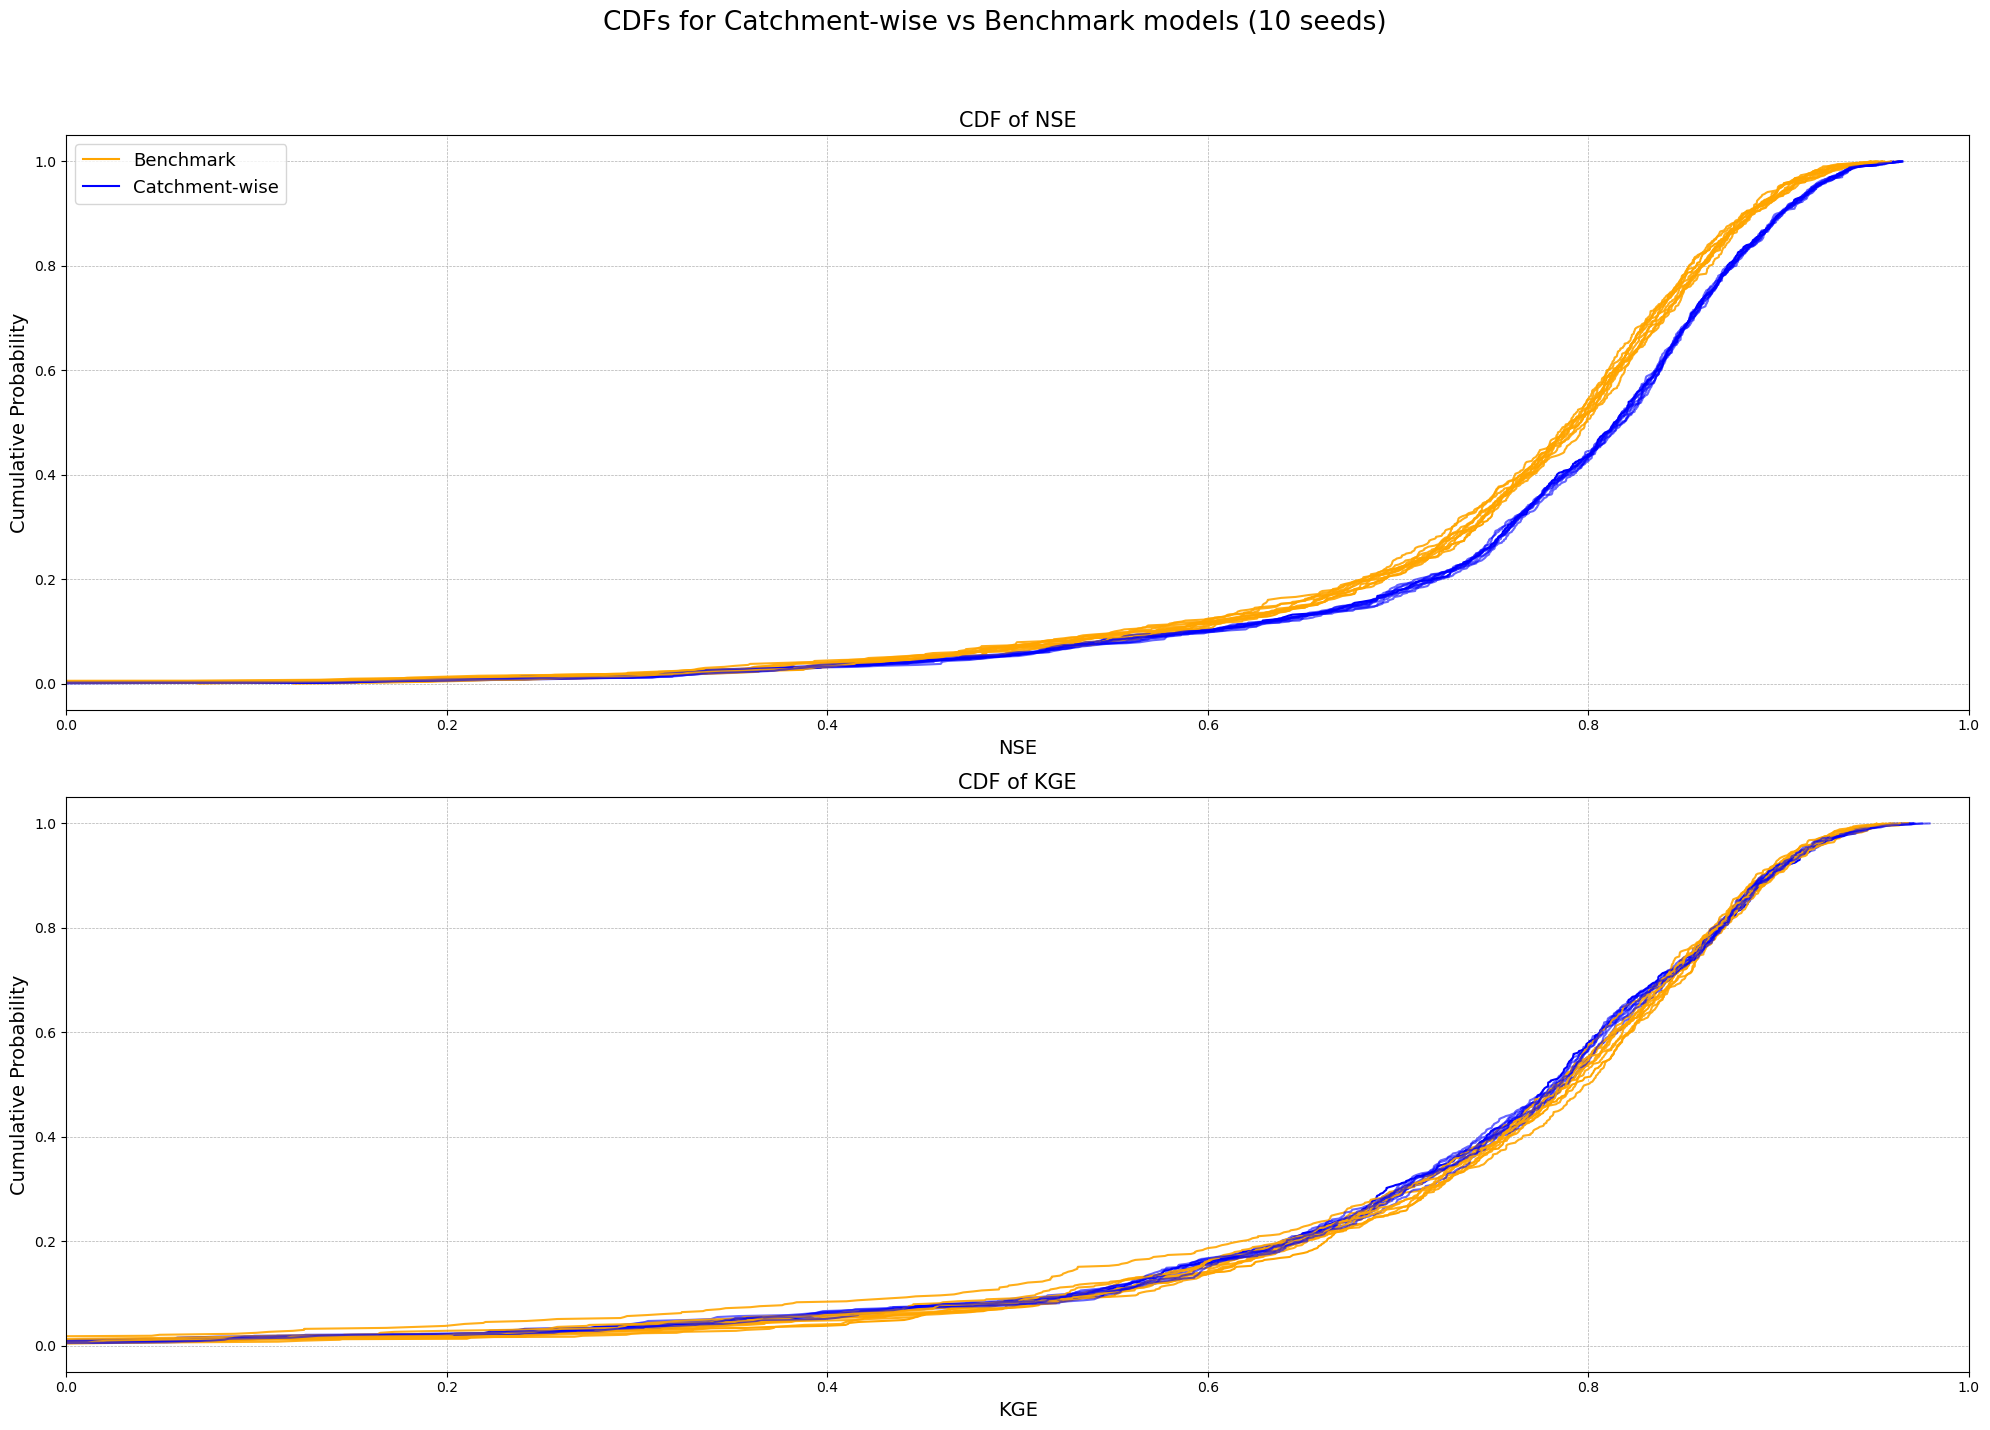

In [232]:

save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
os.makedirs(save_dir, exist_ok=True)

# Read basin list if you want (optional)
basin_list_path = r'F:\Experiments\CAMELS_US\TrainsTests\Never.Paper.data.info\531_basin_list.txt'
with open(basin_list_path, 'r') as f:
    CAMELSUS_basins = [line.strip() for line in f if line.strip()]

metrics = ['NSE', 'KGE']  # Add more as needed

ncols = 1
nrows = int(np.ceil(len(metrics) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(20, 15))
axs = axs.flatten()

def collect_metric_by_seed(df, metric, basins=None, n_seeds=10):
    """Return a list of arrays, each array is all basin values for one seed for a given metric."""
    all_seeds = sorted(df['seed'].unique())
    seeds = all_seeds[:n_seeds]  # use first n_seeds
    arrays = []
    for seed in seeds:
        if basins is not None:
            vals = df[(df['seed'] == seed) & (df['basin'].isin(basins))][metric].values
        else:
            vals = df[df['seed'] == seed][metric].values
        arrays.append(vals)
    return arrays

for idx, metric in enumerate(metrics):
    data_cw = collect_metric_by_seed(df_Catchment_Wise, metric, CAMELSUS_basins)
    data_bm = collect_metric_by_seed(df_Benchmark, metric, CAMELSUS_basins)
    # CDF plot
    for i in range(len(data_cw)):
        sorted_cw = np.sort(data_cw[i])
        yvals_cw = np.linspace(0, 1, len(sorted_cw))
        sorted_bm = np.sort(data_bm[i])
        yvals_bm = np.linspace(0, 1, len(sorted_bm))
        if i == 0:
            axs[idx].plot(sorted_bm, yvals_bm, color='orange', label='Benchmark')
            axs[idx].plot(sorted_cw, yvals_cw, color='blue', label='Catchment-wise')
        else:
            axs[idx].plot(sorted_bm, yvals_bm, color='orange', alpha=0.9)
            axs[idx].plot(sorted_cw, yvals_cw, color='blue', alpha=0.6)
    axs[idx].set_xlabel(metric, fontsize=14)
    axs[idx].set_ylabel('Cumulative Probability', fontsize=14)
    axs[idx].set_title(f'CDF of {metric}', fontsize=15)
    axs[idx].grid(True, linestyle='--', linewidth=0.5)
    axs[idx].set_xlim(0, 1)
    if idx == 0:
        axs[idx].legend(fontsize=13)

for j in range(idx+1, len(axs)):
    fig.delaxes(axs[j])

fig.suptitle('CDFs for Catchment-wise vs Benchmark models (10 seeds)', fontsize=19)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_path = os.path.join(save_dir, 'cdf_catchmentwise_vs_benchmark.pdf')
plt.savefig(save_path, format='pdf', dpi=600)
plt.show()


# Statistical tests

<Figure size 1000x600 with 0 Axes>

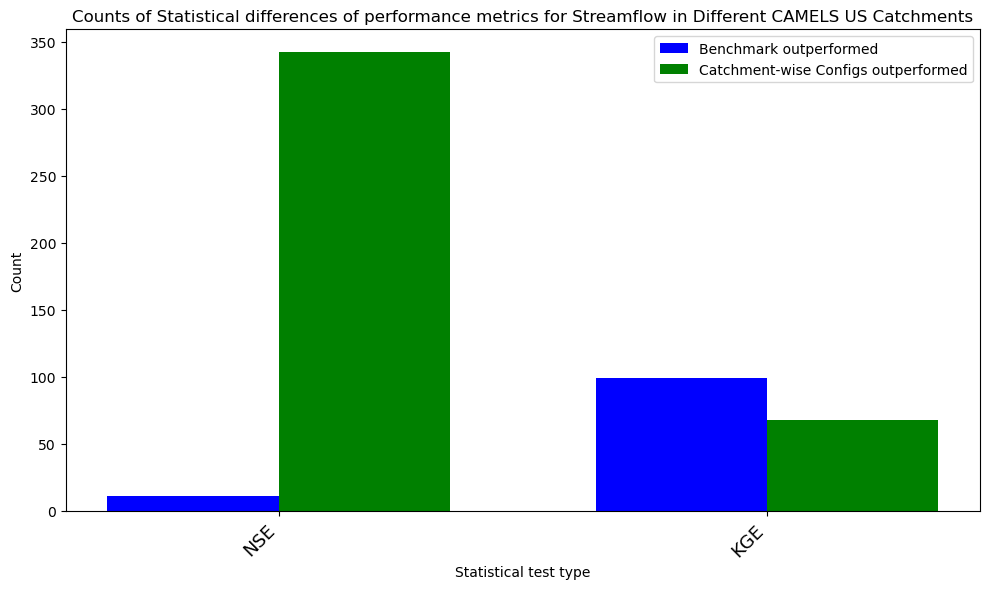

In [242]:

# Calculate the counts of blue and green colors for each test
# Load your file (example)
file = r'F:\Experiments\CAMELS_US\TrainsTests\PickleFiles\Stats\Data_Catchment_wise_vs_Benchmark_Wilcoxon.xlsx'
data = pd.read_excel(file, index_col='Basin')

# Count occurrences for each value
blue_counts = (data == -1).sum()
cream_counts = (data == 0).sum()
green_counts = (data == 1).sum()

# Plot the bar plot
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(blue_counts))
clean_labels = [col.replace('Wilcoxon_signed_rank_', '').replace('_SF','') for col in data.columns]

plt.figure(figsize=(10, 6))
plt.bar(index, blue_counts, bar_width, label='Benchmark outperformed', color='blue')
plt.bar(index + bar_width, green_counts, bar_width, label='Catchment-wise Configs outperformed', color='green')

plt.xlabel('Statistical test type')
plt.ylabel('Count')
plt.title('Counts of Statistical differences of performance metrics for Streamflow in Different CAMELS US Catchments')
plt.xticks(index + bar_width / 2, clean_labels, rotation=45, ha='right', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(save_dir, f'stats_fig_counts_URA.pdf'),
    format='pdf',
    dpi=600, 
    bbox_inches='tight'  
)
plt.show()

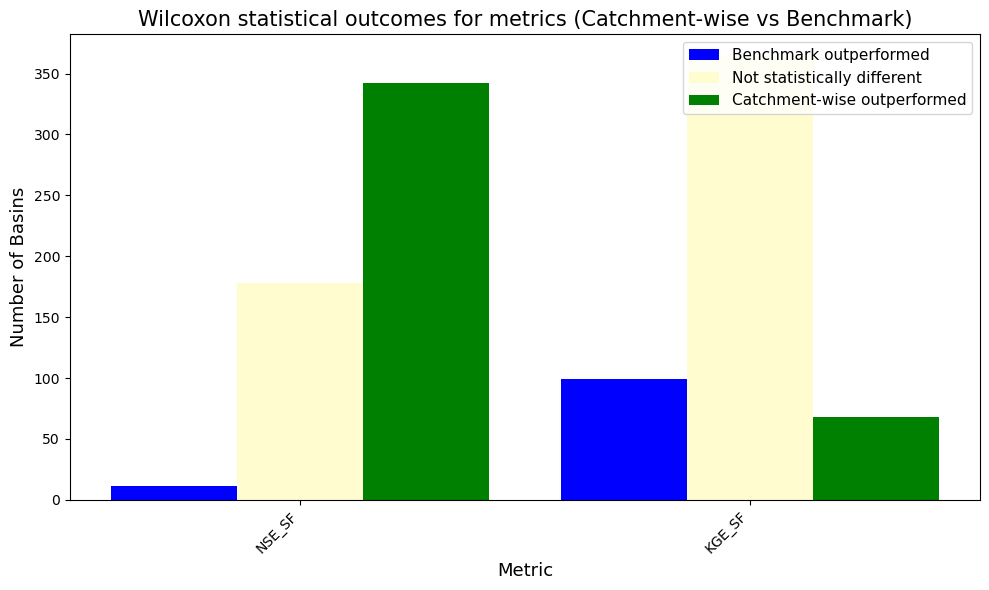

In [243]:
bar_width = 0.28
index = np.arange(len(blue_counts))

plt.figure(figsize=(10, 6))
plt.bar(index - bar_width, blue_counts, bar_width, label='Benchmark outperformed', color='blue')
plt.bar(index, cream_counts, bar_width, label='Not statistically different', color='#FFFDD0')
plt.bar(index + bar_width, green_counts, bar_width, label='Catchment-wise outperformed', color='green')

plt.xlabel('Metric', fontsize=13)
plt.ylabel('Number of Basins', fontsize=13)
plt.title('Wilcoxon statistical outcomes for metrics (Catchment-wise vs Benchmark)', fontsize=15)
plt.xticks(index, data.columns.str.replace('Wilcoxon_signed_rank_', ''), rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()

save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
plt.savefig(os.path.join(save_dir, 'Wilcoxon_stats_bar_counts.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()


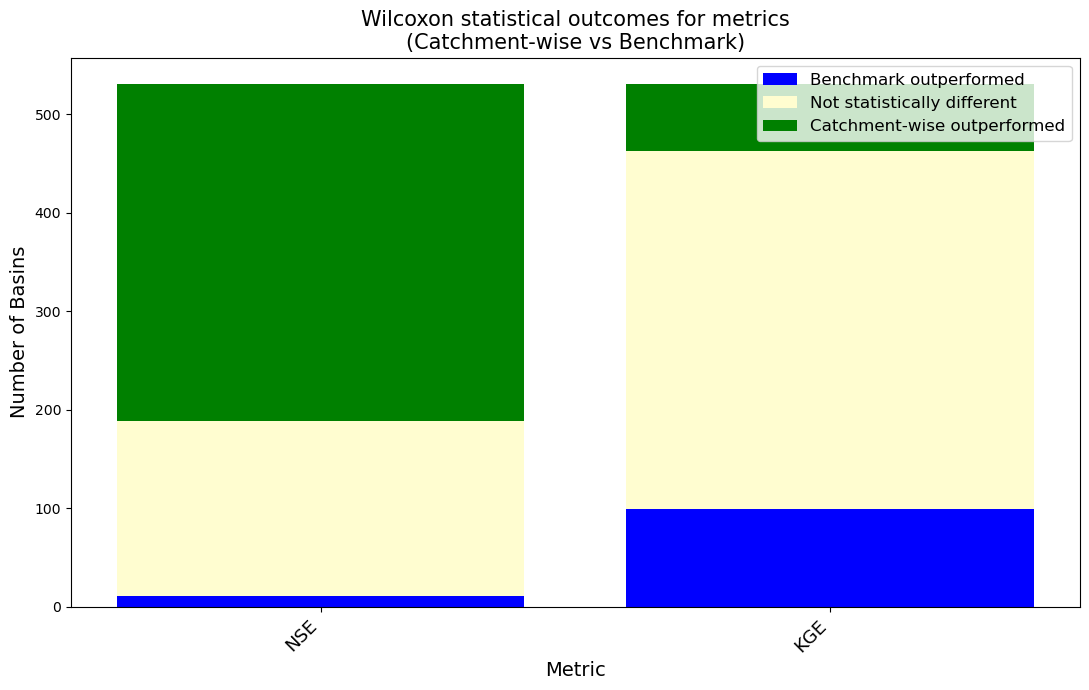

In [244]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Suppose `data` is your DataFrame with outcome codes:
# -1: Benchmark outperformed (blue)
#  0: Not statistically different (cream)
#  1: Catchment-wise outperformed (green)
# Each column = one metric

# Example: load your data
# data = pd.read_excel('your_wilcoxon_outcomes.xlsx', index_col=0)

# Count occurrences for each outcome per metric
blue_counts = (data == -1).sum(axis=0).values   # Benchmark outperformed
cream_counts = (data == 0).sum(axis=0).values   # Not statistically different
green_counts = (data == 1).sum(axis=0).values   # Catchment-wise outperformed

labels = [col.replace('Wilcoxon_signed_rank_', '').replace('_SF','') for col in data.columns]

index = np.arange(len(labels))

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))
ax.bar(index, blue_counts, label='Benchmark outperformed', color='blue')
ax.bar(index, cream_counts, bottom=blue_counts, label='Not statistically different', color='#FFFDD0')
ax.bar(index, green_counts, bottom=blue_counts+cream_counts, label='Catchment-wise outperformed', color='green')

ax.set_xlabel('Metric', fontsize=14)
ax.set_ylabel('Number of Basins', fontsize=14)
ax.set_title('Wilcoxon statistical outcomes for metrics\n(Catchment-wise vs Benchmark)', fontsize=15)
ax.set_xticks(index)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()

save_dir = r"F:\Experiments\CAMELS_US\TrainsTests\Results\Plots"
plt.savefig(os.path.join(save_dir, 'Wilcoxon_stats_bar_counts.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
